# FinTrust Digital Bank — Week 4: Final Predictive Risk Model
### Data Science track · Test → Validate → Refine → Finalize → Present
**Project:** FinTrust Financial Intelligence & Digital Banking Support Solution

### Predictive problem (unchanged since Week 1)
*Given the attributes of a transaction that are known when it is made, can we rank transactions by how likely they are to be marked `Risk_Review_Flag = Yes`, so that a limited manual-review budget is spent where it is most useful?*

### How this notebook maps to the Week 4 Data Science assignment
| Assignment part | Section | Assignment part | Section |
|---|---|---|---|
| Review previous work (3.A) | 3. Review of Weeks 1–3 | D. Final model interpretation | 7. Part D |
| A. Final feature review | 4. Part A | E. Data Analytics comparison | 8. Part E |
| B. Final model evaluation | 5. Part B | F. Final model documentation | 9. Part F |
| C. Error analysis | 6. Part C | Final testing chain, integration, limitations | 10–13 |

## 1. Setup and data loading

In [1]:
import os, json, platform, warnings, time, joblib, sklearn, scipy
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display, Markdown
from scipy.stats import chi2_contingency

from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, GroupKFold, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, brier_score_loss)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
NAVY, ORANGE, GREY, TEAL, RED = "#1F4E79", "#D98324", "#8C8C8C", "#2A9D8F", "#C0392B"
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11, "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False})
SEED = 42; np.random.seed(SEED)

print(f"Python {platform.python_version()} | pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__} | scipy {scipy.__version__}")

Python 3.14.6 | pandas 3.0.3 | numpy 2.4.6 | scikit-learn 1.9.0 | scipy 1.17.1


In [2]:
# Repository layout: notebooks/ (this file) · data/raw · data/processed · models · reports/figures
ROOT = Path.cwd().parent        # FinTrust_Digital_Bank_Project (contains data/, week-1 ... week-4)
OUT  = Path.cwd()               # week-4: models and reports are saved here
PROC   = ROOT/"data"/"processed"
MODELS = OUT/"models"
FIG    = OUT/"reports"/"figures"
for p in (PROC, MODELS, FIG): p.mkdir(parents=True, exist_ok=True)

def find(pattern):
    hits = [p for p in (ROOT/"data").rglob("*.csv") if pattern.lower() in p.name.lower()]
    assert hits, f"No CSV containing '{pattern}' found under {ROOT/'data'}"
    return hits[0]
CUST_PATH, TXN_PATH, V2_PATH = find("Customer_Data"), find("Transaction_Data"), find("Modelling_Dataset_v2")
print("Using:", CUST_PATH, TXN_PATH, V2_PATH, sep="\n  ")
# Only the charts that are useful for slides and the repo are written to reports/figures; every other chart is shown in the notebook only.
KEEP_FIGS = {"A2_amount_step_and_patterns.png", "B2_nested_evaluation.png", "C1_confusion_matrices.png", "D1_odds_ratios.png", "E5_da_vs_ds.png"}
def savefig(name):
    plt.tight_layout()
    if name in KEEP_FIGS: plt.savefig(FIG/name, dpi=150, bbox_inches="tight")

print("Project root:", ROOT)

Using:
  d:\Analyst_lab\FinTrust_Digital_Bank_Project\data\raw\FinTrust_Customer_Data - FinTrust_Customer_Data.csv
  d:\Analyst_lab\FinTrust_Digital_Bank_Project\data\raw\FinTrust_Transaction_Data - FinTrust_Transaction_Data.csv
  d:\Analyst_lab\FinTrust_Digital_Bank_Project\data\processed\FinTrust_Modelling_Dataset_v2.csv
Project root: d:\Analyst_lab\FinTrust_Digital_Bank_Project


In [3]:
cust = pd.read_csv(r"D:\Analyst_lab\FinTrust_Digital_Bank_Project\data\raw\FinTrust_Customer_Data - FinTrust_Customer_Data.csv")
txn  = pd.read_csv(r"D:\Analyst_lab\FinTrust_Digital_Bank_Project\data\raw\FinTrust_Transaction_Data - FinTrust_Transaction_Data.csv")
v2   = pd.read_csv(r"D:\Analyst_lab\FinTrust_Digital_Bank_Project\data\processed\FinTrust_Modelling_Dataset_v2.csv")          # Week 3 modelling dataset = the STARTING POINT of Week 4
print("Customer data   :", cust.shape, "| Transaction data:", txn.shape, "| Week 3 dataset (v2):", v2.shape)

dt_parsed = pd.to_datetime(txn.Transaction_DateTime, errors="coerce")
quality = pd.Series({
 "Duplicate Customer_ID rows": int(cust.Customer_ID.duplicated().sum()),
 "Duplicate Transaction_ID rows": int(txn.Transaction_ID.duplicated().sum()),
 "Missing values - customer data (all columns)": int(cust.isna().sum().sum()),
 "Missing Device_Type (transactions)": int(txn.Device_Type.isna().sum()),
 "Missing Location (transactions)": int(txn.Location.isna().sum()),
 "Missing values in any other transaction column": int(txn.drop(columns=["Device_Type","Location"]).isna().sum().sum()),
 "Non-positive Amount_NGN": int((txn.Amount_NGN <= 0).sum()),
 "Unparseable Transaction_DateTime": int(dt_parsed.isna().sum()),
 "Transactions whose Customer_ID is not in customer data": int((~txn.Customer_ID.isin(cust.Customer_ID)).sum()),
 "Risk_Review_Flag values other than Yes/No": int((~txn.Risk_Review_Flag.isin(["Yes","No"])).sum()),
}, name="count").to_frame()
display(quality)
print(f"Date range: {dt_parsed.min()}  ->  {dt_parsed.max()}")
print("Target distribution:", txn.Risk_Review_Flag.value_counts(normalize=True).round(4).to_dict())

Customer data   : (1500, 12) | Transaction data: (12000, 11) | Week 3 dataset (v2): (12000, 17)


,count
Duplicate Customer_ID rows,0
Duplicate Transaction_ID rows,0
Missing values - customer data (all columns),0
Missing Device_Type (transactions),96
Missing Location (transactions),96
Missing values in any other transaction column,0
Non-positive Amount_NGN,0
Unparseable Transaction_DateTime,0
Transactions whose Customer_ID is not in customer data,0
Risk_Review_Flag values other than Yes/No,0


Date range: 2026-01-01 00:00:00  ->  2026-03-31 23:59:00
Target distribution: {'No': 0.804, 'Yes': 0.196}


In [5]:
def prepare_base(txn, cust):
    '''Join, clean and add the descriptive columns every later step needs (same preparation as Weeks 2-3).'''
    d = txn.copy()
    d["Transaction_DateTime"] = pd.to_datetime(d["Transaction_DateTime"])
    d["Device_Type"] = d["Device_Type"].fillna("Unknown"); d["Location"] = d["Location"].fillna("Unknown")
    d["y"] = (d["Risk_Review_Flag"] == "Yes").astype(int)
    d = d.merge(cust.drop(columns=["Customer_Name"]), on="Customer_ID", how="left", validate="many_to_one")   # Customer_Name: Modelling_Use = No
    d = d.sort_values(["Transaction_DateTime", "Transaction_ID"]).reset_index(drop=True)                    # time order
    d["hour"] = d.Transaction_DateTime.dt.hour
    d["day_of_week"] = d.Transaction_DateTime.dt.dayofweek
    d["is_weekend"] = (d.day_of_week >= 5).astype(int)
    d["is_night"] = d.hour.between(0, 5).astype(int)                       # 00:00-05:59
    d["is_international"] = (d.International_Transaction == "Yes").astype(int)
    d["log_amount"] = np.log1p(d.Amount_NGN)
    d["risky_type"] = d.Transaction_Type.isin(["Transfer", "Cash Withdrawal"]).astype(int)
    # Week 2 look-ahead counts (kept ONLY so the Week 2 recipe can be re-fitted for comparison)
    d["Customer_Transaction_Count"] = d.groupby("Customer_ID").Customer_ID.transform("count")
    d["Transaction_Frequency"] = d.Customer_Transaction_Count / d.Tenure_Months.replace(0, 1)
    # past-only customer history (tested in Part A)
    g = d.groupby("Customer_ID", sort=False)
    d["prior_txn_count"] = g.cumcount()
    prior_mean = g["Amount_NGN"].transform(lambda s: s.shift().expanding().mean())
    d["amount_vs_cust_avg"] = np.log(d.Amount_NGN / prior_mean).replace([np.inf, -np.inf], np.nan).fillna(0).clip(-3, 3)
    return d

data = prepare_base(txn, cust)
data = data.merge(v2[["Transaction_ID", "log_hours_since_prev"]], on="Transaction_ID", how="left", validate="one_to_one")   # Week 3 recency feature, taken from v2
N = len(data); I_TR, I_VA = int(0.6 * N), int(0.8 * N)
data["split"] = np.select([data.index < I_TR, data.index < I_VA], ["train", "validation"], "test")   # same chronological 60/20/20 as Week 3
train, valid, test = (data[data.split == s].copy() for s in ["train", "validation", "test"])
dev = data[data.split != "test"]
summary = data.groupby("split").agg(rows=("y","size"), start=("Transaction_DateTime","min"), end=("Transaction_DateTime","max"), flag_rate=("y","mean")).loc[["train","validation","test"]]
summary["flag_rate"] = summary.flag_rate.round(4); display(summary)

,rows,start,end,flag_rate
split,,,,
train,7200,2026-01-01 00:00:00,2026-02-23 23:55:00,0.1915
validation,2400,2026-02-24 00:06:00,2026-03-13 23:57:00,0.2129
test,2400,2026-03-14 00:08:00,2026-03-31 23:59:00,0.1925


In [6]:
# ---- Continuity with Week 3: the Week 3 file is the starting point, and the preparation above must reproduce it exactly
assert (v2.Transaction_ID.values == data.Transaction_ID.values).all(), "Transaction order differs from the Week 3 file"
same_text = lambda a, b: bool((v2[a].astype(str).values == data[b].astype(str).values).all())
cont = {c: same_text(c, c) for c in ["Customer_ID", "Transaction_DateTime", "split", "Transaction_Type", "is_international", "is_night", "hour", "Channel", "Device_Type", "prior_txn_count"]}
cont["Risk_Review_Flag_binary (= y)"] = same_text("Risk_Review_Flag_binary", "y")
for c in ["Amount_NGN", "log_amount", "amount_vs_cust_avg"]: cont[c] = bool(np.allclose(v2[c].values, data[c].values))
cont["high_amount (Week 3 cut-off = train 90th percentile)"] = bool((v2.high_amount.values == (data.Amount_NGN >= float(train.Amount_NGN.quantile(0.90))).astype(int).values).all())
cont_tbl = pd.DataFrame({"Identical to the Week 3 file (all 12,000 rows)": cont}); display(cont_tbl)
assert cont_tbl.iloc[:, 0].all(), "The preparation does not reproduce the Week 3 file"
print("The Week 3 dataset (v2) is reproduced exactly, so Week 4 genuinely continues from it. log_hours_since_prev is taken from v2 as supplied.")

,"Identical to the Week 3 file (all 12,000 rows)"
Customer_ID,True
Transaction_DateTime,True
split,True
Transaction_Type,True
is_international,True
is_night,True
hour,True
Channel,True
Device_Type,True
prior_txn_count,True


The Week 3 dataset (v2) is reproduced exactly, so Week 4 genuinely continues from it. log_hours_since_prev is taken from v2 as supplied.


## 2. Evaluation protocol and helper functions
### Protocol for Week 4 (fixed before any Week 4 result was inspected)
Week 3 ended with three open risks: (i) the test period had been viewed once for every comparison, (ii) the candidate rule was borderline for Logistic Regression, and (iii) scores were not calibrated. Week 4 therefore uses two complementary protocols:

| Protocol | Purpose | How |
|---|---|---|
| **Hold-out (same as Week 3)** | Comparable with Weeks 2–3 and the source of the saved model | Fit on the first 60% of transactions, choose thresholds/calibration on the next 20%, report once on the final 20% |
| **Nested rolling-origin evaluation (new)** | *Primary evidence for feature and model decisions*; not reliant on the already-viewed test set | Expanding window: train on the first 4,800 transactions and predict the next 1,440, then slide forward (5 blocks, **7,200 out-of-time predictions**). Hyper-parameters **and the high-amount cut-off are re-learned inside every training window** |

Decision rules are written **before** the results they govern (Section 4 for features, Section 5 for models) so that no choice is made by looking at the answer.

In [8]:
OUTER = [(np.arange(0, 4800 + 1440*k), np.arange(4800 + 1440*k, 4800 + 1440*(k+1))) for k in range(5)]
print("Rolling-origin folds (train rows -> test rows):")
for k, (a, b) in enumerate(OUTER, 1):
    print(f"  fold {k}: train {len(a):>5} (to {data.Transaction_DateTime.iloc[a[-1]]:%d %b}) -> test {len(b)} ({data.Transaction_DateTime.iloc[b[0]]:%d %b} - {data.Transaction_DateTime.iloc[b[-1]]:%d %b})")
NEST_IDX = np.concatenate([b for _, b in OUTER]); Y_NEST = data.y.values[NEST_IDX]; FOLD_ID = np.concatenate([np.full(len(b), k) for k, (_, b) in enumerate(OUTER)])
print("Pooled out-of-time predictions:", len(NEST_IDX))

# ---------- metric helpers (as Week 3, plus calibration) ----------
_J = np.random.default_rng(SEED + 1).random(20000) * 1e-9       # deterministic tie-breaker used by metric_row
JIT = np.random.default_rng(SEED).random(N) * 1e-9       # deterministic tie-breaker for 'review the top k%'
def top_mask(p, frac=0.20, jit=None):
    p = np.asarray(p, float); jit = np.zeros_like(p) if jit is None else jit
    k = int(round(len(p) * frac)); m = np.zeros(len(p), bool); m[np.lexsort((jit, -p))[:k]] = True; return m
def pick_threshold(y, p):
    '''F1-optimal threshold, chosen on VALIDATION data only.'''
    grid = np.linspace(0.02, 0.98, 97); f1s = [f1_score(y, (p >= t).astype(int), zero_division=0) for t in grid]; return float(grid[int(np.argmax(f1s))])
def metric_row(y, p, thr):
    y, p = np.asarray(y), np.asarray(p); yhat = (p >= thr).astype(int); m20 = top_mask(p, 0.20, _J[:len(p)])
    prec20, rec20 = y[m20].mean(), y[m20].sum() / y.sum()
    return {"Accuracy": accuracy_score(y, yhat), "Precision": precision_score(y, yhat, zero_division=0), "Recall": recall_score(y, yhat),
            "F1": f1_score(y, yhat, zero_division=0), "ROC_AUC": roc_auc_score(y, p), "PR_AUC": average_precision_score(y, p),
            "Flagged_share": float(yhat.mean()), "Threshold": float(thr), "Precision@top20%": prec20, "Recall@top20%": rec20, "Lift@top20%": prec20 / y.mean()}
def ece_score(y, p, bins=10):
    '''Expected calibration error with equal-frequency bins.'''
    y, p = np.asarray(y), np.asarray(p); edges = np.quantile(p, np.linspace(0, 1, bins + 1)); idx = np.clip(np.searchsorted(edges, p, side="right") - 1, 0, bins - 1)
    return float(sum((idx == b).mean() * abs(y[idx == b].mean() - p[idx == b].mean()) for b in range(bins) if (idx == b).any()))
def make_pre(cat, num, scale=True):
    return ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat), ("num", StandardScaler() if scale else "passthrough", num)], sparse_threshold=0)

Rolling-origin folds (train rows -> test rows):
  fold 1: train  4800 (to 05 Feb) -> test 1440 (06 Feb - 16 Feb)
  fold 2: train  6240 (to 16 Feb) -> test 1440 (16 Feb - 27 Feb)
  fold 3: train  7680 (to 27 Feb) -> test 1440 (27 Feb - 10 Mar)
  fold 4: train  9120 (to 10 Mar) -> test 1440 (10 Mar - 21 Mar)
  fold 5: train 10560 (to 21 Mar) -> test 1440 (21 Mar - 31 Mar)
Pooled out-of-time predictions: 7200


## 3. Review of Weeks 1–3 - what had to be completed, corrected or improved
Before changing anything, the Week 3 candidate is **reproduced exactly** from the raw files. If the reproduction fails, nothing built on it can be trusted.

In [9]:
# ---- Week 3 candidate re-built from the raw data: LR(C=0.01, balanced), 5 features, high-amount = train 90th percentile
HIGH_AMT_W3 = float(train.Amount_NGN.quantile(0.90))
for _d in (train, valid, test, data): _d["high_amount_w3"] = (_d.Amount_NGN >= HIGH_AMT_W3).astype(int)
W3_CAT, W3_NUM = ["Transaction_Type"], ["log_amount", "high_amount_w3", "is_international", "is_night"]
w3_model = Pipeline([("pre", make_pre(W3_CAT, W3_NUM, True)), ("clf", LogisticRegression(C=0.01, class_weight="balanced", max_iter=3000, random_state=SEED))]).fit(train[W3_CAT+W3_NUM], train.y)
w3_va, w3_te = w3_model.predict_proba(valid[W3_CAT+W3_NUM])[:, 1], w3_model.predict_proba(test[W3_CAT+W3_NUM])[:, 1]
w3_thr = float(np.quantile(w3_va, 0.80)); w3_pred = (w3_te >= w3_thr).astype(int)
tn, fp, fn, tp = confusion_matrix(test.y, w3_pred).ravel()
repro = pd.DataFrame({"Reproduced now": [HIGH_AMT_W3, roc_auc_score(test.y, w3_te), average_precision_score(test.y, w3_te), precision_score(test.y, w3_pred), recall_score(test.y, w3_pred), tn, fp, fn, tp],
                      "Week 3 submitted": [142058, 0.672, 0.321, 0.360, 0.366, 1637, 301, 293, 169]},
                     index=["High-amount cut-off (NGN)", "Test ROC-AUC", "Test PR-AUC", "Precision @20% budget", "Recall @20% budget", "TN", "FP", "FN", "TP"])
display(repro.round(3))
assert abs(HIGH_AMT_W3 - 142058) < 1 and abs(repro.loc["Test ROC-AUC", "Reproduced now"] - 0.672) < 0.0006 and abs(repro.loc["Test PR-AUC", "Reproduced now"] - 0.321) < 0.0006
assert (tn, fp, fn, tp) == (1637, 301, 293, 169), "Confusion matrix does not match the Week 3 submission"
print("Week 3 candidate reproduced exactly from the raw data: True")

,Reproduced now,Week 3 submitted
High-amount cut-off (NGN),142057.919,142058.000
Test ROC-AUC,0.672,0.672
Test PR-AUC,0.321,0.321
Precision @20% budget,0.360,0.360
Recall @20% budget,0.366,0.366
TN,1637.000,1637.000
FP,301.000,301.000
FN,293.000,293.000
TP,169.000,169.000


Week 3 candidate reproduced exactly from the raw data: True


### Week 1–3 item → status → what Week 4 does about it

In [10]:
audit = pd.DataFrame([
 ["Week 3 modelling dataset (`FinTrust_Modelling_Dataset_v2.csv`)", "Starting point", "Loaded and reproduced exactly (Section 1); the final dataset is v2 refined, with every change listed and justified (Section 4.4)"],
 ["Week 3: test period already viewed for all model comparisons", "Open risk", "Primary evidence now comes from a nested rolling-origin evaluation (7,200 out-of-time predictions); the hold-out test is reported as confirmation only (Section 5)"],
 ["Week 3: candidate chosen by a rule that was 'borderline' for Logistic Regression (0.01 tolerance)", "Open risk", "Replaced by a burden-of-proof rule: a more complex model replaces Logistic Regression only if a paired bootstrap shows it is better on ROC-AUC **and** PR-AUC (Section 5.4)"],
 ["Week 3: high-amount cut-off = train 90th percentile (NGN 142,058), data-dependent", "Open question", "Cut-off re-learned in every training window by a transparent scan; compared with the Week 3 cut-off (Section 4.2)"],
 ["Week 3: `log_amount` carried ~0 weight next to `high_amount`", "Open question", "Tested for removal under the Week 4 protocol (Section 4.3)"],
 ["Week 3: extended-feature Gradient Boosting scored highest (0.691) but not conclusively", "Open question", "Re-tested with nested tuning and paired bootstrap (Section 5.3)"],
 ["Week 3: scores not calibrated (balanced class weights inflate them)", "Known limitation", "Platt calibration fitted on the validation period; calibration measured on the test period (Section 5.7)"],
 ["Week 3: operating point not confirmed against a stakeholder review budget", "Open item", "No real stakeholder budget exists (fictional bank). A review-budget table (5%-50%) lets any reader pick a budget; 20% stays the documented default (Section 5.6)"],
 ["Week 3: no customer-level hold-out; subgroup checks had small samples", "Limitation", "Subgroup checks repeated on the pooled out-of-time predictions (n = 7,200) with a selection-independence test (Section 6.5)"],
 ["Week 2/3: model only accepts pre-engineered columns, no input validation", "Gap for hand-off", "Raw-record scoring function with validation, tested on edge cases (Section 10.1)"],
 ["Week 3: no comparison against Data Analytics findings", "Required in Week 4 (Part E)", "Section 8: the Data Analytics intern's SQL script and 3-page dashboard were received, reconciled to the raw data and compared with predictive tests. No ML Engineering or GenAI output was received - none is claimed"],
 ["Weeks 1-3: Risk_Review_Flag is synthetic; not fraud", "Standing rule", "Repeated in every output and in the model card"],
], columns=["Item", "Status after Week 3", "Week 4 action"])
display(audit.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

Item,Status after Week 3,Week 4 action
Week 3 modelling dataset (`FinTrust_Modelling_Dataset_v2.csv`),Starting point,"Loaded and reproduced exactly (Section 1); the final dataset is v2 refined, with every change listed and justified (Section 4.4)"
Week 3: test period already viewed for all model comparisons,Open risk,"Primary evidence now comes from a nested rolling-origin evaluation (7,200 out-of-time predictions); the hold-out test is reported as confirmation only (Section 5)"
Week 3: candidate chosen by a rule that was 'borderline' for Logistic Regression (0.01 tolerance),Open risk,Replaced by a burden-of-proof rule: a more complex model replaces Logistic Regression only if a paired bootstrap shows it is better on ROC-AUC **and** PR-AUC (Section 5.4)
"Week 3: high-amount cut-off = train 90th percentile (NGN 142,058), data-dependent",Open question,Cut-off re-learned in every training window by a transparent scan; compared with the Week 3 cut-off (Section 4.2)
Week 3: `log_amount` carried ~0 weight next to `high_amount`,Open question,Tested for removal under the Week 4 protocol (Section 4.3)
Week 3: extended-feature Gradient Boosting scored highest (0.691) but not conclusively,Open question,Re-tested with nested tuning and paired bootstrap (Section 5.3)
Week 3: scores not calibrated (balanced class weights inflate them),Known limitation,Platt calibration fitted on the validation period; calibration measured on the test period (Section 5.7)
Week 3: operating point not confirmed against a stakeholder review budget,Open item,No real stakeholder budget exists (fictional bank). A review-budget table (5%-50%) lets any reader pick a budget; 20% stays the documented default (Section 5.6)
Week 3: no customer-level hold-out; subgroup checks had small samples,Limitation,"Subgroup checks repeated on the pooled out-of-time predictions (n = 7,200) with a selection-independence test (Section 6.5)"
"Week 2/3: model only accepts pre-engineered columns, no input validation",Gap for hand-off,"Raw-record scoring function with validation, tested on edge cases (Section 10.1)"


# 4. Part A - Final feature review
All feature decisions below use **only** the nested rolling-origin predictions (and, where stated, the training window). The hold-out test period is not used to choose any feature.

### 4.1 Which fields carry signal? (re-check on the development period)
Chi-square test and Cramér's V against the flag (continuous fields in quintiles), development period only (first 80% of transactions).

,Feature,Min_rate,Max_rate,Spread,Cramers_V,p_value,Significant (p<0.01)
0,Transaction_Type,0.1318,0.2844,0.1526,0.1660,0.0000,yes
1,is_night,0.1674,0.2854,0.1181,0.1283,0.0000,yes
2,hour (quintiles),0.1602,0.2817,0.1215,0.1128,0.0000,yes
3,International_Transaction,0.1892,0.3826,0.1933,0.0940,0.0000,yes
4,Amount_NGN (quintiles),0.1755,0.2688,0.0932,0.0906,0.0000,yes
5,amount_vs_cust_avg (quintiles),0.1781,0.2516,0.0734,0.0700,0.0000,yes
6,Transaction_Status,0.1747,0.2918,0.1170,0.0564,0.0000,yes
7,Channel,0.1715,0.2217,0.0501,0.0351,0.0186,no
8,Location,0.1333,0.2122,0.0789,0.0322,0.2667,no
9,Tenure_Months (quintiles),0.1828,0.2112,0.0284,0.0294,0.0804,no


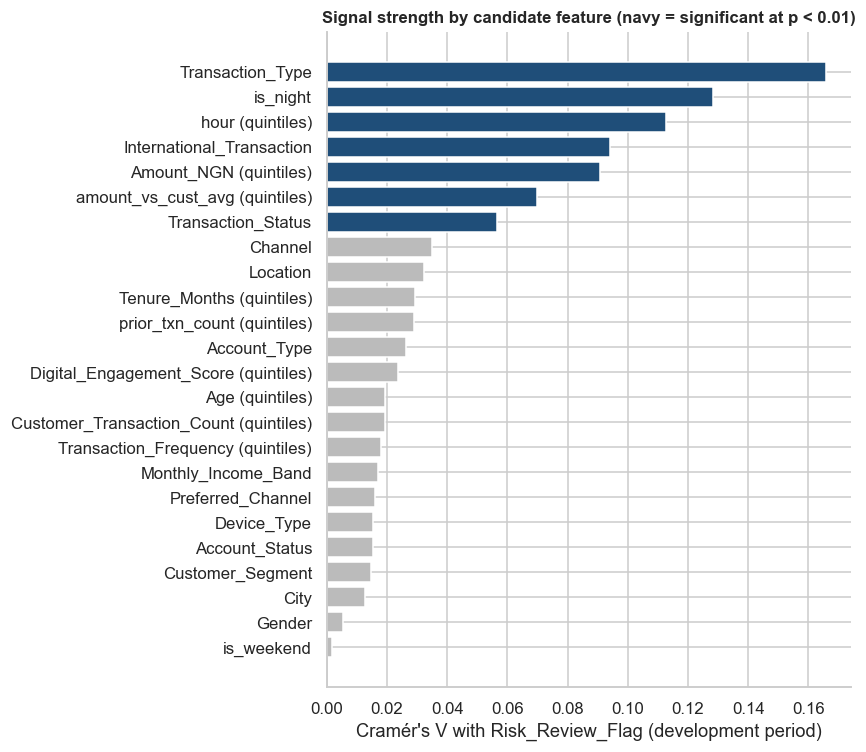

In [11]:
def signal_table(df, cat_cols, num_cols):
    rows, X = [], df.copy()
    for c in num_cols: X[c + "_bin"] = pd.qcut(X[c], 5, duplicates="drop")
    for c in cat_cols + [c + "_bin" for c in num_cols]:
        ct = pd.crosstab(X[c], X.y); chi2, p, _, _ = chi2_contingency(ct); rates = X.groupby(c, observed=True).y.mean()
        rows.append({"Feature": c.replace("_bin", " (quintiles)"), "Min_rate": rates.min(), "Max_rate": rates.max(), "Spread": rates.max() - rates.min(),
                     "Cramers_V": np.sqrt(chi2 / (len(X) * (min(ct.shape) - 1))), "p_value": p})
    out = pd.DataFrame(rows).sort_values("Cramers_V", ascending=False); out["Significant (p<0.01)"] = np.where(out.p_value < 0.01, "yes", "no"); return out
sig = signal_table(dev, ["Transaction_Type","International_Transaction","Transaction_Status","is_night","Channel","Device_Type","Location","Customer_Segment","Account_Type","City","Gender","Monthly_Income_Band","Preferred_Channel","Account_Status","is_weekend"],
                   ["Amount_NGN","hour","Age","Tenure_Months","Digital_Engagement_Score","Customer_Transaction_Count","Transaction_Frequency","amount_vs_cust_avg","prior_txn_count"])
display(sig.round(4).reset_index(drop=True))
plt.figure(figsize=(8, 7)); plt.barh(sig.Feature[::-1], sig.Cramers_V[::-1], color=np.where(sig.p_value < 0.01, NAVY, "#bbbbbb")[::-1])
plt.xlabel("Cramér's V with Risk_Review_Flag (development period)"); plt.title("Signal strength by candidate feature (navy = significant at p < 0.01)"); savefig("A1_feature_signal.png"); plt.show()

### 4.2 The amount effect is a *step*; where exactly is it?
Week 3 defined `high_amount` as the training 90th percentile (NGN 142,058) - a statistical convenience, not a business threshold. Here the cut-off is **learned by scanning candidate cut-offs (NGN 100k–200k, step 10k) and keeping the one that best separates the flag on the training window only**, then checked for stability across the five rolling windows.

**Single-flag ROC-AUC of 'amount >= cut-off' in each training window (higher = better separation):**

,100k,110k,120k,130k,140k,150k,160k,170k,180k,190k,200k
fold 1 (train n=4800),0.5478,0.5479,0.5496,0.5509,0.5511,0.5504,0.5534,0.5487,0.5454,0.5410,0.5363
fold 2 (train n=6240),0.5435,0.5436,0.5461,0.5466,0.5473,0.5474,0.5503,0.5450,0.5427,0.5388,0.5348
fold 3 (train n=7680),0.5465,0.5467,0.5496,0.5505,0.5514,0.5506,0.5533,0.5485,0.5463,0.5419,0.5382
fold 4 (train n=9120),0.5481,0.5484,0.5509,0.5511,0.5522,0.5515,0.5544,0.5507,0.5477,0.5435,0.5406
fold 5 (train n=10560),0.5462,0.5469,0.5495,0.5501,0.5516,0.5517,0.5542,0.5509,0.5480,0.5440,0.5405
Final training window (60%),0.5450,0.5453,0.5481,0.5486,0.5494,0.5497,0.5523,0.5478,0.5457,0.5414,0.5377


**Cut-off chosen in each window:** fold 1 (train n=4800): **160k**; fold 2 (train n=6240): **160k**; fold 3 (train n=7680): **160k**; fold 4 (train n=9120): **160k**; fold 5 (train n=10560): **160k**; Final training window (60%): **160k**

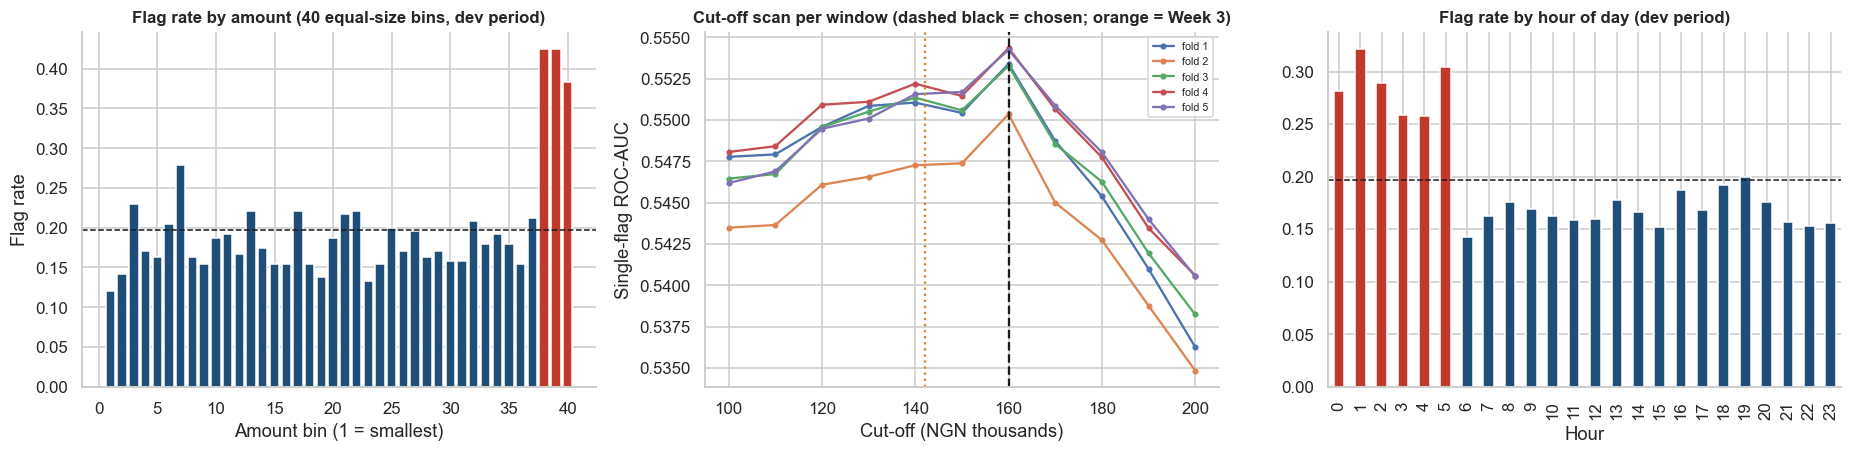

Final learned cut-off on the training window: NGN 160,000   (Week 3: NGN 142,058)
Dev-period flag rate below / above the cut-off: 17.8% / 40.0%  (804 transactions above)


In [12]:
CUT_GRID = np.arange(100_000, 200_001, 10_000)
def learn_cut(A):
    s = pd.Series([roc_auc_score(A.y, (A.Amount_NGN >= t).astype(int)) for t in CUT_GRID], index=CUT_GRID); return float(s.idxmax()), s

cut_rows = {}
for k, (a, b) in enumerate(OUTER, 1):
    c, s = learn_cut(data.iloc[a]); cut_rows[f"fold {k} (train n={len(a)})"] = s
cut_rows["Final training window (60%)"] = learn_cut(train)[1]
cut_tbl = pd.DataFrame(cut_rows).T; cut_tbl.columns = [f"{int(c/1000)}k" for c in cut_tbl.columns]
display(Markdown("**Single-flag ROC-AUC of 'amount >= cut-off' in each training window (higher = better separation):**")); display(cut_tbl.round(4))
chosen = cut_tbl.idxmax(axis=1); display(Markdown("**Cut-off chosen in each window:** " + "; ".join(f"{i}: **{v}**" for i, v in chosen.items())))
HIGH_AMT_CUT, _ = learn_cut(train)

fig, ax = plt.subplots(1, 3, figsize=(17, 4.3)); q = pd.qcut(dev.Amount_NGN, 40, duplicates="drop"); r = dev.groupby(q, observed=True).y.mean().values
ax[0].bar(range(1, len(r)+1), r, color=[RED if v > .30 else NAVY for v in r]); ax[0].axhline(dev.y.mean(), c="k", ls="--", lw=1)
ax[0].set_title("Flag rate by amount (40 equal-size bins, dev period)"); ax[0].set_xlabel("Amount bin (1 = smallest)"); ax[0].set_ylabel("Flag rate")
for c_, col in cut_tbl.iloc[:5].iterrows(): ax[1].plot(CUT_GRID/1000, col.values, marker="o", ms=3, label=c_.split(" (")[0])
ax[1].axvline(HIGH_AMT_CUT/1000, c="k", ls="--"); ax[1].axvline(HIGH_AMT_W3/1000, c=ORANGE, ls=":"); ax[1].set_title("Cut-off scan per window (dashed black = chosen; orange = Week 3)"); ax[1].set_xlabel("Cut-off (NGN thousands)"); ax[1].set_ylabel("Single-flag ROC-AUC"); ax[1].legend(fontsize=7)
dev.groupby("hour").y.mean().plot(kind="bar", ax=ax[2], color=[RED if h <= 5 else NAVY for h in range(24)]); ax[2].axhline(dev.y.mean(), c="k", ls="--", lw=1); ax[2].set_title("Flag rate by hour of day (dev period)"); ax[2].set_xlabel("Hour")
savefig("A2_amount_step_and_patterns.png"); plt.show()
print(f"Final learned cut-off on the training window: NGN {HIGH_AMT_CUT:,.0f}   (Week 3: NGN {HIGH_AMT_W3:,.0f})")
below, above = dev[dev.Amount_NGN < HIGH_AMT_CUT].y.mean(), dev[dev.Amount_NGN >= HIGH_AMT_CUT].y.mean()
print(f"Dev-period flag rate below / above the cut-off: {below:.1%} / {above:.1%}  ({int((dev.Amount_NGN >= HIGH_AMT_CUT).sum())} transactions above)")

### 4.3 Feature experiments (nested rolling-origin, paired bootstrap)
Every experiment is a **Logistic Regression** (balanced weights, C = 0.1; binary flags passed through, continuous fields standardised) fitted inside each rolling window and scored on the *next* block, so all 7,200 predictions are out-of-time. Each variant is compared with the incumbent (**V0**) on the *same* bootstrap resamples (paired, 500 resamples).

**Decision rules (written before looking at the results):**
1. **Add / swap a feature** only if the 95% interval of its ROC-AUC is entirely above 0 *and* the field is known at the moment of the transaction. A gain from a field that is not available at decision time is reported but never adopted.
2. **Alternative encodings** replace V0 only if they are better by rule 1. A *simpler* alternative that is non-inferior (mean ROC-AUC and PR-AUC both ≥ −0.003) is marked **eligible**, and adopting it is then a written judgement call. *(Disclosure: the first run showed that a purely mechanical reading of this rule would collapse six transaction types into two; I tightened the wording to "eligible + judgement" and say so here rather than hide it.)*
3. **Retain** a feature only if removing it costs ROC-AUC with the 95% interval entirely below 0.

In [13]:
def add_feats(X, cut, p90):
    '''Derived columns used by the experiments and models. cut / p90 are learned on training data only.'''
    X = X.copy()
    X["ha"] = (X.Amount_NGN >= cut).astype(int); X["high_amount"] = X["ha"]; X["ha_p90"] = (X.Amount_NGN >= p90).astype(int)
    X["night_x_intl"] = X.is_night * X.is_international; X["night_x_ha"] = X.is_night * X.ha; X["intl_x_ha"] = X.is_international * X.ha
    X["risky_x_ha"] = X.risky_type * X.ha; X["risky_x_night"] = X.risky_type * X.is_night; X["intl_x_risky"] = X.is_international * X.risky_type
    X["amount_band"] = pd.cut(X.Amount_NGN, [0, 5e3, 20e3, 50e3, 100e3, cut, 1e12], labels=False).astype(str)
    return X

FOLD_FRAMES = []                                   # (train window, test block, cut-off learned in that window)
for a, b in OUTER:
    A, Bk = data.iloc[a], data.iloc[b]; cut, _ = learn_cut(A)
    FOLD_FRAMES.append((add_feats(A, cut, A.Amount_NGN.quantile(0.90)), add_feats(Bk, cut, A.Amount_NGN.quantile(0.90)), cut))
print("Cut-off learned in each rolling window:", [int(f[2]) for f in FOLD_FRAMES])

BINARY = {"ha","high_amount","ha_p90","high_amount_w3","is_international","is_night","is_weekend","risky_type","night_x_intl","night_x_ha","intl_x_ha","risky_x_ha","risky_x_night","intl_x_risky"}
def make_pre2(cat, num):
    '''One-hot categoricals, binary flags passed through unchanged (so coefficients read as 'signal present vs absent'), other numerics standardised.'''
    b = [c for c in num if c in BINARY]; c_ = [c for c in num if c not in BINARY]
    tr = [("cat", OneHotEncoder(handle_unknown="ignore"), cat), ("bin", "passthrough", b)]
    if c_: tr.append(("num", StandardScaler(), c_))
    return ColumnTransformer(tr, sparse_threshold=0)

def nested_lr(cat, num, C_=0.1):
    out = []
    for A, Bk, _ in FOLD_FRAMES:
        m = Pipeline([("pre", make_pre2(cat, num)), ("clf", LogisticRegression(C=C_, class_weight="balanced", max_iter=3000, random_state=SEED))]).fit(A[cat+num], A.y)
        out.append(m.predict_proba(Bk[cat+num])[:, 1])
    return np.concatenate(out)

CORE_N = ["ha", "is_international", "is_night"]
INTER = ["night_x_intl","night_x_ha","intl_x_ha","risky_x_ha","risky_x_night"]
VARIANTS = {   # name: (kind, categorical, numeric, available at decision time?)
 "V0  INCUMBENT: type + high-amount + international + night":      ("base", ["Transaction_Type"], CORE_N, "yes"),
 "R1  remove Transaction_Type":                                    ("remove", [], CORE_N, "yes"),
 "R2  remove high-amount flag":                                    ("remove", ["Transaction_Type"], ["is_international","is_night"], "yes"),
 "R3  remove is_international":                                    ("remove", ["Transaction_Type"], ["ha","is_night"], "yes"),
 "R4  remove is_night":                                            ("remove", ["Transaction_Type"], ["ha","is_international"], "yes"),
 "A1  add log_amount":                                             ("add", ["Transaction_Type"], CORE_N + ["log_amount"], "yes"),
 "A2  add hour of day":                                            ("add", ["Transaction_Type"], CORE_N + ["hour"], "yes"),
 "A3  add weekend flag":                                           ("add", ["Transaction_Type"], CORE_N + ["is_weekend"], "yes"),
 "A4  add channel + device":                                       ("add", ["Transaction_Type","Channel","Device_Type"], CORE_N, "yes"),
 "A5  add pairwise interactions":                                  ("add", ["Transaction_Type"], CORE_N + INTER, "yes"),
 "A6  add customer demographics (segment, account type, age, tenure, engagement)": ("add", ["Transaction_Type","Customer_Segment","Account_Type"], CORE_N + ["Age","Tenure_Months","Digital_Engagement_Score"], "yes"),
 "A7  add past-only customer history":                             ("add", ["Transaction_Type"], CORE_N + ["amount_vs_cust_avg","prior_txn_count"], "yes"),
 "A8  add Week 2 whole-window customer counts (look-ahead)":       ("add", ["Transaction_Type"], CORE_N + ["Customer_Transaction_Count","Transaction_Frequency"], "NO - uses future rows"),
 "A9  add Transaction_Status (sensitivity only)":                  ("add", ["Transaction_Type","Transaction_Status"], CORE_N, "NO - may not be known at decision time"),
 "A10  add Account_Status (sensitivity only)":                      ("add", ["Transaction_Type","Account_Status"], CORE_N, "NO - availability unconfirmed"),
 "A12  add time since the customer's previous transaction (Week 3 v2 column log_hours_since_prev)": ("add", ["Transaction_Type"], CORE_N + ["log_hours_since_prev"], "yes"),
 "A11  add international x Transfer/Cash interaction (prompted by DA query, SQL Q14)": ("add", ["Transaction_Type"], CORE_N + ["intl_x_risky"], "yes"),
 "S1  alternative: Transaction_Type collapsed to Transfer/Cash vs other": ("alt", [], ["risky_type"] + CORE_N, "yes"),
 "S2  alternative: six amount bands instead of one flag":          ("alt", ["Transaction_Type","amount_band"], ["is_international","is_night"], "yes"),
 "S3  alternative: Week 3 features (log-amount + 90th-percentile flag)": ("alt", ["Transaction_Type"], ["log_amount","ha_p90","is_international","is_night"], "yes"),
}
t0 = time.time()
VAR_P = {k: nested_lr(cat, num) for k, (_, cat, num, _) in VARIANTS.items()}
print(f"{len(VARIANTS)} variants x 5 windows fitted in {time.time()-t0:.0f}s")

Cut-off learned in each rolling window: [160000, 160000, 160000, 160000, 160000]
20 variants x 5 windows fitted in 8s


,Pooled ROC-AUC,Pooled PR-AUC,dROC-AUC vs V0 [95% CI],dPR-AUC vs V0,Windows where >= V0,Known at decision time?,Decision (rule)
Variant,,,,,,,
V0 INCUMBENT: type + high-amount + international + night,0.6735,0.3358,"+0.0000 [+0.0000, +0.0000]",+0.0000,5/5,yes,INCUMBENT
R1 remove Transaction_Type,0.6184,0.3034,"-0.0554 [-0.0688, -0.0426]",-0.0327,0/5,yes,RETAIN (removing it hurts)
R2 remove high-amount flag,0.6537,0.3051,"-0.0197 [-0.0277, -0.0115]",-0.0305,0/5,yes,RETAIN (removing it hurts)
R3 remove is_international,0.6658,0.3275,"-0.0077 [-0.0135, -0.0017]",-0.0086,1/5,yes,RETAIN (removing it hurts)
R4 remove is_night,0.6455,0.3132,"-0.0280 [-0.0383, -0.0184]",-0.0226,0/5,yes,RETAIN (removing it hurts)
A1 add log_amount,0.6729,0.3385,"-0.0006 [-0.0036, +0.0025]",+0.0027,3/5,yes,Not adopted: no reliable gain
A2 add hour of day,0.6720,0.3361,"-0.0016 [-0.0043, +0.0013]",+0.0002,2/5,yes,Not adopted: no reliable gain
A3 add weekend flag,0.6720,0.3339,"-0.0015 [-0.0051, +0.0024]",-0.0019,2/5,yes,Not adopted: no reliable gain
A4 add channel + device,0.6722,0.3385,"-0.0014 [-0.0078, +0.0044]",+0.0025,4/5,yes,Not adopted: no reliable gain


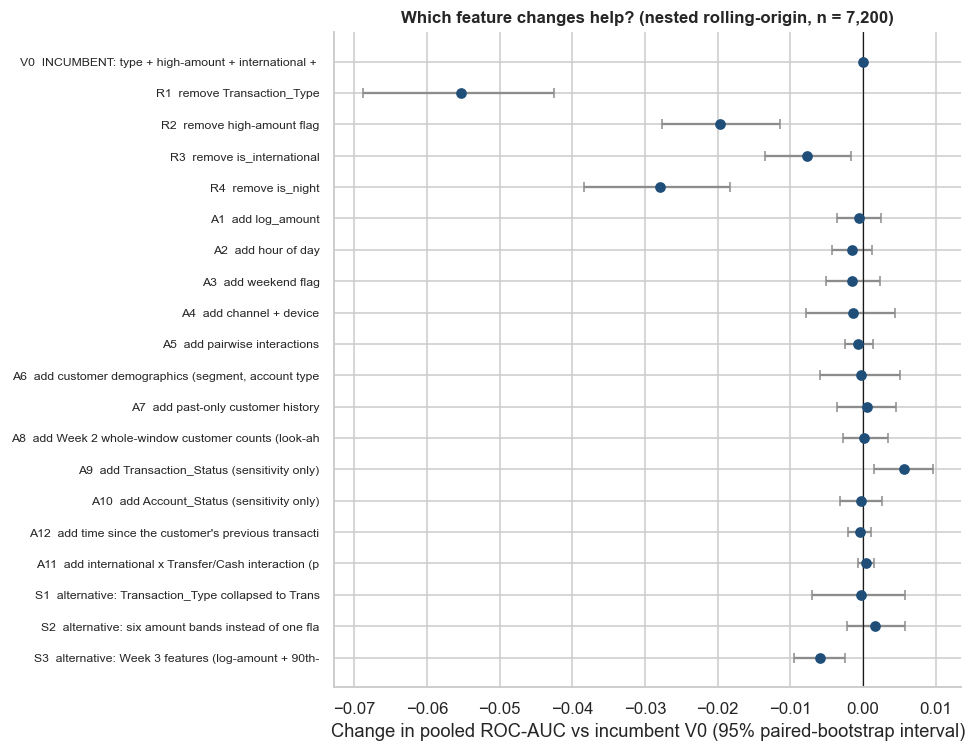

In [14]:
# compare each of the 20 model versions to the chosen four-feature model using 500 reshuffled copies of the predictions, 
# labels each one as keep, remove or ignore, and shows the results in a table and a chart.
rng = np.random.default_rng(SEED); BOOT = [rng.integers(0, len(Y_NEST), len(Y_NEST)) for _ in range(500)]
v0 = list(VARIANTS)[0]; p0 = VAR_P[v0]
base_auc = np.array([roc_auc_score(Y_NEST[ix], p0[ix]) for ix in BOOT]); base_pr = np.array([average_precision_score(Y_NEST[ix], p0[ix]) for ix in BOOT])
rows = []
for k, (kind, cat, num, avail) in VARIANTS.items():
    p = VAR_P[k]; da = np.array([roc_auc_score(Y_NEST[ix], p[ix]) for ix in BOOT]) - base_auc; dp = np.array([average_precision_score(Y_NEST[ix], p[ix]) for ix in BOOT]) - base_pr
    wins = sum(roc_auc_score(Y_NEST[FOLD_ID == f], p[FOLD_ID == f]) >= roc_auc_score(Y_NEST[FOLD_ID == f], p0[FOLD_ID == f]) - 1e-12 for f in range(5))
    lo, hi = np.percentile(da, [2.5, 97.5])
    if kind == "base": dec = "INCUMBENT"
    elif kind == "remove": dec = "RETAIN (removing it hurts)" if hi < 0 else "Candidate for removal (no measurable loss)"
    elif kind == "add" and lo > 0: dec = "ADOPT" if avail == "yes" else "Gain real but NOT adopted: " + avail.split(" - ")[1]
    elif kind == "add": dec = "Not adopted: no reliable gain"
    elif lo > 0: dec = "Adopt alternative"
    elif da.mean() >= -0.003 and dp.mean() >= -0.003 and k.startswith("S1"): dec = "Eligible (non-inferior) - NOT adopted: judgement call, see note"
    else: dec = "Keep incumbent"
    rows.append({"Variant": k, "Pooled ROC-AUC": roc_auc_score(Y_NEST, p), "Pooled PR-AUC": average_precision_score(Y_NEST, p),
                 "dROC-AUC vs V0 [95% CI]": f"{da.mean():+.4f} [{lo:+.4f}, {hi:+.4f}]", "dPR-AUC vs V0": f"{dp.mean():+.4f}",
                 "Windows where >= V0": f"{wins}/5", "Known at decision time?": avail, "Decision (rule)": dec, "_da": da.mean(), "_lo": lo, "_hi": hi})
EXP = pd.DataFrame(rows).set_index("Variant")
display(EXP.drop(columns=["_da","_lo","_hi"]).round(4))

fig, ax = plt.subplots(figsize=(9, 7)); e = EXP.iloc[::-1]; yy = np.arange(len(e))
ax.errorbar(e._da, yy, xerr=[e._da - e._lo, e._hi - e._da], fmt="o", color=NAVY, ecolor=GREY, capsize=3); ax.axvline(0, c="k", lw=.8)
ax.set_yticks(yy); ax.set_yticklabels([v.split("  ")[0] + "  " + v.split("  ", 1)[1][:48] for v in e.index], fontsize=8); ax.set_xlabel("Change in pooled ROC-AUC vs incumbent V0 (95% paired-bootstrap interval)")
ax.set_title("Which feature changes help? (nested rolling-origin, n = 7,200)"); savefig("A3_feature_experiments.png"); plt.show()

**Reading the experiments.**
1. **Every retained signal earns its place.** Removing Transaction_Type costs 0.055 ROC-AUC, night-time 0.028, the high-amount flag 0.020 and is_international 0.008 - every interval is entirely below zero.
2. **Nothing added helps reliably.** log-amount, hour, weekend, channel/device, interactions, customer demographics, past-only history, the look-ahead counts and Account_Status all have intervals that straddle zero (≤ 0.002). This confirms the Week 3 verdict under a stricter protocol (7,200 out-of-time predictions).
3. **The only field with a real gain is Transaction_Status** (+0.006, interval above zero). It is deliberately excluded because it may not be known when a transaction is scored; the cost of excluding it is small and now documented.
4. **The refinement that matters is the amount cut-off.** Swapping the Week 3 features (log-amount + 90th-percentile flag) for the final ones is worth +0.006 ROC-AUC with an interval above zero (S3 row, sign reversed), and the scan picks NGN 160,000 in all five windows.
5. **Judgement call, disclosed.** S1 (collapsing six transaction types into 'Transfer/Cash vs other') is statistically indistinguishable (ROC-AUC −0.0003, PR-AUC −0.0025), so it is *eligible* under the non-inferiority clause. I kept the six types: collapsing would discard the business-readable split between Transfer, Cash Withdrawal and the four low-risk types (Section 7) for a marginal simplification.

### 4.4 Final feature decisions  (Feature → Decision → Reason → Evidence)

In [16]:
def dsum(k): r = EXP.loc[[i for i in EXP.index if i.startswith(k)][0]]; return r["dROC-AUC vs V0 [95% CI]"]
FEAT_CAT, FEAT_NUM = ["Transaction_Type"], ["high_amount", "is_international", "is_night"]
FEATURES = FEAT_CAT + FEAT_NUM
decisions = pd.DataFrame([
 ["KEEP Transaction_Type (6 levels)", "Transfer and Cash Withdrawal carry the highest flag rates; removing the field costs ranking power", f"R1: {dsum('R1')}"],
 ["KEEP high_amount, and CHANGE its cut-off from NGN 142,058 (train 90th percentile) to NGN %s (scan-learned)" % f"{HIGH_AMT_CUT:,.0f}", "The amount effect is a step; the scan picks the same cut-off in every rolling window; the new cut-off scores >= the Week 3 cut-off in the windows shown in S3", f"R2: {dsum('R2')};  S3 (Week 3 features) vs V0: {dsum('S3')}"],
 ["KEEP is_international", "About twice the flag rate; removing it costs ranking power even though only ~4% of transactions are international", f"R3: {dsum('R3')}"],
 ["KEEP is_night (00:00-05:59)", "A block of elevated risk, not a straight line; removing it costs ranking power", f"R4: {dsum('R4')}"],
 ["REMOVE log_amount (kept in Week 3)", "Adds nothing once the high-amount step is present (it carried ~0 weight in Week 3); fewer inputs, same ranking", f"A1: {dsum('A1')}"],
 ["REJECT hour, weekend, channel/device, interactions", "No reliable gain over the four core signals; channel/device already failed the Week 3 significance test", f"A2: {dsum('A2')};  A3: {dsum('A3')};  A4: {dsum('A4')};  A5: {dsum('A5')}"],
 ["REJECT international x Transfer/Cash interaction (new: prompted by the Data Analytics intern's domestic-vs-international-by-type query)", "The international effect is present within every transaction type, so it is not a type effect in disguise; an explicit interaction adds nothing", f"A11: {dsum('A11')}"],
 ["REJECT customer demographics and past-only history", "No signal in significance tests (Section 4.1) and no predictive gain; also removes a fairness concern", f"A6: {dsum('A6')};  A7: {dsum('A7')};  A12 (log_hours_since_prev from v2): {dsum('A12')}"],
 ["REJECT Week 2 whole-window customer counts", "Look-ahead (count future rows) and unavailable for new customers", f"A8: {dsum('A8')}"],
 ["KEEP Transaction_Status and Account_Status OUT (Week 2/3 decision confirmed)", "Status may not be known when a transaction is scored. Transaction_Status is the one field with a real but small gain; the cost of excluding it is documented, not hidden", f"A9: {dsum('A9')};  A10: {dsum('A10')}"],
 ["KEEP the six transaction types (do not collapse to 'Transfer/Cash vs other'); REJECT six amount bands", "S1 is non-inferior, so it is *eligible* under rule 2, but collapsing discards business-readable distinctions (Transfer vs Cash vs the four low-risk types) for a marginal simplification - a judgement call, disclosed. S2 is not reliably better", f"S1: {dsum('S1')};  S2: {dsum('S2')}"],
 ["REMOVE identifiers and Customer_Name", "No behavioural meaning (Modelling_Use = No in the data dictionary); memorisation risk", "Dictionary + Week 2 decision retained"],
], columns=["Feature decision", "Reason", "Evidence (paired bootstrap, nested rolling-origin)"])
display(decisions.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))
print("FINAL FEATURE SET (4 inputs):", FEATURES, "| high_amount = Amount_NGN >=", f"{HIGH_AMT_CUT:,.0f}")

Feature decision,Reason,"Evidence (paired bootstrap, nested rolling-origin)"
KEEP Transaction_Type (6 levels),Transfer and Cash Withdrawal carry the highest flag rates; removing the field costs ranking power,"R1: -0.0554 [-0.0688, -0.0426]"
"KEEP high_amount, and CHANGE its cut-off from NGN 142,058 (train 90th percentile) to NGN 160,000 (scan-learned)",The amount effect is a step; the scan picks the same cut-off in every rolling window; the new cut-off scores >= the Week 3 cut-off in the windows shown in S3,"R2: -0.0197 [-0.0277, -0.0115]; S3 (Week 3 features) vs V0: -0.0059 [-0.0095, -0.0024]"
KEEP is_international,About twice the flag rate; removing it costs ranking power even though only ~4% of transactions are international,"R3: -0.0077 [-0.0135, -0.0017]"
KEEP is_night (00:00-05:59),"A block of elevated risk, not a straight line; removing it costs ranking power","R4: -0.0280 [-0.0383, -0.0184]"
REMOVE log_amount (kept in Week 3),"Adds nothing once the high-amount step is present (it carried ~0 weight in Week 3); fewer inputs, same ranking","A1: -0.0006 [-0.0036, +0.0025]"
"REJECT hour, weekend, channel/device, interactions",No reliable gain over the four core signals; channel/device already failed the Week 3 significance test,"A2: -0.0016 [-0.0043, +0.0013]; A3: -0.0015 [-0.0051, +0.0024]; A4: -0.0014 [-0.0078, +0.0044]; A5: -0.0007 [-0.0024, +0.0013]"
REJECT international x Transfer/Cash interaction (new: prompted by the Data Analytics intern's domestic-vs-international-by-type query),"The international effect is present within every transaction type, so it is not a type effect in disguise; an explicit interaction adds nothing","A11: +0.0004 [-0.0006, +0.0015]"
REJECT customer demographics and past-only history,No signal in significance tests (Section 4.1) and no predictive gain; also removes a fairness concern,"A6: -0.0002 [-0.0059, +0.0050]; A7: +0.0005 [-0.0036, +0.0045]; A12 (log_hours_since_prev from v2): -0.0004 [-0.0020, +0.0010]"
REJECT Week 2 whole-window customer counts,Look-ahead (count future rows) and unavailable for new customers,"A8: +0.0001 [-0.0028, +0.0034]"
KEEP Transaction_Status and Account_Status OUT (Week 2/3 decision confirmed),"Status may not be known when a transaction is scored. Transaction_Status is the one field with a real but small gain; the cost of excluding it is documented, not hidden","A9: +0.0056 [+0.0015, +0.0096]; A10: -0.0003 [-0.0032, +0.0026]"


FINAL FEATURE SET (4 inputs): ['Transaction_Type', 'high_amount', 'is_international', 'is_night'] | high_amount = Amount_NGN >= 160,000


In [17]:
# ---- final feature columns on every row, built with the TRAIN-learned cut-off, and the final modelling dataset
data = add_feats(data, HIGH_AMT_CUT, HIGH_AMT_W3); train, valid, test = (data[data.split == s].copy() for s in ["train","validation","test"])
# ---- FINAL DATASET = the Week 3 file (v2), refined. It is not rebuilt from scratch: v2 is loaded and changed on purpose.
final_ds = v2.copy()
n_cut_rows = int((final_ds.high_amount.values != data.high_amount.values).sum())
final_ds["high_amount"] = data.high_amount.values                                              # refined cut-off
final_ds = final_ds.drop(columns=["log_amount", "amount_vs_cust_avg", "prior_txn_count", "log_hours_since_prev"])
final_ds["Transaction_Status"] = data.Transaction_Status.values                                # reference column only; NOT a model input
assert final_ds[FEATURES].equals(data[FEATURES].reset_index(drop=True)), "Final dataset features differ from the modelling frame"
final_ds.to_csv(PROC/"FinTrust_Modelling_Dataset_Final.csv", index=False)
changes = pd.DataFrame([
 [f"high_amount: cut-off NGN {HIGH_AMT_W3:,.0f} -> NGN {HIGH_AMT_CUT:,.0f}", f"{n_cut_rows} rows change value; the scan picks the new cut-off in every window", f"S3 vs final: {dsum('S3')}"],
 ["Remove log_amount", "Adds nothing once the step flag is present", f"A1: {dsum('A1')}"],
 ["Remove amount_vs_cust_avg and prior_txn_count", "No reliable gain from past-only customer history", f"A7: {dsum('A7')}"],
 ["Remove log_hours_since_prev", "No reliable gain from the recency feature (re-tested in Week 4)", f"A12: {dsum('A12')}"],
 ["Add Transaction_Status (reference column only)", "Needed for the sensitivity test and the DA comparison; NOT a model input", f"A9: {dsum('A9')}"],
 ["Unchanged", "Transaction_ID, Customer_ID, timestamp, split labels, target, Transaction_Type, is_international, is_night, hour, Channel, Device_Type, Amount_NGN", "Verified identical to the Week 3 file in Section 1"],
], columns=["Change to the Week 3 dataset (v2)", "Reason", "Evidence"])
display(Markdown("**How the final dataset differs from your Week 3 dataset (v2):**")); display(changes.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))
print("Saved final modelling dataset (Week 3 v2, refined):", (PROC/"FinTrust_Modelling_Dataset_Final.csv").relative_to(ROOT), final_ds.shape)

**How the final dataset differs from your Week 3 dataset (v2):**

Change to the Week 3 dataset (v2),Reason,Evidence
"high_amount: cut-off NGN 142,058 -> NGN 160,000",197 rows change value; the scan picks the new cut-off in every window,"S3 vs final: -0.0059 [-0.0095, -0.0024]"
Remove log_amount,Adds nothing once the step flag is present,"A1: -0.0006 [-0.0036, +0.0025]"
Remove amount_vs_cust_avg and prior_txn_count,No reliable gain from past-only customer history,"A7: +0.0005 [-0.0036, +0.0045]"
Remove log_hours_since_prev,No reliable gain from the recency feature (re-tested in Week 4),"A12: -0.0004 [-0.0020, +0.0010]"
Add Transaction_Status (reference column only),Needed for the sensitivity test and the DA comparison; NOT a model input,"A9: +0.0056 [+0.0015, +0.0096]"
Unchanged,"Transaction_ID, Customer_ID, timestamp, split labels, target, Transaction_Type, is_international, is_night, hour, Channel, Device_Type, Amount_NGN",Verified identical to the Week 3 file in Section 1


Saved final modelling dataset (Week 3 v2, refined): data\processed\FinTrust_Modelling_Dataset_Final.csv (12000, 14)


# 5. Part B - Final model evaluation
### 5.1 Candidate models
| Model | Inputs | Role |
|---|---|---|
| Always "No" | - | Floor: ~80.8% accuracy, zero use |
| Week 2 recipe | 12 fields (incl. customer attributes, look-ahead counts) | The original baseline, re-fitted |
| Week 3 candidate | 5 fields (log-amount, 90th-percentile flag, international, night, type) | Last week's chosen model |
| **Week 4 Logistic Regression** | **4 fields (final feature set)** | **Interpretable baseline; remains important whether or not it is selected** |
| Decision Tree · Random Forest · Gradient Boosting | the same 4 fields | Non-linear challengers |
| Random Forest / Gradient Boosting (extended) | + channel, device, hour | Tests whether richer inputs help (Week 3 open question) |
| Signal-count scorecard | the 4 signals, un-weighted count | A transparent no-fitting benchmark |

Hyper-parameters are tuned by 3-fold time-series cross-validation (scoring PR-AUC) **inside every training window** - nothing is tuned on the data it is later evaluated on.

In [18]:
EXT_CAT, EXT_NUM = FEAT_CAT + ["Channel", "Device_Type"], FEAT_NUM + ["hour"]
W2_CAT = ["Transaction_Type","Channel","Customer_Segment","Account_Type"]
W2_NUM = ["Amount_NGN","hour","is_international","Customer_Transaction_Count","Transaction_Frequency","Tenure_Months","Digital_Engagement_Score","Age"]
def lrb(C_=1.0): return LogisticRegression(C=C_, class_weight="balanced", max_iter=3000, random_state=SEED)
def hgb(): return HistGradientBoostingClassifier(random_state=SEED, early_stopping=False)
def rf(): return RandomForestClassifier(n_estimators=150, class_weight="balanced_subsample", random_state=SEED, n_jobs=1)
HGB_GRID = {"clf__max_depth": [2, 3], "clf__learning_rate": [0.03, 0.06], "clf__max_iter": [100, 200]}
RF_GRID  = {"clf__max_depth": [4, 6], "clf__min_samples_leaf": [10, 40]}
LR_NAME = "Week 4 LR (final features)"
SPECS = {
 "Week 2 recipe (LR, 12 features)":   dict(cat=W2_CAT, num=W2_NUM, est=lrb(1.0), grid=None),
 "Week 3 candidate (LR, 5 features)": dict(cat=["Transaction_Type"], num=["log_amount","ha_p90","is_international","is_night"], est=lrb(0.01), grid=None, scale="all"),
 LR_NAME:                             dict(cat=FEAT_CAT, num=FEAT_NUM, est=lrb(), grid={"clf__C": [0.01, 0.1, 1, 10]}),
 "Decision Tree":                     dict(cat=FEAT_CAT, num=FEAT_NUM, est=DecisionTreeClassifier(class_weight="balanced", random_state=SEED), grid={"clf__max_depth": [3,4,5,6], "clf__min_samples_leaf": [20,50,100]}),
 "Random Forest":                     dict(cat=FEAT_CAT, num=FEAT_NUM, est=rf(), grid=RF_GRID),
 "Gradient Boosting (HGB)":           dict(cat=FEAT_CAT, num=FEAT_NUM, est=hgb(), grid=HGB_GRID),
 "Random Forest (extended)":          dict(cat=EXT_CAT, num=EXT_NUM, est=rf(), grid=RF_GRID),
 "Gradient Boosting (extended)":      dict(cat=EXT_CAT, num=EXT_NUM, est=hgb(), grid=HGB_GRID),
}
def fit_spec(spec, A, inner=3):
    cols = spec["cat"] + spec["num"]
    pre = make_pre(spec["cat"], spec["num"], True) if spec.get("scale") == "all" else make_pre2(spec["cat"], spec["num"])
    pipe = Pipeline([("pre", pre), ("clf", clone(spec["est"]))])
    if spec["grid"]:
        gs = GridSearchCV(pipe, spec["grid"], cv=TimeSeriesSplit(inner), scoring="average_precision", n_jobs=1, refit=True).fit(A[cols], A.y)
        return gs.best_estimator_, {k.replace("clf__", ""): v for k, v in gs.best_params_.items()}
    return pipe.fit(A[cols], A.y), {}
def predict_spec(model, spec, X): return model.predict_proba(X[spec["cat"] + spec["num"]])[:, 1]
def scorecard(X): return X[["risky_type", "is_night", "is_international", "ha"]].sum(axis=1).values.astype(float)
ALL_NAMES = ["Always 'No'"] + list(SPECS) + ["Signal-count scorecard"]

### 5.2 Nested rolling-origin evaluation - the primary evidence

window 1/5 done (52s elapsed)
window 2/5 done (106s elapsed)
window 3/5 done (152s elapsed)
window 4/5 done (202s elapsed)
window 5/5 done (255s elapsed)


**Pooled out-of-time results, 5 rolling windows, n = 7,200 (mean [95% bootstrap interval]):**

,ROC-AUC,PR-AUC,Precision @ top 20%,Recall @ top 20%
Gradient Boosting (extended),"0.676 [0.660, 0.690]","0.340 [0.315, 0.364]","0.359 [0.333, 0.384]","0.358 [0.334, 0.382]"
Week 4 LR (final features),"0.674 [0.658, 0.688]","0.339 [0.315, 0.359]","0.359 [0.335, 0.382]","0.359 [0.336, 0.383]"
Random Forest (extended),"0.673 [0.657, 0.688]","0.333 [0.310, 0.357]","0.361 [0.337, 0.387]","0.360 [0.334, 0.386]"
Gradient Boosting (HGB),"0.673 [0.656, 0.687]","0.333 [0.310, 0.353]","0.360 [0.336, 0.384]","0.359 [0.334, 0.384]"
Decision Tree,"0.672 [0.655, 0.687]","0.327 [0.304, 0.350]","0.358 [0.333, 0.383]","0.358 [0.332, 0.382]"
Random Forest,"0.672 [0.656, 0.686]","0.331 [0.308, 0.353]","0.362 [0.336, 0.387]","0.361 [0.337, 0.386]"
Signal-count scorecard,"0.670 [0.656, 0.684]","0.302 [0.283, 0.319]","0.359 [0.334, 0.383]","0.358 [0.334, 0.382]"
"Week 3 candidate (LR, 5 features)","0.668 [0.651, 0.682]","0.332 [0.309, 0.353]","0.359 [0.335, 0.382]","0.358 [0.333, 0.383]"
"Week 2 recipe (LR, 12 features)","0.667 [0.652, 0.682]","0.328 [0.306, 0.350]","0.347 [0.321, 0.371]","0.346 [0.322, 0.370]"
Always 'No',"0.500 [0.500, 0.500]","0.200 [0.191, 0.209]","0.213 [0.192, 0.235]","0.212 [0.191, 0.232]"


**ROC-AUC in each rolling window (stability over time):**

,window 1,window 2,window 3,window 4,window 5,mean,std
"Week 2 recipe (LR, 12 features)",0.649,0.674,0.665,0.672,0.675,0.667,0.011
"Week 3 candidate (LR, 5 features)",0.679,0.665,0.652,0.674,0.672,0.668,0.010
Week 4 LR (final features),0.676,0.672,0.659,0.686,0.679,0.674,0.010
Decision Tree,0.681,0.669,0.668,0.674,0.674,0.673,0.005
Random Forest,0.675,0.665,0.659,0.679,0.674,0.670,0.008
Gradient Boosting (HGB),0.676,0.665,0.664,0.685,0.675,0.673,0.009
Random Forest (extended),0.685,0.671,0.656,0.683,0.676,0.674,0.012
Gradient Boosting (extended),0.681,0.669,0.668,0.680,0.677,0.675,0.006
Signal-count scorecard,0.672,0.670,0.657,0.671,0.679,0.670,0.008


**Hyper-parameters chosen inside each window:**

,window 1,window 2,window 3,window 4,window 5
Week 4 LR (final features),{'C': 1},{'C': 1},{'C': 1},{'C': 0.1},{'C': 0.1}
Decision Tree,"{'max_depth': 6, 'min_samples_leaf': 20}","{'max_depth': 6, 'min_samples_leaf': 50}","{'max_depth': 6, 'min_samples_leaf': 50}","{'max_depth': 6, 'min_samples_leaf': 20}","{'max_depth': 6, 'min_samples_leaf': 20}"
Random Forest,"{'max_depth': 4, 'min_samples_leaf': 10}","{'max_depth': 4, 'min_samples_leaf': 40}","{'max_depth': 4, 'min_samples_leaf': 10}","{'max_depth': 4, 'min_samples_leaf': 10}","{'max_depth': 4, 'min_samples_leaf': 10}"
Gradient Boosting (HGB),"{'learning_rate': 0.03, 'max_depth': 2, 'max_iter': 200}","{'learning_rate': 0.03, 'max_depth': 2, 'max_iter': 100}","{'learning_rate': 0.06, 'max_depth': 2, 'max_iter': 100}","{'learning_rate': 0.06, 'max_depth': 2, 'max_iter': 200}","{'learning_rate': 0.03, 'max_depth': 2, 'max_iter': 200}"
Random Forest (extended),"{'max_depth': 4, 'min_samples_leaf': 10}","{'max_depth': 6, 'min_samples_leaf': 10}","{'max_depth': 4, 'min_samples_leaf': 10}","{'max_depth': 4, 'min_samples_leaf': 10}","{'max_depth': 4, 'min_samples_leaf': 10}"
Gradient Boosting (extended),"{'learning_rate': 0.03, 'max_depth': 3, 'max_iter': 100}","{'learning_rate': 0.06, 'max_depth': 2, 'max_iter': 100}","{'learning_rate': 0.03, 'max_depth': 2, 'max_iter': 200}","{'learning_rate': 0.06, 'max_depth': 3, 'max_iter': 100}","{'learning_rate': 0.06, 'max_depth': 2, 'max_iter': 200}"


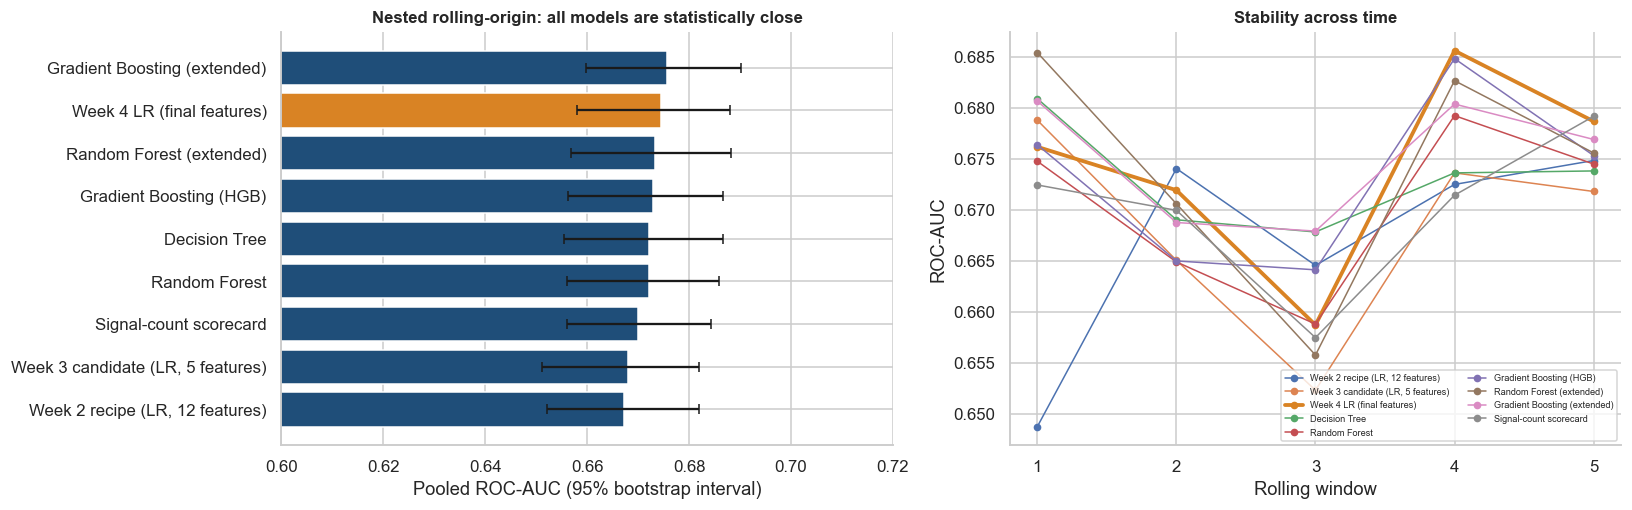

In [19]:
NEST_P = {n: [] for n in ALL_NAMES}; NEST_PARAMS = {n: [] for n in SPECS}; t0 = time.time()
for k, (A, Bk, cut) in enumerate(FOLD_FRAMES, 1):
    for name, spec in SPECS.items():
        m, prm = fit_spec(spec, A); NEST_P[name].append(predict_spec(m, spec, Bk)); NEST_PARAMS[name].append(prm)
    NEST_P["Signal-count scorecard"].append(scorecard(Bk)); NEST_P["Always 'No'"].append(np.zeros(len(Bk)))
    print(f"window {k}/5 done ({time.time()-t0:.0f}s elapsed)")
P_NEST = {n: np.concatenate(v) for n, v in NEST_P.items()}
SEL_NEST = {n: np.concatenate([top_mask(NEST_P[n][f], 0.20, JIT[OUTER[f][1]]) for f in range(5)]) for n in ALL_NAMES}   # 'review the top 20% of each window'

# bootstrap (500 resamples, same resamples for every model -> paired comparisons)
def boot_stats(name):
    p, sel, out = P_NEST[name], SEL_NEST[name], []
    for ix in BOOT:
        y_ = Y_NEST[ix]; s_ = sel[ix]; out.append((roc_auc_score(y_, p[ix]), average_precision_score(y_, p[ix]), (y_ * s_).sum() / max(s_.sum(), 1), (y_ * s_).sum() / y_.sum()))
    return np.array(out)
BS = {n: boot_stats(n) for n in ALL_NAMES}
def ci(a): return f"{a.mean():.3f} [{np.percentile(a,2.5):.3f}, {np.percentile(a,97.5):.3f}]"
nest_tbl = pd.DataFrame({n: {"ROC-AUC": ci(BS[n][:,0]), "PR-AUC": ci(BS[n][:,1]), "Precision @ top 20%": ci(BS[n][:,2]), "Recall @ top 20%": ci(BS[n][:,3]),
                             "_auc": roc_auc_score(Y_NEST, P_NEST[n])} for n in ALL_NAMES}).T.sort_values("_auc", ascending=False)
display(Markdown("**Pooled out-of-time results, 5 rolling windows, n = 7,200 (mean [95% bootstrap interval]):**")); display(nest_tbl.drop(columns="_auc"))
fold_auc = pd.DataFrame({n: [roc_auc_score(Y_NEST[FOLD_ID == f], P_NEST[n][FOLD_ID == f]) for f in range(5)] for n in ALL_NAMES if n != "Always 'No'"}, index=[f"window {i}" for i in range(1, 6)]).T
fold_auc["mean"] = fold_auc.mean(axis=1); fold_auc["std"] = fold_auc.iloc[:, :5].std(axis=1)
display(Markdown("**ROC-AUC in each rolling window (stability over time):**")); display(fold_auc.round(3))
display(Markdown("**Hyper-parameters chosen inside each window:**")); display(pd.DataFrame({n: [str(p) for p in NEST_PARAMS[n]] for n in SPECS if SPECS[n]["grid"]}, index=[f"window {i}" for i in range(1, 6)]).T.style.set_properties(**{"text-align": "left", "white-space": "normal"}))

fig, ax = plt.subplots(1, 2, figsize=(15, 4.8)); order = [n for n in nest_tbl.index if n != "Always 'No'"][::-1]
m_ = [BS[n][:,0].mean() for n in order]; lo_ = [np.percentile(BS[n][:,0], 2.5) for n in order]; hi_ = [np.percentile(BS[n][:,0], 97.5) for n in order]
ax[0].barh(order, m_, xerr=[np.array(m_) - lo_, np.array(hi_) - m_], color=[ORANGE if n == LR_NAME else NAVY for n in order], capsize=3); ax[0].set_xlim(0.60, 0.72); ax[0].axvline(0.5, c="k", lw=.5)
ax[0].set_xlabel("Pooled ROC-AUC (95% bootstrap interval)"); ax[0].set_title("Nested rolling-origin: all models are statistically close")
for n in fold_auc.index: ax[1].plot(range(1, 6), fold_auc.loc[n].iloc[:5], marker="o", ms=4, lw=2.5 if n == LR_NAME else 1, label=n, color=ORANGE if n == LR_NAME else None)
ax[1].set_xticks(range(1, 6)); ax[1].set_xlabel("Rolling window"); ax[1].set_ylabel("ROC-AUC"); ax[1].set_title("Stability across time"); ax[1].legend(fontsize=6, ncol=2); savefig("B2_nested_evaluation.png"); plt.show()

### 5.3 Paired differences - is any other model genuinely better than Logistic Regression?

In [20]:
rows = {}
for n in ALL_NAMES:
    if n in (LR_NAME, "Always 'No'"): continue
    d_ = BS[n] - BS[LR_NAME]; rows[n] = {"dROC-AUC": f"{d_[:,0].mean():+.4f} [{np.percentile(d_[:,0],2.5):+.4f}, {np.percentile(d_[:,0],97.5):+.4f}]",
         "dPR-AUC": f"{d_[:,1].mean():+.4f} [{np.percentile(d_[:,1],2.5):+.4f}, {np.percentile(d_[:,1],97.5):+.4f}]",
         "dPrecision@20%": f"{d_[:,2].mean():+.4f} [{np.percentile(d_[:,2],2.5):+.4f}, {np.percentile(d_[:,2],97.5):+.4f}]",
         "dRecall@20%": f"{d_[:,3].mean():+.4f} [{np.percentile(d_[:,3],2.5):+.4f}, {np.percentile(d_[:,3],97.5):+.4f}]"}
pair_tbl = pd.DataFrame(rows).T; display(Markdown(f"**Difference vs `{LR_NAME}` (positive = challenger better; same 500 resamples):**")); display(pair_tbl)

**Difference vs `Week 4 LR (final features)` (positive = challenger better; same 500 resamples):**

,dROC-AUC,dPR-AUC,dPrecision@20%,dRecall@20%
"Week 2 recipe (LR, 12 features)","-0.0071 [-0.0158, +0.0019]","-0.0106 [-0.0200, -0.0004]","-0.0127 [-0.0272, +0.0010]","-0.0128 [-0.0283, +0.0038]"
"Week 3 candidate (LR, 5 features)","-0.0064 [-0.0102, -0.0019]","-0.0069 [-0.0125, -0.0008]","-0.0007 [-0.0078, +0.0062]","-0.0005 [-0.0085, +0.0063]"
Decision Tree,"-0.0023 [-0.0075, +0.0027]","-0.0116 [-0.0217, -0.0024]","-0.0010 [-0.0113, +0.0092]","-0.0012 [-0.0145, +0.0109]"
Random Forest,"-0.0023 [-0.0061, +0.0013]","-0.0074 [-0.0164, +0.0002]","+0.0026 [-0.0059, +0.0123]","+0.0025 [-0.0076, +0.0126]"
Gradient Boosting (HGB),"-0.0015 [-0.0061, +0.0029]","-0.0058 [-0.0127, +0.0008]","+0.0008 [-0.0045, +0.0065]","+0.0008 [-0.0061, +0.0076]"
Random Forest (extended),"-0.0012 [-0.0070, +0.0048]","-0.0060 [-0.0168, +0.0042]","+0.0016 [-0.0112, +0.0146]","+0.0013 [-0.0125, +0.0159]"
Gradient Boosting (extended),"+0.0013 [-0.0051, +0.0068]","+0.0012 [-0.0073, +0.0104]","-0.0005 [-0.0086, +0.0077]","-0.0007 [-0.0096, +0.0084]"
Signal-count scorecard,"-0.0044 [-0.0101, +0.0015]","-0.0371 [-0.0451, -0.0283]","-0.0003 [-0.0109, +0.0101]","-0.0005 [-0.0115, +0.0096]"


**Reading the paired differences.** No other model is credibly better than Logistic Regression. ROC-AUC differences range from −0.007 to +0.001, and for every tree or ensemble model the interval contains zero; precision and recall at a 20% budget differ by at most about ±0.003. The extended-feature Gradient Boosting - Week 3's 'maybe' (0.691 vs 0.672) - comes out at +0.001 [−0.005, +0.007] here, so **its Week 3 lead does not reproduce under nested evaluation** and was most likely noise. The Decision Tree is lower on PR-AUC (−0.012, interval below zero). The un-weighted signal count matches Logistic Regression on precision and recall at a 20% budget but is lower on PR-AUC (−0.037) because its scores tie. The Week 3 candidate is below the final model by 0.006 ROC-AUC and 0.007 PR-AUC with intervals that exclude zero: the Week 4 refinement is real but small.

### 5.4 Model selection 
**Logistic Regression** (the interpretable baseline) is the final model **unless** a more complex model beats it on **both** ROC-AUC and PR-AUC with a paired-bootstrap 95% interval entirely above zero in the nested rolling-origin evaluation. If several qualify, the one with the larger ROC-AUC gain is chosen.

> This replaces Week 3's "within 0.01 of the best" rule, which was borderline for Logistic Regression and could flip with a library version.

In [22]:
sel_rows = []
for n in ["Decision Tree","Random Forest","Gradient Boosting (HGB)","Random Forest (extended)","Gradient Boosting (extended)"]:
    d_ = BS[n] - BS[LR_NAME]; qa, qp = np.percentile(d_[:,0], 2.5), np.percentile(d_[:,1], 2.5)
    sel_rows.append({"Challenger": n, "dROC-AUC lower bound": qa, "dPR-AUC lower bound": qp, "Beats LR on both (rule)": bool(qa > 0 and qp > 0), "_gain": d_[:,0].mean()})
sel = pd.DataFrame(sel_rows).set_index("Challenger"); display(sel.drop(columns="_gain").round(4))
qualifying = sel[sel["Beats LR on both (rule)"]]
FINAL_NAME = LR_NAME if qualifying.empty else qualifying["_gain"].idxmax()
display(Markdown(f"### FINAL MODEL: **{FINAL_NAME}**"))
FINAL_SPEC = SPECS[FINAL_NAME]

,dROC-AUC lower bound,dPR-AUC lower bound,Beats LR on both (rule)
Challenger,,,
Decision Tree,-0.0075,-0.0217,False
Random Forest,-0.0061,-0.0164,False
Gradient Boosting (HGB),-0.0061,-0.0127,False
Random Forest (extended),-0.0070,-0.0168,False
Gradient Boosting (extended),-0.0051,-0.0073,False


### FINAL MODEL: **Week 4 LR (final features)**

**Selection result.** No model meets the burden of proof (best lower bounds −0.005 ROC-AUC and −0.007 PR-AUC), so **Logistic Regression on four inputs is the final model.** This is a firmer basis than Week 3's choice, which depended on a 0.01 tolerance that Logistic Regression only just met. The choice is made for simplicity, explainability and safety - **not** because it is more accurate: every model sits at ROC-AUC ≈ 0.67.

### 5.5 Hold-out confirmation (same chronological split as Weeks 2–3)
Models are fitted on the first 60%, thresholds and calibration are chosen on the next 20%, and the final 20% is reported. Because the test period was already viewed in Week 3, **it confirms the nested result; it does not decide anything.** Two operating points are reported: a **20% review budget** (flag the top-scoring 20%) and the **F1-optimal threshold** (high-recall screening mode).

In [23]:
HOLD = {}; t0 = time.time()
for name, spec in SPECS.items():
    m, prm = fit_spec(spec, train); p_va, p_te = predict_spec(m, spec, valid), predict_spec(m, spec, test)
    HOLD[name] = dict(model=m, spec=spec, params=prm, p_va=p_va, p_te=p_te, thr=pick_threshold(valid.y, p_va), thr_cap=float(np.quantile(p_va, 0.80)))
sc_va, sc_te = scorecard(valid), scorecard(test)
thr_sc = min(t for t in [1, 2, 3, 4, 5] if (sc_va >= t).mean() <= 0.22); thr_sc_f1 = max([1, 2, 3, 4], key=lambda t: f1_score(valid.y, (sc_va >= t).astype(int)))
HOLD["Signal-count scorecard"] = dict(model=None, p_va=sc_va, p_te=sc_te, thr=float(thr_sc_f1), thr_cap=float(thr_sc))   # integer scores: 'flag if >= k signals'
print(f"hold-out models fitted in {time.time()-t0:.0f}s")

hold-out models fitted in 50s


In [24]:
# reference ceilings: what could ANY of the available fields achieve with a flexible model? (hold-out only)
CEIL_CAT = ["Transaction_Type","Channel","Device_Type","Location","Customer_Segment","Account_Type","City","Gender","Monthly_Income_Band","Preferred_Channel"]
CEIL_NUM = FEAT_NUM + ["hour","Age","Tenure_Months","Digital_Engagement_Score","log_amount","day_of_week"]
CEIL = {}
for lab, extra in [("Flexible model, ALL deployable fields", []), ("Flexible model, all fields + Transaction_Status", ["Transaction_Status"])]:
    sp = dict(cat=CEIL_CAT + extra, num=CEIL_NUM, est=HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=150, random_state=SEED), grid=None)
    m = fit_spec(sp, train)[0]; CEIL[lab] = (roc_auc_score(test.y, predict_spec(m, sp, test)), average_precision_score(test.y, predict_spec(m, sp, test)))

def hold_table(point):
    rows = {"Always 'No'": metric_row(test.y, np.zeros(len(test)) + 1e-9, 0.5) | {"ROC_AUC": 0.5, "PR_AUC": test.y.mean(), "Flagged_share": 0.0, "Lift@top20%": 1.0, "Recall@top20%": 0.2, "Precision@top20%": test.y.mean()}}
    for n in list(SPECS) + ["Signal-count scorecard"]:
        h = HOLD[n]; rows[n] = metric_row(test.y, h["p_te"], h["thr_cap"] if point == "cap" else h["thr"])
    return pd.DataFrame(rows).T
cap_tbl, f1_tbl = hold_table("cap"), hold_table("f1")
cols = ["Accuracy","Precision","Recall","F1","ROC_AUC","PR_AUC","Flagged_share"]
display(Markdown("**Operating point 1 - 20% review budget (default).** Threshold = 80th percentile of validation scores:")); display(cap_tbl[cols].round(3))
display(Markdown("**Operating point 2 - F1-optimal threshold (high-recall screening).** Threshold chosen on validation:")); display(f1_tbl[cols].round(3))
display(Markdown("**Reference ceilings (hold-out test)** - how far could a flexible model get with *more* fields?")); display(pd.DataFrame(CEIL, index=["ROC-AUC","PR-AUC"]).T.round(3))


**Operating point 1 - 20% review budget (default).** Threshold = 80th percentile of validation scores:

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Flagged_share
Always 'No',0.808,0.000,0.000,0.000,0.500,0.192,0.000
"Week 2 recipe (LR, 12 features)",0.740,0.327,0.331,0.329,0.677,0.328,0.195
"Week 3 candidate (LR, 5 features)",0.752,0.360,0.366,0.363,0.672,0.321,0.196
Week 4 LR (final features),0.751,0.357,0.368,0.362,0.679,0.325,0.198
Decision Tree,0.731,0.337,0.411,0.371,0.673,0.312,0.235
Random Forest,0.750,0.357,0.377,0.367,0.678,0.318,0.203
Gradient Boosting (HGB),0.747,0.353,0.381,0.367,0.678,0.319,0.208
Random Forest (extended),0.738,0.340,0.383,0.360,0.682,0.319,0.217
Gradient Boosting (extended),0.751,0.360,0.374,0.367,0.688,0.334,0.200
Signal-count scorecard,0.764,0.378,0.348,0.363,0.678,0.299,0.178


**Operating point 2 - F1-optimal threshold (high-recall screening).** Threshold chosen on validation:

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Flagged_share
Always 'No',0.808,0.000,0.000,0.000,0.500,0.192,0.000
"Week 2 recipe (LR, 12 features)",0.568,0.271,0.736,0.396,0.677,0.328,0.523
"Week 3 candidate (LR, 5 features)",0.511,0.259,0.829,0.395,0.672,0.321,0.616
Week 4 LR (final features),0.517,0.262,0.829,0.398,0.679,0.325,0.610
Decision Tree,0.517,0.262,0.829,0.398,0.673,0.312,0.610
Random Forest,0.517,0.262,0.829,0.398,0.678,0.318,0.610
Gradient Boosting (HGB),0.517,0.262,0.829,0.398,0.678,0.319,0.610
Random Forest (extended),0.512,0.260,0.833,0.397,0.682,0.319,0.616
Gradient Boosting (extended),0.505,0.258,0.840,0.395,0.688,0.334,0.625
Signal-count scorecard,0.517,0.262,0.829,0.398,0.678,0.299,0.610


**Reference ceilings (hold-out test)** - how far could a flexible model get with *more* fields?

,ROC-AUC,PR-AUC
"Flexible model, ALL deployable fields",0.680,0.335
"Flexible model, all fields + Transaction_Status",0.681,0.333


In [25]:
# bootstrap CIs on the hold-out test for the final model and its two predecessors
hb = np.random.default_rng(SEED); HB = [hb.integers(0, len(test), len(test)) for _ in range(1000)]; yt = test.y.values
def hold_boot(n, thr):
    p = HOLD[n]["p_te"]; out = []
    for ix in HB:
        y_, p_ = yt[ix], p[ix]; yh = (p_ >= thr).astype(int); out.append((roc_auc_score(y_, p_), average_precision_score(y_, p_), precision_score(y_, yh, zero_division=0), recall_score(y_, yh), f1_score(y_, yh, zero_division=0)))
    return np.array(out)
HBS = {n: hold_boot(n, HOLD[n]["thr_cap"]) for n in [FINAL_NAME, "Week 3 candidate (LR, 5 features)", "Week 2 recipe (LR, 12 features)"]}
hb_tbl = pd.DataFrame({n: {m: ci(a[:, i]) for i, m in enumerate(["ROC-AUC","PR-AUC","Precision @20%","Recall @20%","F1 @20%"])} for n, a in HBS.items()}).T
display(Markdown("**Hold-out test, 20% budget - 95% bootstrap intervals (n = 2,400):**")); display(hb_tbl)
dd = {m: HBS[FINAL_NAME][:, i] - HBS["Week 3 candidate (LR, 5 features)"][:, i] for i, m in enumerate(["ROC-AUC","PR-AUC","Precision","Recall","F1"])}
display(Markdown("**Final model minus Week 3 candidate (paired, hold-out):** " + "; ".join(f"{m} {v.mean():+.3f} [{np.percentile(v,2.5):+.3f}, {np.percentile(v,97.5):+.3f}]" for m, v in dd.items())))

**Hold-out test, 20% budget - 95% bootstrap intervals (n = 2,400):**

,ROC-AUC,PR-AUC,Precision @20%,Recall @20%,F1 @20%
Week 4 LR (final features),"0.679 [0.652, 0.705]","0.327 [0.291, 0.365]","0.357 [0.314, 0.401]","0.368 [0.325, 0.414]","0.362 [0.325, 0.400]"
"Week 3 candidate (LR, 5 features)","0.672 [0.646, 0.698]","0.323 [0.287, 0.366]","0.359 [0.318, 0.404]","0.366 [0.323, 0.410]","0.362 [0.325, 0.401]"
"Week 2 recipe (LR, 12 features)","0.676 [0.649, 0.703]","0.330 [0.293, 0.369]","0.326 [0.288, 0.369]","0.331 [0.293, 0.374]","0.328 [0.293, 0.366]"


**Final model minus Week 3 candidate (paired, hold-out):** ROC-AUC +0.007 [-0.003, +0.017]; PR-AUC +0.004 [-0.007, +0.014]; Precision -0.002 [-0.011, +0.007]; Recall +0.002 [-0.008, +0.012]; F1 -0.000 [-0.009, +0.009]

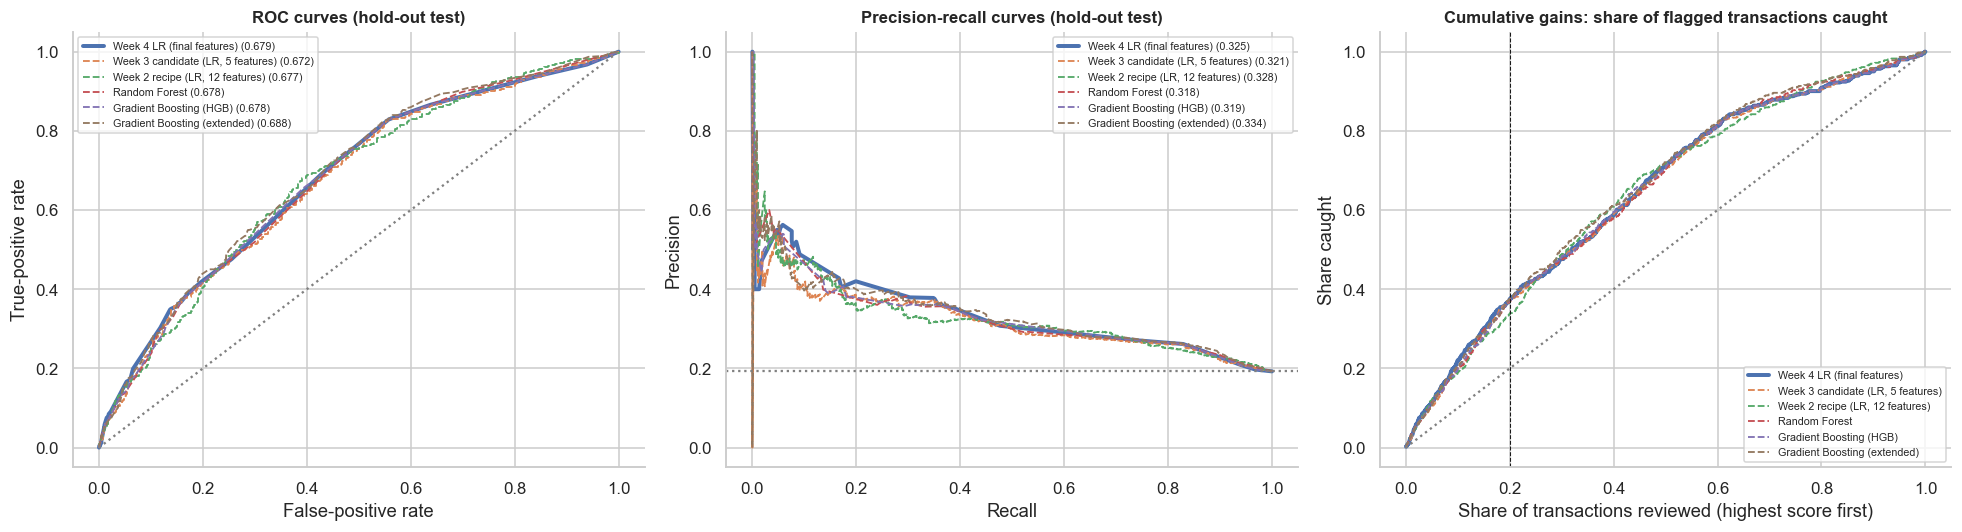

In [26]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5)); show = [FINAL_NAME, "Week 3 candidate (LR, 5 features)", "Week 2 recipe (LR, 12 features)", "Random Forest", "Gradient Boosting (HGB)", "Gradient Boosting (extended)"]
for n in show:
    p = HOLD[n]["p_te"]; ls = "-" if n == FINAL_NAME else "--"; lw = 2.6 if n == FINAL_NAME else 1.2
    f_, t_, _ = roc_curve(test.y, p); ax[0].plot(f_, t_, ls, lw=lw, label=f"{n} ({roc_auc_score(test.y, p):.3f})")
    pr_, rc_, _ = precision_recall_curve(test.y, p); ax[1].plot(rc_, pr_, ls, lw=lw, label=f"{n} ({average_precision_score(test.y, p):.3f})")
    o = np.argsort(-p, kind="stable"); g = np.cumsum(test.y.values[o]) / test.y.sum(); ax[2].plot(np.arange(1, len(g)+1)/len(g), g, ls, lw=lw, label=n)
ax[0].plot([0,1],[0,1],":",c="grey"); ax[0].set_title("ROC curves (hold-out test)"); ax[0].set_xlabel("False-positive rate"); ax[0].set_ylabel("True-positive rate"); ax[0].legend(fontsize=7)
ax[1].axhline(test.y.mean(), ls=":", c="grey"); ax[1].set_title("Precision-recall curves (hold-out test)"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend(fontsize=7)
ax[2].plot([0,1],[0,1],":",c="grey"); ax[2].axvline(.2, c="k", lw=.7, ls="--"); ax[2].set_title("Cumulative gains: share of flagged transactions caught"); ax[2].set_xlabel("Share of transactions reviewed (highest score first)"); ax[2].set_ylabel("Share caught"); ax[2].legend(fontsize=7)
savefig("B5_holdout_curves.png"); plt.show()

**Reading the hold-out.** The hold-out confirms the nested result. The final model scores ROC-AUC 0.679 [0.652, 0.705] with precision 0.357 and recall 0.368 at a 20% budget - the same as the Week 3 candidate (0.672; 0.360 / 0.366; paired ROC-AUC difference +0.007 [−0.003, +0.017], so 2,400 rows cannot separate them) and better than the Week 2 recipe at the same budget (0.327 / 0.331). Accuracy is 0.751, **below** the 0.808 of 'always No', so accuracy should not be quoted. In F1-optimal mode every model flags about 61% of transactions (recall 0.83, precision 0.26): a screening mode, not a practical default. A flexible model given every field reaches only 0.681 ROC-AUC, so the ceiling is a property of the data.

### 5.6 Choosing and documenting the review budget
There is no real stakeholder in this fictional bank, so the 20% budget is a **documented assumption**, not a requirement. The table reads off what a different budget would buy: the top b% of the test period by score is reviewed, with ties at the boundary broken at random (the model produces only a handful of distinct scores, so a plain threshold cannot hit every budget exactly).

,Precision,Recall,Lift vs random,"Per 1,000 transactions: reviewed",...of which truly flagged,...flagged transactions missed
Review budget,,,,,,
5%,0.458,0.119,2.381,50,23,170
10%,0.412,0.214,2.143,100,41,151
15%,0.383,0.299,1.991,150,58,135
20%,0.354,0.368,1.840,200,71,122
30%,0.308,0.481,1.602,300,92,100
40%,0.285,0.593,1.483,400,114,78
50%,0.276,0.716,1.433,500,138,55


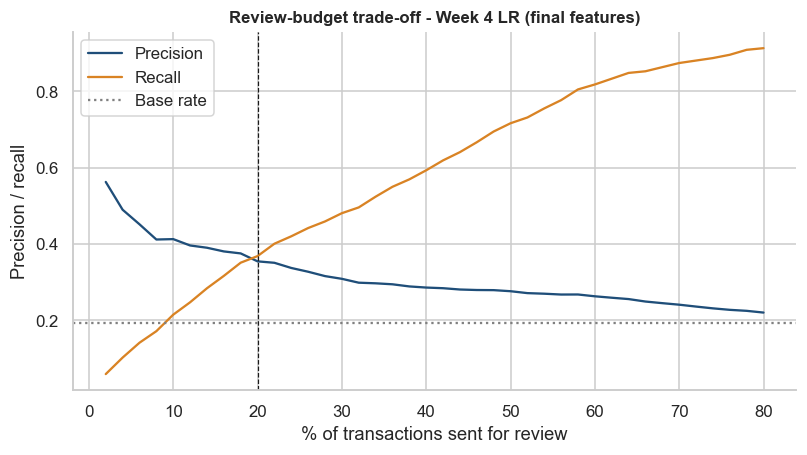

In [27]:
fin = HOLD[FINAL_NAME]; jt = _J[:len(test)]; yv = test.y.values; rows = []
for b in [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]:
    m = top_mask(fin["p_te"], b, jt); pr_, rc_ = yv[m].mean(), yv[m].sum() / yv.sum()
    rows.append({"Review budget": f"{b:.0%}", "Precision": pr_, "Recall": rc_, "Lift vs random": pr_ / yv.mean(),
                 "Per 1,000 transactions: reviewed": round(1000 * b), "...of which truly flagged": round(1000 * b * pr_), "...flagged transactions missed": round(1000 * yv.mean() * (1 - rc_))})
budget_tbl = pd.DataFrame(rows).set_index("Review budget"); display(budget_tbl.round(3))
fig, ax = plt.subplots(figsize=(7.5, 4.3)); bb = np.linspace(0.02, 0.8, 40); pr_c, rc_c = [], []
for b in bb:
    m = top_mask(fin["p_te"], b, jt); pr_c.append(yv[m].mean()); rc_c.append(yv[m].sum() / yv.sum())
ax.plot(bb*100, pr_c, c=NAVY, label="Precision"); ax.plot(bb*100, rc_c, c=ORANGE, label="Recall"); ax.axvline(20, c="k", ls="--", lw=.8); ax.axhline(test.y.mean(), c="grey", ls=":", label="Base rate")
ax.set_xlabel("% of transactions sent for review"); ax.set_ylabel("Precision / recall"); ax.set_title(f"Review-budget trade-off - {FINAL_NAME}"); ax.legend(); savefig("B6_review_budget.png"); plt.show()

### 5.7 Calibration - turning balanced-weight scores into honest probabilities
Week 3 flagged that scores were not calibrated. Balanced class weights make a model behave as if flags were common, so raw scores overstate the flag probability. A **Platt (sigmoid) layer is fitted on the validation period only** and judged on the test period. Ranking, thresholds and every metric above are unchanged - calibration only changes what the number *means*.

,Raw score,After Platt layer
Mean predicted,0.4739,0.2128
Observed flag rate,0.1925,0.1925
Brier score,0.2256,0.1449
ECE,0.2814,0.0209
ROC-AUC,0.6793,0.6793


Platt layer: probability = sigmoid(0.8398 * logit(score) + -1.3097)


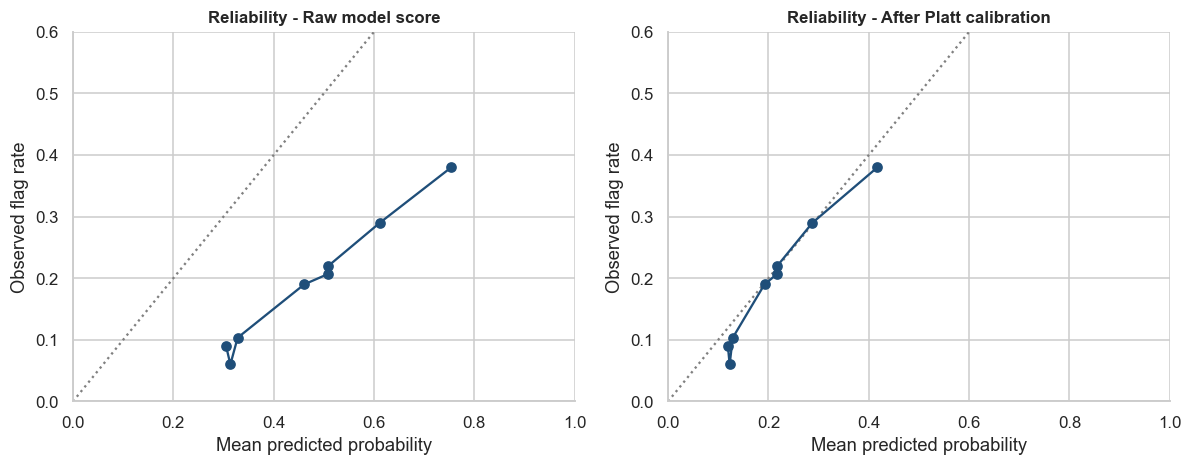

In [28]:
def logit(p): p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6); return np.log(p / (1 - p))
platt = LogisticRegression(C=1e6, max_iter=1000).fit(logit(fin["p_va"]).reshape(-1, 1), valid.y)
def calibrate(s): return platt.predict_proba(logit(s).reshape(-1, 1))[:, 1]
raw_te, cal_te = fin["p_te"], calibrate(fin["p_te"])
calib = pd.DataFrame({"Raw score": {"Mean predicted": raw_te.mean(), "Observed flag rate": test.y.mean(), "Brier score": brier_score_loss(test.y, raw_te), "ECE": ece_score(test.y, raw_te), "ROC-AUC": roc_auc_score(test.y, raw_te)},
                      "After Platt layer": {"Mean predicted": cal_te.mean(), "Observed flag rate": test.y.mean(), "Brier score": brier_score_loss(test.y, cal_te), "ECE": ece_score(test.y, cal_te), "ROC-AUC": roc_auc_score(test.y, cal_te)}})
display(calib.round(4))
print(f"Platt layer: probability = sigmoid({platt.coef_[0][0]:.4f} * logit(score) + {platt.intercept_[0]:.4f})")
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
for a_, s_, ttl in [(ax[0], raw_te, "Raw model score"), (ax[1], cal_te, "After Platt calibration")]:
    q = pd.qcut(pd.Series(s_).rank(method="first"), 8, labels=False); g = pd.DataFrame({"p": s_, "y": test.y.values, "q": q}).groupby("q").mean()
    a_.plot([0, 1], [0, 1], ":", c="grey"); a_.plot(g.p, g.y, "o-", c=NAVY); a_.set_xlim(0, 1); a_.set_ylim(0, 0.6); a_.set_xlabel("Mean predicted probability"); a_.set_ylabel("Observed flag rate"); a_.set_title(f"Reliability - {ttl}")
savefig("B7_calibration.png"); plt.show()

**Calibration result.** Raw scores averaged 0.47 against an observed flag rate of 0.19 (ECE 0.281). After the Platt layer the mean is 0.21, ECE falls to 0.021 and Brier from 0.226 to 0.145, with ROC-AUC unchanged. Calibrated values can be read as 'roughly x in 100 similar transactions are flagged' - still on synthetic data, and the model produces only a handful of distinct values.

# 6. Part C - Error analysis
The final model is analysed at its default operating point (flag the top-scoring ~20%) on the hold-out test period, and then re-checked on the **pooled nested out-of-time predictions** so that conclusions do not rest on one 2,400-row slice. Definitions: **TP** = flagged and the label is "Yes"; **FP** = flagged, label "No"; **FN** = not flagged, label "Yes"; **TN** = not flagged, label "No".

Week 4 LR (final features) | threshold 0.5681 | flags 19.8% of the 2400 test transactions
TN = 1632   FP = 306   FN = 292   TP = 170
precision = 0.357 | recall = 0.368 | false-positive rate = 0.158 | miss rate = 0.632 | share of flags that are false alarms = 64.3%

Pooled nested (n = 7200, top 20% per window): TN = 4834  FP = 922  FN = 926  TP = 518 | precision 0.360 | recall 0.359


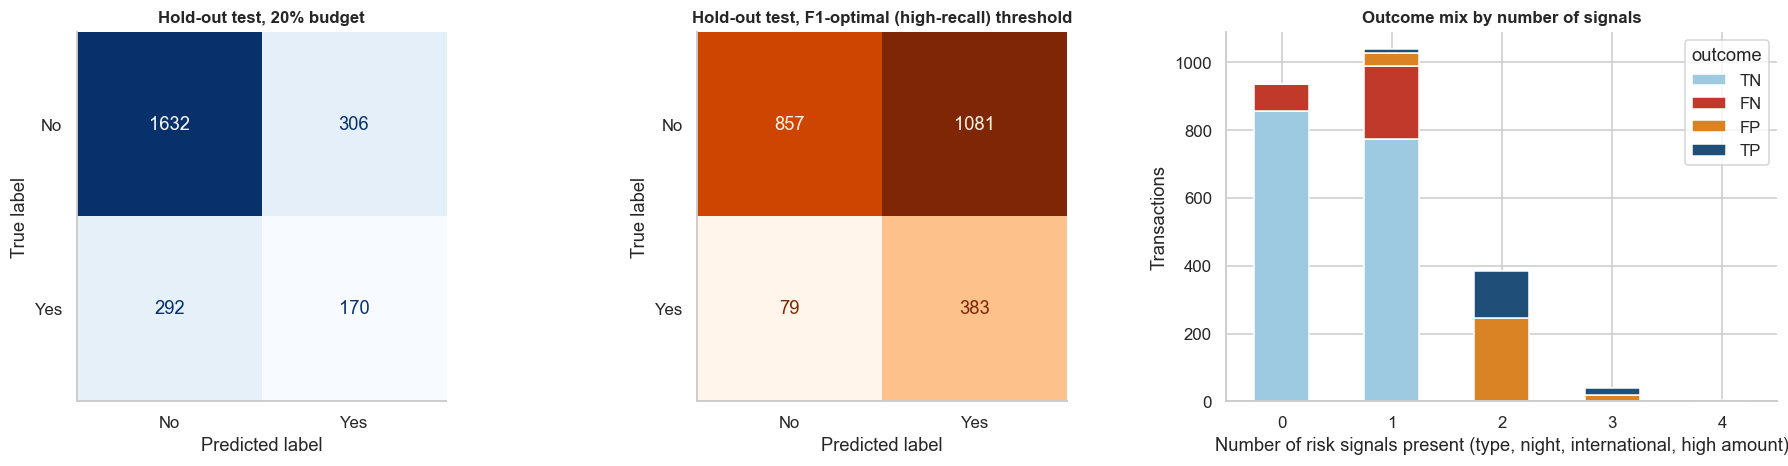

In [29]:
fin = HOLD[FINAL_NAME]; THR = fin["thr_cap"]
te = test.copy(); te["score"] = fin["p_te"]; te["p_cal"] = calibrate(fin["p_te"]); te["pred"] = (te.score >= THR).astype(int)
te["outcome"] = np.select([(te.y == 1) & (te.pred == 1), (te.y == 0) & (te.pred == 1), (te.y == 1) & (te.pred == 0)], ["TP", "FP", "FN"], "TN")
te["n_signals"] = te[["risky_type", "is_night", "is_international", "ha"]].sum(axis=1)
tn, fp, fn, tp = confusion_matrix(te.y, te.pred).ravel()
print(f"{FINAL_NAME} | threshold {THR:.4f} | flags {te.pred.mean():.1%} of the {len(te)} test transactions")
print(f"TN = {tn}   FP = {fp}   FN = {fn}   TP = {tp}")
print(f"precision = {tp/(tp+fp):.3f} | recall = {tp/(tp+fn):.3f} | false-positive rate = {fp/(fp+tn):.3f} | miss rate = {fn/(fn+tp):.3f} | share of flags that are false alarms = {fp/(fp+tp):.1%}")

# pooled out-of-time confusion matrix (5 windows, top 20% of each window)
sel, pooled_y = SEL_NEST[FINAL_NAME], Y_NEST
tn_n, fp_n, fn_n, tp_n = confusion_matrix(pooled_y, sel.astype(int)).ravel()
print(f"\nPooled nested (n = {len(pooled_y)}, top 20% per window): TN = {tn_n}  FP = {fp_n}  FN = {fn_n}  TP = {tp_n} | precision {tp_n/(tp_n+fp_n):.3f} | recall {tp_n/(tp_n+fn_n):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))
ConfusionMatrixDisplay(confusion_matrix(te.y, te.pred), display_labels=["No", "Yes"]).plot(ax=ax[0], cmap="Blues", colorbar=False); ax[0].set_title("Hold-out test, 20% budget"); ax[0].grid(False)
ConfusionMatrixDisplay.from_predictions(te.y, (fin["p_te"] >= fin["thr"]).astype(int), display_labels=["No", "Yes"], ax=ax[1], cmap="Oranges", colorbar=False); ax[1].set_title("Hold-out test, F1-optimal (high-recall) threshold"); ax[1].grid(False)
ct = te.groupby(["n_signals", "outcome"]).size().unstack(fill_value=0).reindex(columns=["TN", "FN", "FP", "TP"], fill_value=0)
ct.plot(kind="bar", stacked=True, ax=ax[2], color=[ "#9ecae1", RED, ORANGE, NAVY]); ax[2].set_xlabel("Number of risk signals present (type, night, international, high amount)"); ax[2].set_ylabel("Transactions"); ax[2].set_title("Outcome mix by number of signals"); ax[2].tick_params(axis="x", rotation=0)
savefig("C1_confusion_matrices.png"); plt.show()

### 6.2 What do the four outcome groups look like?

In [30]:
profile = te.groupby("outcome").agg(n=("y", "size"), night=("is_night", "mean"), international=("is_international", "mean"), high_amount=("ha", "mean"), transfer_or_cash=("risky_type", "mean"),
                                    median_amount_NGN=("Amount_NGN", "median"), mean_signals=("n_signals", "mean")).reindex(["TP", "FP", "FN", "TN"])
display(profile.round(3))
sig_tbl = te.groupby("n_signals").agg(n=("y", "size"), actual_flag_rate=("y", "mean"), model_flagged=("pred", "mean"), mean_calibrated_probability=("p_cal", "mean"))
sig_tbl["share_of_all_missed_flags"] = te[te.outcome == "FN"].groupby("n_signals").size().reindex(sig_tbl.index).fillna(0) / max((te.outcome == "FN").sum(), 1)
display(Markdown("**By number of risk signals** (night, international, high amount, Transfer/Cash Withdrawal):")); display(sig_tbl.round(3))

,n,night,international,high_amount,transfer_or_cash,median_amount_NGN,mean_signals
outcome,,,,,,,
TP,170,0.600,0.188,0.418,0.888,55689.875,2.094
FP,306,0.575,0.225,0.337,0.794,35220.385,1.931
FN,292,0.219,0.000,0.034,0.476,9043.870,0.729
TN,1632,0.158,0.000,0.016,0.301,8387.695,0.475


**By number of risk signals** (night, international, high amount, Transfer/Cash Withdrawal):

,n,actual_flag_rate,model_flagged,mean_calibrated_probability,share_of_all_missed_flags
n_signals,,,,,
0,936,0.084,0.000,0.124,0.271
1,1038,0.214,0.048,0.218,0.729
2,384,0.359,1.000,0.373,0.000
3,39,0.538,1.000,0.583,0.000
4,3,0.667,1.000,0.780,0.000


### 6.3 Where is the model right, and where does it struggle? (hold-out test, by segment)

,n,actual_flag_rate,precision,recall,false_pos_rate
Transaction_Type: Airtime/Data,240,0.138,0.429,0.091,0.019
Transaction_Type: Bill Payment,269,0.112,0.273,0.100,0.033
Transaction_Type: Card Purchase,621,0.113,0.237,0.129,0.053
Transaction_Type: Cash Withdrawal,295,0.275,0.418,0.506,0.266
Transaction_Type: Deposit,246,0.159,0.154,0.103,0.106
Transaction_Type: Transfer,729,0.287,0.372,0.526,0.358
international: 0,2299,0.187,0.368,0.321,0.127
international: 1,101,0.317,0.317,1.000,1.000
hour: 00-05,600,0.277,0.367,0.614,0.406
hour: 06-11,600,0.168,0.309,0.208,0.094


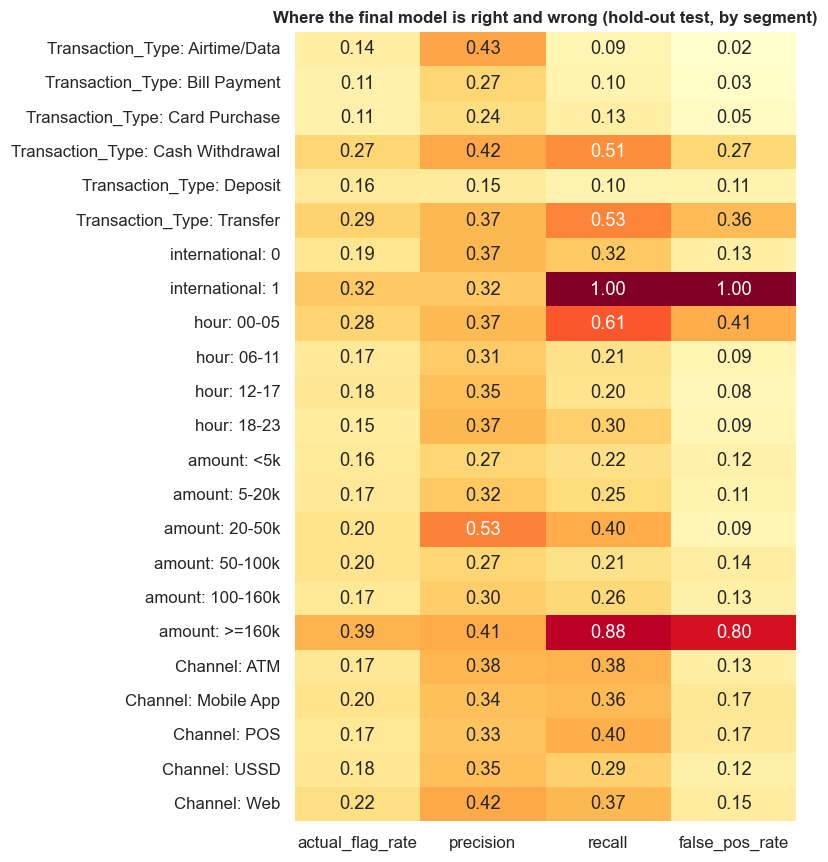

In [31]:
def seg_errors(df, col, label=None):
    g = df.groupby(col, observed=True)
    out = pd.DataFrame({"n": g.size(), "actual_flag_rate": g.y.mean(),
        "precision": g.apply(lambda x: (x.outcome == "TP").sum() / max((x.pred == 1).sum(), 1)),
        "recall": g.apply(lambda x: (x.outcome == "TP").sum() / max((x.y == 1).sum(), 1)),
        "false_pos_rate": g.apply(lambda x: (x.outcome == "FP").sum() / max((x.y == 0).sum(), 1))})
    out.index = [f"{label or col}: {i}" for i in out.index]; return out
te["amount_band"] = pd.cut(te.Amount_NGN, [0, 5_000, 20_000, 50_000, 100_000, 160_000, 1e9], labels=["<5k", "5-20k", "20-50k", "50-100k", "100-160k", ">=160k"])
te["hour_band"] = pd.cut(te.hour, [-1, 5, 11, 17, 23], labels=["00-05", "06-11", "12-17", "18-23"])
seg = pd.concat([seg_errors(te, "Transaction_Type"), seg_errors(te, "is_international", "international"), seg_errors(te, "hour_band", "hour"), seg_errors(te, "amount_band", "amount"), seg_errors(te, "Channel")])
display(seg.round(3))
fig, ax = plt.subplots(figsize=(7.5, 8)); sns.heatmap(seg[["actual_flag_rate", "precision", "recall", "false_pos_rate"]], annot=True, fmt=".2f", cmap="YlOrRd", ax=ax, cbar=False)
ax.set_title("Where the final model is right and wrong (hold-out test, by segment)"); savefig("C3_segment_errors.png"); plt.show()

**What the error analysis shows.**
1. **The model is effectively counting risk signals.** Test transactions with two or more signals are always flagged, with none never, with one signal 4.8%. All 292 false negatives have one signal or none (27% none).
2. **False negatives are 'quiet' transactions the features cannot explain.** Median amount ≈ NGN 9k (true positives ≈ NGN 56k). Yet the actual flag rate is 8.4% with zero signals and 21.4% with one - these labels look like irreducible noise in the target, and Section 6.4 shows a flexible model on every field does no better.
3. **False positives look almost identical to true positives** (night-time 58% vs 60%; Transfer/Cash 79% vs 89%). With two signals the true flag rate is only about 36%, so 306 of the 476 flagged transactions (64%) are false alarms - a precision ceiling near 0.36.
4. **By segment:** all international transactions and almost all amounts ≥ NGN 160k are flagged (recall 100% and 88%) but precision is only 32% and 41%; night-time recall is 61% against 20–30% in the day. Recall is only 9–13% for Airtime/Data, Bill Payment, Card Purchase and Deposit, which carry low risk.
5. **The same picture appears pooled out-of-time** (precision 0.360, recall 0.359, n = 7,200).

**Implication:** the remaining errors are a data limitation, not a model limitation, so more model complexity is unlikely to fix them.

### 6.4 Is the error floor a *model* problem or a *data* problem?
If a much more flexible model given **every** available field cannot do better, the remaining errors are a property of the data (the synthetic label), not of the chosen algorithm.

In [32]:
ceil_tbl = pd.DataFrame({"ROC-AUC": {FINAL_NAME + "  (4 inputs)": roc_auc_score(test.y, fin["p_te"]), **{k: v[0] for k, v in CEIL.items()}},
                         "PR-AUC":  {FINAL_NAME + "  (4 inputs)": average_precision_score(test.y, fin["p_te"]), **{k: v[1] for k, v in CEIL.items()}}})
display(ceil_tbl.round(3))
zero = te[te.n_signals == 0]; one = te[te.n_signals == 1]
print(f"Test transactions with NO risk signal: {len(zero)} -> actual flag rate {zero.y.mean():.1%} (these labels cannot be explained by any signal)")
print(f"Test transactions with ONE risk signal: {len(one)} -> actual flag rate {one.y.mean():.1%}; the model flags only {one.pred.mean():.1%} of them")
print(f"Share of all missed flags (FN) that have <= 1 signal: {(te[te.outcome=='FN'].n_signals <= 1).mean():.1%}")

,ROC-AUC,PR-AUC
Week 4 LR (final features) (4 inputs),0.679,0.325
"Flexible model, ALL deployable fields",0.680,0.335
"Flexible model, all fields + Transaction_Status",0.681,0.333


Test transactions with NO risk signal: 936 -> actual flag rate 8.4% (these labels cannot be explained by any signal)
Test transactions with ONE risk signal: 1038 -> actual flag rate 21.4%; the model flags only 4.8% of them
Share of all missed flags (FN) that have <= 1 signal: 100.0%


### 6.5 Subgroup consistency
Gender, segment, account type, income band and city are **not** model inputs. If the model still selects some groups much more often, it is doing so through correlated transaction behaviour. The test below asks whether selection rates differ more than chance would allow.

In [33]:
dn = data.iloc[NEST_IDX].copy(); dn["sel"] = SEL_NEST[FINAL_NAME].astype(int); dn["score"] = P_NEST[FINAL_NAME]; rows = []
for col in ["Gender", "Customer_Segment", "Account_Type", "Monthly_Income_Band", "City"]:
    ctab = pd.crosstab(dn[col], dn.sel); _, pval, _, _ = chi2_contingency(ctab)
    for lvl, g in dn.groupby(col):
        rows.append({"Group": f"{col}: {lvl}", "n": len(g), "actual_flag_rate": g.y.mean(), "selected_share": g.sel.mean(), "recall": g[(g.y == 1)].sel.mean(),
                     "precision": g[g.sel == 1].y.mean(), "ROC_AUC": roc_auc_score(g.y, g.score), "selection-independence p (whole attribute)": pval})
fair = pd.DataFrame(rows).set_index("Group"); display(fair.round(3))
FAIR_MIN_P = fair["selection-independence p (whole attribute)"].min()
print(f"Selection share range across ALL groups: {fair.selected_share.min():.3f} - {fair.selected_share.max():.3f} (overall 0.200). Smallest p-value across the five attributes = {FAIR_MIN_P:.3f}")

,n,actual_flag_rate,selected_share,recall,precision,ROC_AUC,selection-independence p (whole attribute)
Group,,,,,,,
Gender: Female,3516,0.201,0.202,0.345,0.342,0.670,0.877
Gender: Male,3455,0.200,0.198,0.372,0.375,0.675,0.877
Gender: Prefer not to say,229,0.210,0.192,0.375,0.409,0.735,0.877
Customer_Segment: Everyday,3401,0.200,0.198,0.376,0.381,0.684,0.600
Customer_Segment: Premium,1414,0.207,0.200,0.334,0.346,0.661,0.600
Customer_Segment: SME,1027,0.182,0.215,0.406,0.344,0.686,0.600
Customer_Segment: Student,1358,0.209,0.194,0.310,0.333,0.657,0.600
Account_Type: Current,1801,0.184,0.207,0.396,0.352,0.706,0.554
Account_Type: Premium,1085,0.208,0.190,0.367,0.403,0.702,0.554


Selection share range across ALL groups: 0.180 - 0.228 (overall 0.200). Smallest p-value across the five attributes = 0.444


**Subgroup reading.** Selection shares sit close to the overall 20% (about 0.18–0.23) across all groups, and the attribute-level selection-independence tests give p-values of 0.44 and above - no evidence that the model treats gender, segment, account type, income band or city groups differently. Per-group ROC-AUC varies mostly with group size (the smallest group has 229 transactions), so no conclusion should be drawn at that level.

# 7. Part D - Final model interpretation
Three views: (1) Logistic Regression coefficients as **odds ratios with bootstrap intervals** (the interpretable baseline, reported even if another model were selected), (2) **permutation importance** (how much PR-AUC is lost if a field is shuffled) for several model families, (3) a plain-language **risk-signal scorecard**.

**Logistic Regression** (C = 1; binary flags are un-scaled, so an odds ratio is *signal present vs absent*; Transaction_Type levels are relative to the average type; regularisation shrinks all values towards 1):

,coefficient (log-odds),odds ratio,OR 95% CI low,OR 95% CI high,flag rate when present (dev),flag rate when absent (dev)
is_international,1.206,3.340,2.423,4.261,0.383,0.189
high_amount,1.056,2.874,2.363,3.540,0.400,0.178
is_night,0.825,2.282,1.971,2.571,0.285,0.167
Transaction_Type_Transfer,0.486,1.626,1.468,1.803,0.284,0.160
Transaction_Type_Cash Withdrawal,0.336,1.399,1.190,1.623,0.248,0.190
Transaction_Type_Airtime/Data,-0.185,0.831,0.691,0.985,0.156,0.201
Transaction_Type_Card Purchase,-0.328,0.721,0.644,0.820,0.135,0.218
Transaction_Type_Bill Payment,-0.340,0.712,0.597,0.854,0.132,0.206
Transaction_Type_Deposit,-0.406,0.666,0.549,0.783,0.163,0.201


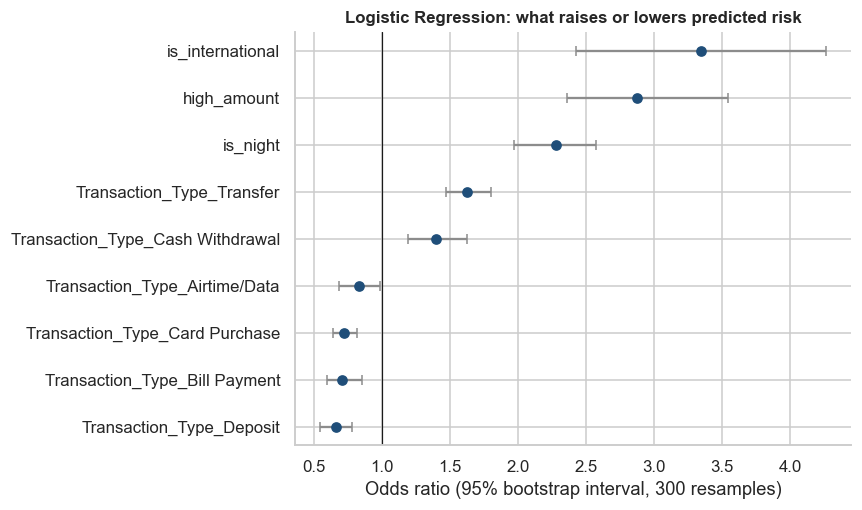

In [34]:
lr_pipe = HOLD[LR_NAME]["model"]; pre = lr_pipe.named_steps["pre"]
fnames = [n.replace("cat__", "").replace("bin__", "") for n in pre.get_feature_names_out()]; cols_lr = FEAT_CAT + FEAT_NUM
coefs = pd.Series(lr_pipe.named_steps["clf"].coef_[0], index=fnames)
rb = np.random.default_rng(SEED); boot_coefs = []
for _ in range(300):
    ix = rb.integers(0, len(train), len(train)); boot_coefs.append(clone(lr_pipe).fit(train.iloc[ix][cols_lr], train.y.iloc[ix]).named_steps["clf"].coef_[0])
boot_coefs = np.array(boot_coefs)
devf = data[data.split != "test"]
def emp_rate(name):
    if name.startswith("Transaction_Type_"): m = devf.Transaction_Type == name.replace("Transaction_Type_", ""); return devf[m].y.mean(), devf[~m].y.mean()
    col = {"high_amount": "ha"}.get(name, name); return devf[devf[col] == 1].y.mean(), devf[devf[col] == 0].y.mean()
or_tbl = pd.DataFrame({"coefficient (log-odds)": coefs, "odds ratio": np.exp(coefs), "OR 95% CI low": np.exp(np.percentile(boot_coefs, 2.5, axis=0)), "OR 95% CI high": np.exp(np.percentile(boot_coefs, 97.5, axis=0)),
                       "flag rate when present (dev)": [emp_rate(n)[0] for n in fnames], "flag rate when absent (dev)": [emp_rate(n)[1] for n in fnames]}).sort_values("coefficient (log-odds)", ascending=False)
display(Markdown(f"**Logistic Regression** (C = {HOLD[LR_NAME]['params'].get('C')}; binary flags are un-scaled, so an odds ratio is *signal present vs absent*; Transaction_Type levels are relative to the average type; regularisation shrinks all values towards 1):"))
display(or_tbl.round(3))
fig, ax = plt.subplots(figsize=(8, 4.8)); o = or_tbl.iloc[::-1]
ax.errorbar(o["odds ratio"], range(len(o)), xerr=[o["odds ratio"] - o["OR 95% CI low"], o["OR 95% CI high"] - o["odds ratio"]], fmt="o", color=NAVY, ecolor=GREY, capsize=3); ax.axvline(1, c="k", lw=.8)
ax.set_yticks(range(len(o))); ax.set_yticklabels(o.index); ax.set_xlabel("Odds ratio (95% bootstrap interval, 300 resamples)"); ax.set_title("Logistic Regression: what raises or lowers predicted risk"); savefig("D1_odds_ratios.png"); plt.show()

**Permutation importance** = mean drop in validation PR-AUC when the field is shuffled (30 repeats; higher = more important):

,Week 4 LR (final features),Random Forest,Gradient Boosting (HGB),average
high_amount,0.0464,0.0475,0.0480,0.0473
Transaction_Type,0.0361,0.0339,0.0364,0.0354
is_night,0.0214,0.0235,0.0218,0.0223
is_international,0.0202,0.0103,0.0193,0.0166


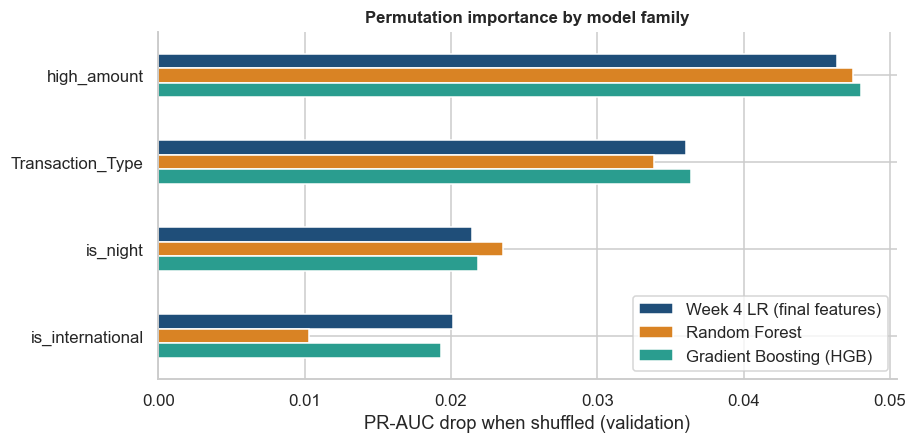

Decision-tree rules (first 3 levels) - a human-readable cross-check:

|--- Transaction_Type_Transfer <= 0.50
|   |--- is_night <= 0.50
|   |   |--- high_amount <= 0.50
|   |   |   |--- is_international <= 0.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- is_international >  0.50
|   |   |   |   |--- class: 1
|   |   |--- high_amount >  0.50
|   |   |   |--- Transaction_Type_Cash Withdrawal <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Transaction_Type_Cash Withdrawal >  0.50
|   |   |   |   |--- class: 1
|   |--- is_night >  0.50
|   |   |--- high_amount <= 0.50
|   |   |   |--- Transaction_Type_Card Purchase <= 0.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- Transaction_Type_Card Purchase >  0.50
|   |   |   |   |--- class: 1
|   |   |--- high_amount >  0.50
|   |   |   |--- class: 1
|--- Transaction_Type_Transfer >  0.50
|   |--- high_amount <= 0.50
|   |   |--- is_night <= 0.50
|   |   |   |--- is_international <= 0.50
|   |   |  

In [35]:
perm_models = {LR_NAME: HOLD[LR_NAME], "Random Forest": HOLD["Random Forest"], "Gradient Boosting (HGB)": HOLD["Gradient Boosting (HGB)"]}
perm = {}
for n, h in perm_models.items():
    sp = SPECS[n]; cols_ = sp["cat"] + sp["num"]
    pi = permutation_importance(h["model"], valid[cols_], valid.y, scoring="average_precision", n_repeats=30, random_state=SEED, n_jobs=1)
    perm[n] = pd.Series(pi.importances_mean, index=cols_)
perm = pd.DataFrame(perm); perm["average"] = perm.mean(axis=1); perm = perm.sort_values("average", ascending=False)
display(Markdown("**Permutation importance** = mean drop in validation PR-AUC when the field is shuffled (30 repeats; higher = more important):")); display(perm.round(4))
perm.drop(columns="average").plot(kind="barh", figsize=(8.5, 4.2), color=[NAVY, ORANGE, TEAL]); plt.gca().invert_yaxis(); plt.xlabel("PR-AUC drop when shuffled (validation)"); plt.title("Permutation importance by model family"); savefig("D2_permutation_importance.png"); plt.show()
dt_h = HOLD["Decision Tree"]; dt_names = [n.replace("cat__", "").replace("bin__", "") for n in dt_h["model"].named_steps["pre"].get_feature_names_out()]
print("Decision-tree rules (first 3 levels) - a human-readable cross-check:\n"); print(export_text(dt_h["model"].named_steps["clf"], feature_names=dt_names, max_depth=3))

**What drives the predictions.**
* **Direction and size (odds ratios, signal present vs absent, 95% bootstrap intervals):** international 3.34 [2.42, 4.26], high amount 2.87 [2.36, 3.54], night-time 2.28 [1.97, 2.57]. Transfer (1.63) and Cash Withdrawal (1.40) raise risk relative to the average type; Card Purchase (0.72), Bill Payment (0.71), Deposit (0.67) and Airtime/Data (0.83) lower it.
* **Importance (PR-AUC lost when shuffled):** high amount first (≈ 0.046–0.048), then transaction type (≈ 0.034–0.036), night-time (≈ 0.021–0.024) and international (≈ 0.010–0.020), consistently across Logistic Regression, Random Forest and Gradient Boosting.
* **Why international has the largest odds ratio but only ranks fourth:** only about 4% of transactions are international - odds-ratio size and predictive contribution are different things.
* **Consistent with Weeks 2–3:** amount, international, Transfer and Cash Withdrawal raise risk; night-time is a block, not a line.

### 7.3 Strengths, weaknesses and assumptions

In [36]:
fin_te = metric_row(test.y, fin["p_te"], THR)
sw = pd.DataFrame([
 ["Strength", "Fully explainable: four yes/no signals, each with a stated direction and an odds ratio whose interval excludes 1", "A risk analyst can see *why* a transaction was prioritised"],
 ["Strength", f"Stable over time: ROC-AUC {fold_auc.loc[FINAL_NAME,'mean']:.3f} +/- {fold_auc.loc[FINAL_NAME,'std']:.3f} across five rolling windows; the same amount cut-off is re-learned every time", "Behaves the same in each month of the window"],
 ["Strength", f"Useful for prioritisation: at a 20% budget it finds {fin_te['Recall@top20%']:.0%} of flagged transactions with lift {fin_te['Lift@top20%']:.2f}x (hold-out)", "Better than reviewing a random 20%"],
 ["Strength", "No look-ahead, no customer attributes, no identifiers, no Transaction_Status", "Deployable at decision time; avoids a fairness concern"],
 ["Weakness", f"Modest ceiling: ROC-AUC {roc_auc_score(test.y, fin['p_te']):.3f}; precision {fin_te['Precision@top20%']:.2f} means about two-thirds of flagged transactions are false alarms", "A prioritisation aid, never a decision-maker"],
 ["Weakness", "Cannot explain flags on 'quiet' transactions (no signal present) - they look like irreducible noise in the synthetic label", "More model complexity does not fix it (Sections 5 and 6.4)"],
 ["Weakness", "Only discrete signals: transactions with identical signals receive identical scores (ties)", "Review order inside a tie is arbitrary"],
 ["Assumption", "The flag pattern in Jan-Mar 2026 persists for the transactions being scored", "Three-month window - cannot be verified"],
 ["Assumption", f"Amount cut-off (NGN {HIGH_AMT_CUT:,.0f}), night window (00:00-05:59) and the 20% budget are fixed inputs", "Must be re-estimated if amounts or review capacity change"],
 ["Assumption", "Transaction type, amount, international status and time are known when the transaction is scored", "True for the fields used; status fields were deliberately excluded"],
 ["Assumption", "Risk_Review_Flag is a consistent synthetic label (rule-generated, possibly with noise)", "Associations only; no causal or fraud claim"],
], columns=["Type", "Statement", "Meaning / implication"])
display(sw.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

Type,Statement,Meaning / implication
Strength,"Fully explainable: four yes/no signals, each with a stated direction and an odds ratio whose interval excludes 1",A risk analyst can see *why* a transaction was prioritised
Strength,Stable over time: ROC-AUC 0.674 +/- 0.010 across five rolling windows; the same amount cut-off is re-learned every time,Behaves the same in each month of the window
Strength,Useful for prioritisation: at a 20% budget it finds 37% of flagged transactions with lift 1.84x (hold-out),Better than reviewing a random 20%
Strength,"No look-ahead, no customer attributes, no identifiers, no Transaction_Status",Deployable at decision time; avoids a fairness concern
Weakness,Modest ceiling: ROC-AUC 0.679; precision 0.35 means about two-thirds of flagged transactions are false alarms,"A prioritisation aid, never a decision-maker"
Weakness,Cannot explain flags on 'quiet' transactions (no signal present) - they look like irreducible noise in the synthetic label,More model complexity does not fix it (Sections 5 and 6.4)
Weakness,Only discrete signals: transactions with identical signals receive identical scores (ties),Review order inside a tie is arbitrary
Assumption,The flag pattern in Jan-Mar 2026 persists for the transactions being scored,Three-month window - cannot be verified
Assumption,"Amount cut-off (NGN 160,000), night window (00:00-05:59) and the 20% budget are fixed inputs",Must be re-estimated if amounts or review capacity change
Assumption,"Transaction type, amount, international status and time are known when the transaction is scored",True for the fields used; status fields were deliberately excluded


# 8. Part E - Data Analytics comparison (using the Data Analytics intern's actual outputs)
**DA finding → DS feature/model test → DS result → Comparison → Interpretation**

### 8.1 Reconciliation: DA-reported values vs the raw data

In [37]:
stat = data.Transaction_Status.value_counts(normalize=True) * 100
mon = data.groupby(data.Transaction_DateTime.dt.month).size()
typ_n = data.Transaction_Type.value_counts() / 1000
typ_val = data.groupby("Transaction_Type").Amount_NGN.sum() / 1000                     # NGN thousands
typ_risk = data.groupby("Transaction_Type").y.mean() * 100
dev_tbl = data.groupby("Device_Type").agg(risk=("y", "mean"), failed=("Transaction_Status", lambda s: (s == "Failed").mean()), n=("y", "size")); dev_tbl[["risk", "failed"]] *= 100
chn_val = data.groupby("Channel").Amount_NGN.sum() / 1000
ctab = pd.crosstab(data.Channel, data.Transaction_Status)
cv = cust.assign(v=data.groupby("Customer_ID").Amount_NGN.sum().reindex(cust.Customer_ID).fillna(0).values)
city_v, seg_v = cv.groupby("City").v.mean() / 1000, cv.groupby("Customer_Segment").v.mean() / 1000
top10 = data.groupby("Customer_ID").Amount_NGN.agg(["sum", "size"]).sort_values("sum", ascending=False).head(10)
pos_bill = data[(data.Channel == "POS") & (data.Transaction_Type == "Bill Payment")]
rec = []
def add(page, item, da, mine, tol): rec.append({"DA source": page, "Item": item, "DA reported": da, "Recomputed from raw data": round(float(mine), 4), "Match": "MATCH" if abs(float(da) - float(mine)) <= tol else "DIFFERENT"})
P1, P2, P3 = "Dashboard p1 (Executive Overview)", "Dashboard p2 (Customer & Transaction)", "Dashboard p3 (Risk Review & Reliability)"
add(P1, "Total customers", 1500, len(cust), 0); add(P1, "Total transactions", 12000, len(data), 0); add(P1, "Total transaction value (NGN M)", 560.5, data.Amount_NGN.sum() / 1e6, 0.06)
add(P1, "Average transaction value (NGN K)", 46.7, data.Amount_NGN.mean() / 1e3, 0.06); add(P1, "Transaction success rate (%)", 90.47, stat["Successful"], 0.006); add(P1, "Risk review rate (%)", 19.60, data.y.mean() * 100, 0.006)
for s_, v_ in {"Everyday": 711, "Premium": 295, "Student": 278, "SME": 216}.items(): add(P1, f"Customers in segment {s_}", v_, (cust.Customer_Segment == s_).sum(), 0)
for m_, n_, v_ in [(1, "January", 4133), (2, "February", 3734), (3, "March", 4133)]: add(P1, f"Transactions in {n_}", v_, mon[m_], 0)
for t_, v_ in {"Transfer": 3.5, "Card Purchase": 3.0, "Bill Payment": 1.5, "Cash Withdrawal": 1.4, "Deposit": 1.3, "Airtime/Data": 1.2}.items(): add(P1, f"Volume, {t_} (K)", v_, typ_n[t_], 0.05)
for c_, v_ in {"Mobile App": 240104.4, "POS": 104346.7, "Web": 89325.0, "ATM": 83942.4, "USSD": 42759.0}.items(): add(P1, f"Value by channel, {c_} (NGN K)", v_, chn_val[c_], 0.06)
for c_, (rv, pe) in {"Mobile App": (145, 82), "POS": (60, 34), "Web": (45, 38), "ATM": (47, 25), "USSD": (29, 9)}.items(): add(P1, f"{c_}: reversed / pending counts", rv + pe / 1000, ctab.loc[c_, "Reversed"] + ctab.loc[c_, "Pending"] / 1000, 1e-9)
for d_, (rk, fl) in {"ATM Terminal": (21.64, 4.88), "Web Browser": (20.11, 4.42), "Android": (19.95, 5.38), "POS Terminal": (18.78, 4.90), "iOS": (18.49, 5.75), "Unknown": (16.67, 6.25)}.items():
    add(P1, f"Device {d_}: risk review rate (%)", rk, dev_tbl.loc[d_, "risk"], 0.006); add(P1, f"Device {d_}: failed rate (%)", fl, dev_tbl.loc[d_, "failed"], 0.006)
add(P2, "Non-success rate (%)", 9.53, 100 - stat["Successful"], 0.006)
for c_, v_ in {"Lagos": 389.12, "Kano": 381.04, "Ibadan": 378.44, "Abuja": 374.81, "Port Harcourt": 371.55, "Enugu": 370.99}.items(): add(P2, f"Value per customer, {c_} (NGN K)", v_, city_v[c_], 0.006)
for s_, v_ in {"SME": 387.92, "Student": 386.60, "Everyday": 367.73, "Premium": 365.26}.items(): add(P2, f"Value per customer, {s_} (NGN K)", v_, seg_v[s_], 0.006)
for t_, v_ in {"Transfer": 237916.70, "Deposit": 130985.06, "Card Purchase": 85863.41, "Cash Withdrawal": 67772.36, "Bill Payment": 28163.65, "Airtime/Data": 9776.17}.items(): add(P2, f"Total value, {t_} (NGN K)", v_, typ_val[t_], 0.006)
add(P2, "Transfer share of total value (%)", 42, typ_val["Transfer"] / typ_val.sum() * 100, 0.5); add(P2, "Top-10 customers: total value (NGN)", 14742319.48, top10["sum"].sum(), 0.01)
add(P2, "Top-10 customers: transactions", 130, top10["size"].sum(), 0); add(P2, "Top-10 customers: share of total value (%)", 2.6, top10["sum"].sum() / data.Amount_NGN.sum() * 100, 0.06)
add(P3, "Failed rate (%)", 5.25, stat["Failed"], 0.006); add(P3, "Reversal rate (%)", 2.72, stat["Reversed"], 0.006); add(P3, "Flagged transactions", 2352, data.y.sum(), 0)
for t_, v_ in {"Transfer": 28.49, "Cash Withdrawal": 25.31, "Deposit": 16.19, "Airtime/Data": 15.19, "Card Purchase": 13.02, "Bill Payment": 12.81}.items(): add(P3, f"Risk review rate, {t_} (%)", v_, typ_risk[t_], 0.006)
add(P3, "Risk review rate, international (%)", 36.88, data[data.is_international == 1].y.mean() * 100, 0.006); add(P3, "Risk review rate, domestic (%)", 18.88, data[data.is_international == 0].y.mean() * 100, 0.006)
add(P3, "Failed rate, POS bill payments (%)", 7.22, (pos_bill.Transaction_Status == "Failed").mean() * 100, 0.006)
recon = pd.DataFrame(rec); n_match = int((recon.Match == "MATCH").sum())
display(recon.groupby("DA source").Match.agg(items="size", matched=lambda s: (s == "MATCH").sum()))
print(f"RECONCILED: {n_match} of {len(recon)} DA-reported values reproduce from the raw CSVs (within the precision printed on the dashboard).")
display(recon[recon.Match != "MATCH"] if n_match < len(recon) else pd.DataFrame({"Result": ["No differences found"]}))
recon.head(12)

,items,matched
DA source,,
Dashboard p1 (Executive Overview),41,41
Dashboard p2 (Customer & Transaction),21,21
Dashboard p3 (Risk Review & Reliability),12,12


RECONCILED: 74 of 74 DA-reported values reproduce from the raw CSVs (within the precision printed on the dashboard).


,Result
0,No differences found


,DA source,Item,DA reported,Recomputed from raw data,Match
0,Dashboard p1 (Executive Overview),Total customers,1500.00,1500.0000,MATCH
1,Dashboard p1 (Executive Overview),Total transactions,12000.00,12000.0000,MATCH
2,Dashboard p1 (Executive Overview),Total transaction value (NGN M),560.50,560.4774,MATCH
3,Dashboard p1 (Executive Overview),Average transaction value (NGN K),46.70,46.7064,MATCH
4,Dashboard p1 (Executive Overview),Transaction success rate (%),90.47,90.4667,MATCH
5,Dashboard p1 (Executive Overview),Risk review rate (%),19.60,19.6000,MATCH
6,Dashboard p1 (Executive Overview),Customers in segment Everyday,711.00,711.0000,MATCH
7,Dashboard p1 (Executive Overview),Customers in segment Premium,295.00,295.0000,MATCH
8,Dashboard p1 (Executive Overview),Customers in segment Student,278.00,278.0000,MATCH
9,Dashboard p1 (Executive Overview),Customers in segment SME,216.00,216.0000,MATCH


### 8.2 Descriptive findings used for the comparison, and KPI definitions shared with the model

In [38]:
def da_rates(col, df=data):
    g = df.groupby(col, observed=True).y.agg(["mean", "size"]); _, p, _, _ = chi2_contingency(pd.crosstab(df[col], df.y)); return g, p
g_type, p_type = da_rates("Transaction_Type"); g_int, p_int = da_rates("International_Transaction"); g_night, p_night = da_rates("is_night")
g_stat, p_stat = da_rates("Transaction_Status"); g_chan, p_chan = da_rates("Channel"); g_seg, p_seg = da_rates("Customer_Segment"); g_acc, p_acc = da_rates("Account_Type")
data["amount_vs_cut"] = np.where(data.Amount_NGN >= HIGH_AMT_CUT, "at/above cut-off", "below cut-off"); g_amt, p_amt = da_rates("amount_vs_cut")
data["engagement_band"] = pd.qcut(data.Digital_Engagement_Score, 3, labels=["low", "mid", "high"]); g_eng, p_eng = da_rates("engagement_band")
data["tenure_band"] = pd.qcut(data.Tenure_Months, 3, labels=["short", "mid", "long"]); g_ten, p_ten = da_rates("tenure_band")
known_dev = data[data.Device_Type != "Unknown"]; g_dev, p_dev = da_rates("Device_Type", known_dev)
mean_amt = data.groupby("Risk_Review_Flag").Amount_NGN.mean()
kpis = pd.DataFrame({"Value": {"Total transactions": len(data), "Overall flag rate (Risk_Review_Flag = Yes)": data.y.mean(), "International share": data.is_international.mean(),
    "Night-time share (00:00-05:59)": data.is_night.mean(), f"High-amount share (>= NGN {HIGH_AMT_CUT:,.0f})": data.ha.mean(), "Failed-status share": (data.Transaction_Status == "Failed").mean(),
    "Transfer + Cash Withdrawal share": data.risky_type.mean()}}); display(Markdown("**KPI definitions used by the model (flag rate, failed share and transaction counts equal the DA dashboard's values):**")); display(kpis.round(4))

**KPI definitions used by the model (flag rate, failed share and transaction counts equal the DA dashboard's values):**

,Value
Total transactions,12000.0000
Overall flag rate (Risk_Review_Flag = Yes),0.1960
International share,0.0400
Night-time share (00:00-05:59),0.2500
"High-amount share (>= NGN 160,000)",0.0845
Failed-status share,0.0525
Transfer + Cash Withdrawal share,0.4149


### 8.3 Checks prompted by the DA outputs
**(a) The DA script's Q14 asks whether the type effect is "really" an international effect.** Re-implemented in pandas (the result table was not included in what I received), then tested predictively with an explicit international × Transfer/Cash interaction (variant A11 in Section 4.3).
**(b) The DA monthly view says demand is steady (about 133 transactions a day in every month).** Does the *flag rate* stay steady too? That matters for a model trained on early months and applied to later ones.

In [39]:
q14 = data.groupby(["Transaction_Type", "is_international"]).y.agg(["mean", "size"]).unstack()
q14_tbl = pd.DataFrame({"Txns": data.groupby("Transaction_Type").size(), "Domestic flag %": q14[("mean", 0)] * 100, "International flag %": q14[("mean", 1)] * 100, "International txns": q14[("size", 1)]})
q14_tbl["Gap (percentage points)"] = q14_tbl["International flag %"] - q14_tbl["Domestic flag %"]; q14_tbl = q14_tbl.sort_values("Domestic flag %", ascending=False)
display(Markdown("**(a) Flag rate domestic vs international within each transaction type (DA SQL Q14 logic):**")); display(q14_tbl.round(1))
print(f"International transactions are flagged more than domestic in {int((q14_tbl['Gap (percentage points)'] > 0).sum())} of 6 types; smallest gap {q14_tbl['Gap (percentage points)'].min():.1f} pp, largest {q14_tbl['Gap (percentage points)'].max():.1f} pp.")
print("Predictive test (A11, add the interaction):", ex_ := EXP.loc[[i for i in EXP.index if i.startswith("A11")][0], "dROC-AUC vs V0 [95% CI]"])

mt = data.groupby(data.Transaction_DateTime.dt.month).agg(txns=("y", "size"), flag_rate=("y", "mean"), high_amount_share=("ha", "mean"), night_share=("is_night", "mean"), international_share=("is_international", "mean"))
mt["days"] = data.groupby(data.Transaction_DateTime.dt.month).Transaction_DateTime.apply(lambda s: s.dt.date.nunique()); mt["txns_per_day (DA Q12)"] = mt.txns / mt.days; mt.index = ["Jan", "Feb", "Mar"]
_, p_month, _, _ = chi2_contingency(pd.crosstab(data.Transaction_DateTime.dt.month, data.y))
display(Markdown("**(b) Volume per day (DA view) and flag rate by month (DS view):**")); display(mt.round(4)); print(f"Chi-square test: flag rate differs by month, p = {p_month:.2f}")

**(a) Flag rate domestic vs international within each transaction type (DA SQL Q14 logic):**

,Txns,Domestic flag %,International flag %,International txns,Gap (percentage points)
Transaction_Type,,,,,
Transfer,3549,27.9,42.0,150,14.1
Cash Withdrawal,1430,24.9,40.5,42,15.6
Deposit,1328,15.2,38.6,57,23.4
Airtime/Data,1185,14.4,32.0,50,17.6
Bill Payment,1475,12.3,26.8,56,14.5
Card Purchase,3033,12.1,35.2,125,23.1


International transactions are flagged more than domestic in 6 of 6 types; smallest gap 14.1 pp, largest 23.4 pp.
Predictive test (A11, add the interaction): +0.0004 [-0.0006, +0.0015]


**(b) Volume per day (DA view) and flag rate by month (DS view):**

,txns,flag_rate,high_amount_share,night_share,international_share,days,txns_per_day (DA Q12)
Jan,4133,0.1853,0.0854,0.2499,0.0390,31,133.3226
Feb,3734,0.2027,0.0806,0.2501,0.0378,28,133.3571
Mar,4133,0.2006,0.0871,0.2499,0.0431,31,133.3226


Chi-square test: flag rate differs by month, p = 0.10


### 8.4 Comparison table  (DA finding → DS test → DS result → Comparison → Interpretation)
Rows marked **DS-originated** are patterns the model found that do **not** appear in the DA outputs I received; they are listed as suggestions in Section 8.6.

DA finding (source),DS feature / model test,DS result,Comparison,Interpretation
"Dashboard p3: Risk review rate by transaction type - Transfer 28.49%, Cash Withdrawal 25.31%, Bill Payment 12.81%",Remove Transaction_Type from the final model; permutation importance,"dROC-AUC -0.0554 [-0.0688, -0.0426]; permutation importance 0.035",AGREE,The DA view and the predictive view agree: transaction type is a core driver
Dashboard p3: International 36.88% vs domestic 18.88% - 'flagged twice as often'; DA script Q11/Q14 ask whether this is a type effect,Remove is_international; add an international x Transfer/Cash interaction; permutation importance; domestic-vs-international within each type,"dROC-AUC -0.0077 [-0.0135, -0.0017]; interaction A11 +0.0004 [-0.0006, +0.0015]; international higher in 6 of 6 types (gaps 14-23 pp); permutation 0.017; only 4.0% of transactions are international",AGREE in direction; smaller predictive weight,The DA claim holds and is not a type effect in disguise. The largest rate gap is not the largest predictive contribution because it covers few transactions
"Dashboard p1: Risk review by device type - ATM terminals highest (21.64%), Unknown lowest (16.67%, n = 96)",Add channel + device to the final model; chi-square across the five known devices,"dROC-AUC -0.0014 [-0.0078, +0.0044]; device chi-square p = 0.16; channel p = 0.019","DIFFER: descriptive gap, no predictive gain","Device and channel gaps are within noise once type, amount, time and international are known; the 'Unknown' group is too small (96 rows) to read anything from"
"Dashboard p1: Monthly trend - demand steady, about 133 transactions a day in every month (Jan 4,133 / Feb 3,734 / Mar 4,133)",Flag rate by month (chi-square); rolling-window ROC-AUC range,Flag rate 18.5%-20.3% by month (p = 0.10); ROC-AUC 0.659-0.686 across five windows,AGREE (stable),"Neither volume nor flag rate drifts across the three months, which supports a chronological split; it says nothing about seasonality beyond Q1"
Dashboard p2: Segments are near-identical on value per customer (NGN 365K-388K); p1: segment sizes 711 / 295 / 278 / 216,Add demographics to the final model; demographics-only model; flag rate by segment,"dROC-AUC -0.0002 [-0.0059, +0.0050]; demographics-only ROC-AUC 0.501 (0.5 = chance); segment flag-rate p = 0.75",AGREE (no signal),"DA looked at value and DS at risk, but both find segments do not differ: customer attributes stay out of the model"
Dashboard p2: Top-10 customers generate only 2.6% of total value (NGN 14.74M of 560.5M),Flag rate of those customers' transactions; customer-grouped vs random cross-validation (Section 10.2),Top-10 customers' transactions flagged 27.7% (n = 130) vs 19.6% overall; grouped vs random CV ROC-AUC 0.676 vs 0.677,AGREE (no customer dependence),No customer concentration to model: the model does not rely on who the customer is. The top-10 sample (130 transactions) is too small to say more
"Dashboard p3 and p1: Failed rate 5.25%, reversal 2.72%, POS bill payments fail most (7.22%); non-success 9.53%",Add Transaction_Status to the final model (sensitivity),"dROC-AUC +0.0056 [+0.0015, +0.0096]; flag rate for Failed 27.0% vs 19.2% for Successful (p = 3.2e-05)",AGREE (signal real) - deliberately NOT adopted,"The DA reliability view and the risk view overlap: failed transactions are flagged more. Status is only known after processing, so the model excludes it (and the dashboard should not treat failure as a risk predictor)"
DS-ORIGINATED (not on any DA page): night-time (00:00-05:59) flag rate 28.4% vs 16.7%,Remove is_night; permutation importance,"dROC-AUC -0.0280 [-0.0383, -0.0184]; permutation importance 0.022",shared with DA,"A strong, stable signal the dashboard does not show (suggestion S1, Section 8.6)"
"DS-ORIGINATED (not on any DA page): flag rate 17.7% below vs 39.7% at/above NGN 160,000; flagged transactions average NGN 68,786 vs 41,324",Remove the high-amount flag; add continuous log_amount,"Remove: dROC-AUC -0.0197

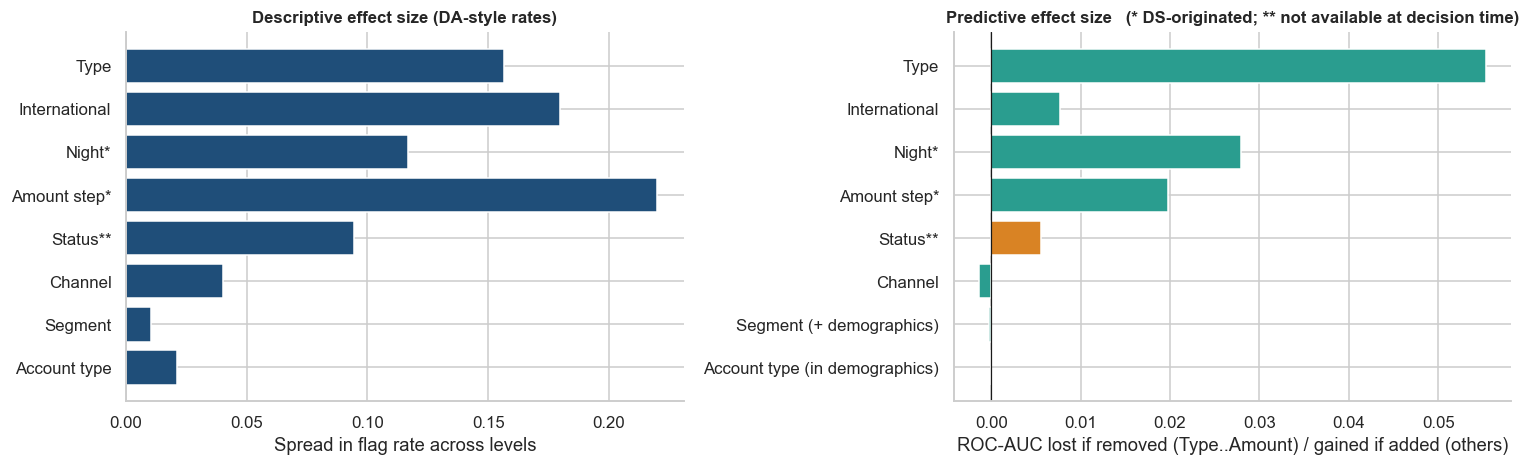

In [42]:
demog_cat, demog_num = ["Customer_Segment", "Account_Type", "City", "Gender", "Monthly_Income_Band", "Preferred_Channel"], ["Age", "Tenure_Months", "Digital_Engagement_Score"]
AUC_DEMOG = roc_auc_score(Y_NEST, nested_lr(demog_cat, demog_num, C_=0.1))
def ex(k): r = EXP.loc[[i for i in EXP.index if i.startswith(k)][0]]; return r["dROC-AUC vs V0 [95% CI]"], r["_lo"], r["_hi"]
pm = perm["average"]; pm_share = lambda c: f"{pm[c]:.3f}"
def spread(g): return g["mean"].max() - g["mean"].min()
top10_ids = top10.index; t10 = data[data.Customer_ID.isin(top10_ids)]
rows = []
r1, lo, hi = ex("R1"); rows.append(["Dashboard p3: Risk review rate by transaction type - Transfer 28.49%, Cash Withdrawal 25.31%, Bill Payment 12.81%",
  "Remove Transaction_Type from the final model; permutation importance", f"dROC-AUC {r1}; permutation importance {pm_share('Transaction_Type')}", "AGREE" if hi < 0 else "DIFFER", "The DA view and the predictive view agree: transaction type is a core driver"])
r3, lo, hi = ex("R3"); a11, lo11, hi11 = ex("A11"); rows.append([f"Dashboard p3: International {g_int.loc['Yes','mean']:.2%} vs domestic {g_int.loc['No','mean']:.2%} - 'flagged twice as often'; DA script Q11/Q14 ask whether this is a type effect",
  "Remove is_international; add an international x Transfer/Cash interaction; permutation importance; domestic-vs-international within each type", f"dROC-AUC {r3}; interaction A11 {a11}; international higher in {int((q14_tbl['Gap (percentage points)'] > 0).sum())} of 6 types (gaps {q14_tbl['Gap (percentage points)'].min():.0f}-{q14_tbl['Gap (percentage points)'].max():.0f} pp); permutation {pm_share('is_international')}; only {data.is_international.mean():.1%} of transactions are international", "AGREE in direction; smaller predictive weight" if hi < 0 else "DIFFER", "The DA claim holds and is not a type effect in disguise. The largest rate gap is not the largest predictive contribution because it covers few transactions"])
a4, alo, ahi = ex("A4"); rows.append([f"Dashboard p1: Risk review by device type - ATM terminals highest ({dev_tbl.loc['ATM Terminal','risk']:.2f}%), Unknown lowest ({dev_tbl.loc['Unknown','risk']:.2f}%, n = {int(dev_tbl.loc['Unknown','n'])})",
  "Add channel + device to the final model; chi-square across the five known devices", f"dROC-AUC {a4}; device chi-square p = {p_dev:.2f}; channel p = {p_chan:.3f}", "DIFFER: descriptive gap, no predictive gain" if alo <= 0 else "AGREE", "Device and channel gaps are within noise once type, amount, time and international are known; the 'Unknown' group is too small (96 rows) to read anything from"])
rows.append([f"Dashboard p1: Monthly trend - demand steady, about {mt['txns_per_day (DA Q12)'].mean():.0f} transactions a day in every month (Jan 4,133 / Feb 3,734 / Mar 4,133)",
  "Flag rate by month (chi-square); rolling-window ROC-AUC range", f"Flag rate {mt.flag_rate.min():.1%}-{mt.flag_rate.max():.1%} by month (p = {p_month:.2f}); ROC-AUC {fold_auc.loc[FINAL_NAME].iloc[:5].min():.3f}-{fold_auc.loc[FINAL_NAME].iloc[:5].max():.3f} across five windows", "AGREE (stable)" if p_month > 0.05 else "DIFFER", "Neither volume nor flag rate drifts across the three months, which supports a chronological split; it says nothing about seasonality beyond Q1"])
a6, alo, ahi = ex("A6"); rows.append([f"Dashboard p2: Segments are near-identical on value per customer (NGN {seg_v.min():,.0f}K-{seg_v.max():,.0f}K); p1: segment sizes 711 / 295 / 278 / 216",
  "Add demographics to the final model; demographics-only model; flag rate by segment", f"dROC-AUC {a6}; demographics-only ROC-AUC {AUC_DEMOG:.3f} (0.5 = chance); segment flag-rate p = {p_seg:.2f}", "AGREE (no signal)" if alo <= 0 else "DIFFER", "DA looked at value and DS at risk, but both find segments do not differ: customer attributes stay out of the model"])
rows.append([f"Dashboard p2: Top-10 customers generate only {top10['sum'].sum()/data.Amount_NGN.sum():.1%} of total value (NGN 14.74M of 560.5M)",
  "Flag rate of those customers' transactions; customer-grouped vs random cross-validation (Section 10.2)", f"Top-10 customers' transactions flagged {t10.y.mean():.1%} (n = {len(t10)}) vs {data.y.mean():.1%} overall; grouped vs random CV ROC-AUC 0.676 vs 0.677", "AGREE (no customer dependence)", "No customer concentration to model: the model does not rely on who the customer is. The top-10 sample (130 transactions) is too small to say more"])
a9, alo, ahi = ex("A9"); rows.append([f"Dashboard p3 and p1: Failed rate 5.25%, reversal 2.72%, POS bill payments fail most (7.22%); non-success 9.53%",
  "Add Transaction_Status to the final model (sensitivity)", f"dROC-AUC {a9}; flag rate for Failed {g_stat.loc['Failed','mean']:.1%} vs {g_stat.loc['Successful','mean']:.1%} for Successful (p = {p_stat:.1e})", "AGREE (signal real) - deliberately NOT adopted" if alo > 0 else "DIFFER", "The DA reliability view and the risk view overlap: failed transactions are flagged more. Status is only known after processing, so the model excludes it (and the dashboard should not treat failure as a risk predictor)"])
r4, lo, hi = ex("R4"); rows.append([f"DS-ORIGINATED (not on any DA page): night-time (00:00-05:59) flag rate {g_night.loc[1,'mean']:.1%} vs {g_night.loc[0,'mean']:.1%}",
  "Remove is_night; permutation importance", f"dROC-AUC {r4}; permutation importance {pm_share('is_night')}", "shared with DA", "A strong, stable signal the dashboard does not show (suggestion S1, Section 8.6)"])
r2, lo, hi = ex("R2"); a1, alo, ahi = ex("A1"); rows.append([f"DS-ORIGINATED (not on any DA page): flag rate {g_amt.loc['below cut-off','mean']:.1%} below vs {g_amt.loc['at/above cut-off','mean']:.1%} at/above NGN {HIGH_AMT_CUT:,.0f}; flagged transactions average NGN {mean_amt['Yes']:,.0f} vs {mean_amt['No']:,.0f}",
  "Remove the high-amount flag; add continuous log_amount", f"Remove: dROC-AUC {r2}; add log_amount: {a1}; permutation importance {pm_share('high_amount')}", "shared with DA", "The effect is a step near NGN 160k, not a smooth gradient: a risk-by-amount-band view would show it (suggestion S2)"])
da_tbl = pd.DataFrame(rows, columns=["DA finding (source)", "DS feature / model test", "DS result", "Comparison", "Interpretation"])
display(da_tbl.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.4)); labs = ["Type", "International", "Night*", "Amount step*", "Status**", "Channel", "Segment", "Account type"]
da_sp = [spread(g_type), spread(g_int), spread(g_night), spread(g_amt), spread(g_stat), spread(g_chan), spread(g_seg), spread(g_acc)]
ax[0].barh(labs[::-1], da_sp[::-1], color=NAVY); ax[0].set_xlabel("Spread in flag rate across levels"); ax[0].set_title("Descriptive effect size (DA-style rates)")
ds_eff = [-EXP.loc[[i for i in EXP.index if i.startswith(k)][0], "_da"] for k in ["R1", "R3", "R4", "R2"]] + [EXP.loc[[i for i in EXP.index if i.startswith(k)][0], "_da"] for k in ["A9", "A4", "A6"]] + [0.0]
ds_labs = labs[:4] + ["Status**", "Channel", "Segment (+ demographics)", "Account type (in demographics)"]
ax[1].barh(ds_labs[::-1], ds_eff[::-1], color=[ORANGE if "Status" in l else TEAL for l in ds_labs[::-1]]); ax[1].axvline(0, c="k", lw=.8); ax[1].set_xlabel("ROC-AUC lost if removed (Type..Amount) / gained if added (others)"); ax[1].set_title("Predictive effect size   (* DS-originated; ** not available at decision time)")
savefig("E5_da_vs_ds.png"); plt.show()

**Reading the comparison.** The DA intern's numbers are accurate: every value I could check reproduces from the raw data. Where the DA findings and the predictive tests overlap (transaction type, international) they **agree**, and the DS tests say how much each matters. Four points stand out:
* **International is not a type effect in disguise.** The DA script asks the right question (Q14). International transactions are flagged more in all six types, and an explicit interaction adds nothing (see A11), so the international signal stands on its own.
* **The biggest rate gap is not the biggest predictive contribution** (international covers only about 4% of transactions).
* **Descriptive gaps that do not predict:** device and channel (the dashboard's ATM-highest finding) add no predictive value once the four core signals are known. Failure is the opposite case: a real predictive signal (+0.006 ROC-AUC) that cannot be used because it is only known after processing.
* **Stability and concentration agree with the DA view:** volume and flag rate are flat across the three months, and the top-10 customers hold only 2.6% of value, so the model has no customer dependence.

Two of the strongest drivers (night-time and the NGN 160k amount step) do not appear on any DA dashboard; they are offered back in Section 8.6. **Limits:** DA and DS use the same label, so agreement is not independent confirmation of real risk.

### 8.5 Cross-track use of outputs (Week 4 integration requirement): Output received → How used → What changed → Evidence

In [44]:
use = pd.DataFrame([
 ["Data Analytics intern: Power BI dashboard", "(1) Every printed value was reproduced from the raw CSVs. (2) Its findings form the DA side of the comparison in Section 8.4",
  f"Nothing in the model. Part E now rests on the DA intern's actual findings instead of ones I computed myself; {n_match}/{len(recon)} DA values reconciled", "Sections 8.1 and 8.4"],
 ["Data Analytics intern: SQL results", "Q11/Q14 (international vs domestic, by type) and Q12 (monthly volume); the validation block's expected values (1,500 customers, 12,000 transactions, ~560.5M, 90.47%, 19.60%) checked",
  "Two new DS tests were added because of it: the international x type interaction (A11) and flag-rate-by-month stability. Neither changed the final features or model", "Sections 4.3 (variant A11) and 8.3"],
], columns=["Output received", "How it was used", "What changed", "Evidence of use"])
display(use.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

Output received,How it was used,What changed,Evidence of use
Data Analytics intern: Power BI dashboard,(1) Every printed value was reproduced from the raw CSVs. (2) Its findings form the DA side of the comparison in Section 8.4,Nothing in the model. Part E now rests on the DA intern's actual findings instead of ones I computed myself; 74/74 DA values reconciled,Sections 8.1 and 8.4
Data Analytics intern: SQL results,"Q11/Q14 (international vs domestic, by type) and Q12 (monthly volume); the validation block's expected values (1,500 customers, 12,000 transactions, ~560.5M, 90.47%, 19.60%) checked",Two new DS tests were added because of it: the international x type interaction (A11) and flag-rate-by-month stability. Neither changed the final features or model,Sections 4.3 (variant A11) and 8.3


### 8.6 Suggestions I can offer back to the Data Analytics intern
| # | Suggestion | Why (evidence from this notebook) |
|---|---|---|
| S1 | Add a risk-review-rate view by **time of day** (e.g. 00:00–05:59 vs other) | Night-time is the second strongest controllable signal (flag rate ≈ 28% vs 17%); it is not on any dashboard page |
| S2 | Add a risk-review-rate view by **amount band**, with a marker at NGN 160,000 | Flag rate jumps from ≈ 18% to ≈ 40% at that point; averages hide the step |
| S3 | Reword the device caption on page 1 (*"Mobile devices fail most"*) to note that the highest failed rate belongs to "Unknown" (6.25%, n = 96) | Small-n category; avoids over-reading |
| S4 | Set the page-3 gauge maximum to 12,000 (all transactions) instead of 4,704 | The current maximum (twice the flagged count) makes the 19.6% share look like 50% |
| S5 | On page 2, soften "gaps between cities are modest" or show Benin City (≈ NGN 310K vs 389K for Lagos, about 20% lower) | Only the top six cities are visible, so the lowest are hidden |

# 9. Part F - Final model documentation
### 9.1 Final model at a glance  (dataset → features → model → selection → evaluation)

In [45]:
assert FINAL_SPEC["cat"] == FEAT_CAT and FINAL_SPEC["num"] == FEAT_NUM, "Final model uses extended inputs: the raw-record scoring section below must be adapted"
cols_f = FINAL_SPEC["cat"] + FINAL_SPEC["num"]; final_model = fin["model"]
hold_cap = metric_row(test.y, fin["p_te"], fin["thr_cap"]); hold_f1 = metric_row(test.y, fin["p_te"], fin["thr"])
nest_final = {"ROC-AUC": ci(BS[FINAL_NAME][:, 0]), "PR-AUC": ci(BS[FINAL_NAME][:, 1]), "Precision@20%": ci(BS[FINAL_NAME][:, 2]), "Recall@20%": ci(BS[FINAL_NAME][:, 3])}
glance = pd.DataFrame([
 ["Final modelling dataset", f"`data/processed/FinTrust_Modelling_Dataset_Final.csv` - {len(final_ds):,} transactions (1 Jan - 31 Mar 2026), chronological split train {len(train):,} / validation {len(valid):,} / test {len(test):,}"],
 ["Final feature set", f"{len(FEATURES)} inputs: Transaction_Type (6 levels), high_amount (Amount_NGN >= NGN {HIGH_AMT_CUT:,.0f}), is_international, is_night (00:00-05:59)"],
 ["Final model", f"{FINAL_NAME}: balanced class weights, tuned {fin['params']}, followed by a Platt calibration layer"],
 ["Model-selection reasoning", "Pre-stated burden-of-proof rule on 7,200 nested out-of-time predictions: no challenger beat Logistic Regression on both ROC-AUC and PR-AUC" if FINAL_NAME == LR_NAME else f"Pre-stated burden-of-proof rule selected {FINAL_NAME}"],
 ["Evaluation - nested rolling-origin (n = 7,200)", "; ".join(f"{k} {v}" for k, v in nest_final.items())],
 ["Evaluation - hold-out test, 20% budget", f"Accuracy {hold_cap['Accuracy']:.3f} | precision {hold_cap['Precision']:.3f} | recall {hold_cap['Recall']:.3f} | F1 {hold_cap['F1']:.3f} | ROC-AUC {hold_cap['ROC_AUC']:.3f} | PR-AUC {hold_cap['PR_AUC']:.3f} | lift {hold_cap['Lift@top20%']:.2f}x"],
 ["Evaluation - hold-out test, F1-optimal mode", f"Accuracy {hold_f1['Accuracy']:.3f} | precision {hold_f1['Precision']:.3f} | recall {hold_f1['Recall']:.3f} | F1 {hold_f1['F1']:.3f} (flags {hold_f1['Flagged_share']:.0%} of transactions)"],
 ["Confusion matrix (hold-out, 20% budget)", f"TN {tn} | FP {fp} | FN {fn} | TP {tp}"],
 ["Calibration", f"Brier {calib.loc['Brier score','Raw score']:.3f} -> {calib.loc['Brier score','After Platt layer']:.3f}; ECE {calib.loc['ECE','Raw score']:.3f} -> {calib.loc['ECE','After Platt layer']:.3f}"],
], columns=["Item", "Final value"])
display(glance.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

Item,Final value
Final modelling dataset,"`data/processed/FinTrust_Modelling_Dataset_Final.csv` - 12,000 transactions (1 Jan - 31 Mar 2026), chronological split train 7,200 / validation 2,400 / test 2,400"
Final feature set,"4 inputs: Transaction_Type (6 levels), high_amount (Amount_NGN >= NGN 160,000), is_international, is_night (00:00-05:59)"
Final model,"Week 4 LR (final features): balanced class weights, tuned {'C': 1}, followed by a Platt calibration layer"
Model-selection reasoning,"Pre-stated burden-of-proof rule on 7,200 nested out-of-time predictions: no challenger beat Logistic Regression on both ROC-AUC and PR-AUC"
"Evaluation - nested rolling-origin (n = 7,200)","ROC-AUC 0.674 [0.658, 0.688]; PR-AUC 0.339 [0.315, 0.359]; Precision@20% 0.359 [0.335, 0.382]; Recall@20% 0.359 [0.336, 0.383]"
"Evaluation - hold-out test, 20% budget",Accuracy 0.751 | precision 0.357 | recall 0.368 | F1 0.362 | ROC-AUC 0.679 | PR-AUC 0.325 | lift 1.84x
"Evaluation - hold-out test, F1-optimal mode",Accuracy 0.517 | precision 0.262 | recall 0.829 | F1 0.398 (flags 61% of transactions)
"Confusion matrix (hold-out, 20% budget)",TN 1632 | FP 306 | FN 292 | TP 170
Calibration,Brier 0.226 -> 0.145; ECE 0.281 -> 0.021


### 9.2 Saved model card

In [46]:
joblib.dump(final_model, MODELS/"final_model.joblib"); joblib.dump(platt, MODELS/"final_calibrator.joblib")
KNOWN_TYPES = sorted(final_model.named_steps["pre"].named_transformers_["cat"].categories_[0])
card = {
 "model_name": "FinTrust Risk-Review Prioritisation Model (Week 4 final)", "model_type": FINAL_NAME, "status": "Educational prototype on synthetic data - NOT a production banking system",
 "target": "Risk_Review_Flag = Yes (synthetic educational label; NOT a fraud or financial-crime determination)",
 "intended_use": "Rank transactions so that a limited manual-review budget is spent on the most likely flagged ones (decision support only)",
 "not_intended_for": ["fraud determination", "automated blocking or declining of transactions", "decisions about individual customers", "use on real banking data without re-validation"],
 "selection_rule": "More complex model replaces Logistic Regression only if paired-bootstrap 95% CI of the gain is above 0 on both ROC-AUC and PR-AUC (nested rolling-origin, n=7200)",
 "features": {"categorical": FEAT_CAT, "binary": FEAT_NUM, "definitions": {"high_amount": f"Amount_NGN >= {HIGH_AMT_CUT:.0f} (learned on the training window by cut-off scan)", "is_international": "International_Transaction == 'Yes'", "is_night": "hour of Transaction_DateTime between 0 and 5 inclusive", "Transaction_Type": f"one of {KNOWN_TYPES}"}},
 "excluded_on_purpose": ["Transaction_Status (may not be known at decision time)", "Account_Status", "customer attributes (no signal; fairness)", "Customer_Name and IDs", "look-ahead customer counts"],
 "hyperparameters": fin["params"], "preprocessing": "OneHotEncoder(handle_unknown='ignore') for Transaction_Type; binary flags passed through; class_weight='balanced'",
 "operating_points": {"budget_20pct": {"raw_score_threshold": fin["thr_cap"], "chosen_on": "80th percentile of validation scores"}, "f1_optimal_high_recall": {"raw_score_threshold": fin["thr"], "chosen_on": "validation F1"}},
 "calibration": {"method": "Platt (sigmoid) on logit(raw score), fitted on validation period", "coef": float(platt.coef_[0][0]), "intercept": float(platt.intercept_[0])},
 "split": {"type": "chronological 60/20/20", "train_to": str(train.Transaction_DateTime.max()), "validation_to": str(valid.Transaction_DateTime.max()), "test_to": str(test.Transaction_DateTime.max())},
 "metrics_holdout_budget20": {k: round(float(v), 4) for k, v in hold_cap.items()}, "metrics_holdout_f1_optimal": {k: round(float(v), 4) for k, v in hold_f1.items()},
 "metrics_nested_rolling_origin": nest_final, "confusion_matrix_holdout_budget20": {"TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)},
 "input_contract": {"required_columns": ["Transaction_Type", "Amount_NGN", "International_Transaction", "Transaction_DateTime"], "rules": {"Transaction_Type": f"must be one of {KNOWN_TYPES}", "Amount_NGN": "numeric and > 0", "International_Transaction": "'Yes' or 'No'", "Transaction_DateTime": "parseable timestamp"}, "invalid_records": "rejected and routed to manual check - never silently scored"},
 "output_contract": ["status", "reason", "n_signals", "risk_score", "flag_probability", "review_flag", "needs_manual_check"],
 "limitations": ["Synthetic target; associations only", "Three-month window; no seasonality or drift assessment", "Modest ceiling (ROC-AUC ~0.67): about two-thirds of flagged transactions are false alarms at a 20% budget", "Scores tie (few distinct profiles)", "High-amount cut-off and review budget are assumptions to re-estimate", "Test period viewed in Week 3 and Week 4 (confirmation only)"],
 "cross_track": {"data_analytics": "dashboard (3 pages, screenshots) and SQL script received; values reconciled to raw data; used for comparison only; model unchanged", "ml_engineering": "not received", "generative_ai": "not received"},
 "seed": SEED, "versions": {"python": platform.python_version(), "scikit-learn": sklearn.__version__, "pandas": pd.__version__, "numpy": np.__version__},
}
json.dump(card, open(MODELS/"final_model_card.json", "w"), indent=2, default=str)
reloaded, rel_cal = joblib.load(MODELS/"final_model.joblib"), joblib.load(MODELS/"final_calibrator.joblib")
assert np.allclose(reloaded.predict_proba(test[cols_f])[:, 1], fin["p_te"]) and np.allclose(rel_cal.predict_proba(logit(fin["p_te"]).reshape(-1, 1))[:, 1], cal_te)
print("Saved:", sorted(p.name for p in MODELS.iterdir()), "- reloaded model and calibrator reproduce the in-memory test scores exactly: True")

Saved: ['final_calibrator.joblib', 'final_model.joblib', 'final_model_card.json'] - reloaded model and calibrator reproduce the in-memory test scores exactly: True


# 10. Final testing, validation and refinement
Required pattern: **Final output → Test → Finding → Refinement → Re-test → Final result.** Section 10.1 tests the *usability* of the model on raw records, 10.2 collects the validation evidence, 10.3 shows the improvement chains.

### 10.1 Raw-record scoring and robustness tests
Weeks 2–3 produced a model that accepts only pre-engineered columns. For hand-off it must accept **raw transaction fields** and behave safely on bad input. First, the Week 3-style behaviour (no validation) is tested; then a validated scoring function is added and the same tests are re-run.

In [47]:
REQUIRED_COLS = ["Transaction_Type", "Amount_NGN", "International_Transaction", "Transaction_DateTime"]
OUT_COLS = ["status", "reason", "n_signals", "risk_score", "flag_probability", "review_flag", "needs_manual_check"]

def build_features(df):
    '''Raw transaction fields -> the four model inputs (+ risky_type for the signal count).'''
    amt = pd.to_numeric(df["Amount_NGN"], errors="coerce"); ts = pd.to_datetime(df["Transaction_DateTime"], errors="coerce")
    X = pd.DataFrame({"Transaction_Type": df["Transaction_Type"].values}, index=df.index)
    X["high_amount"] = (amt >= HIGH_AMT_CUT).astype(int); X["is_international"] = (df["International_Transaction"] == "Yes").astype(int); X["is_night"] = ts.dt.hour.between(0, 5).astype(int)
    X["risky_type"] = df["Transaction_Type"].isin(["Transfer", "Cash Withdrawal"]).astype(int); return X

def naive_score(df):                                   # BEFORE: what the Week 3 pipeline effectively did - no checks at all
    return final_model.predict_proba(build_features(df)[cols_f])[:, 1]

def validate_records(df):
    '''Return '' for a valid row, otherwise the reason(s) it must not be scored.'''
    err = pd.Series("", index=df.index)
    amt = pd.to_numeric(df["Amount_NGN"], errors="coerce"); ts = pd.to_datetime(df["Transaction_DateTime"], errors="coerce")
    for cond, msg in [(~df["Transaction_Type"].isin(KNOWN_TYPES), "unknown Transaction_Type"), (amt.isna(), "Amount_NGN missing or not numeric"), (amt <= 0, "Amount_NGN not positive"),
                      (~df["International_Transaction"].isin(["Yes", "No"]), "International_Transaction must be Yes or No"), (ts.isna(), "Transaction_DateTime invalid")]:
        err = err.mask(cond, err + msg + "; ")
    return err.str.rstrip("; ")

def score_transactions(df, threshold=None):
    '''AFTER: validated scoring of raw records. Invalid rows are never scored; they are routed to manual check.'''
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing: raise ValueError(f"Missing required column(s): {missing}")
    out = pd.DataFrame(index=df.index, columns=OUT_COLS)
    if len(df) == 0: return out
    thr = fin["thr_cap"] if threshold is None else threshold
    err = validate_records(df); ok = err == ""
    out["status"] = np.where(ok, "scored", "rejected"); out["reason"] = err.values; out["needs_manual_check"] = ~ok.values
    if ok.any():
        X = build_features(df[ok]); s = final_model.predict_proba(X[cols_f])[:, 1]
        out.loc[ok, "risk_score"] = s; out.loc[ok, "flag_probability"] = calibrate(s); out.loc[ok, "n_signals"] = X[["risky_type", "is_night", "is_international", "high_amount"]].sum(axis=1).values
        out.loc[ok, "review_flag"] = s >= thr
    out.loc[~ok, "review_flag"] = False
    return out

In [48]:
base_rec = dict(Transaction_Type="Transfer", Amount_NGN=250000.0, International_Transaction="Yes", Transaction_DateTime="2026-03-31 02:30:00")
def rec(**kw): r = base_rec.copy(); r.update(kw); return pd.DataFrame([r])
low = dict(Transaction_Type="Card Purchase", Amount_NGN=4000.0, International_Transaction="No", Transaction_DateTime="2026-03-31 14:00:00")
TESTS = [  # (name, input, kind, expected text, check on (features, output))
 ("Valid high-risk record (Transfer, NGN 250k, international, 02:30)", rec(), "scored", "scored; 4 signals; flagged for review", lambda X, o: o.n_signals.iloc[0] == 4 and bool(o.review_flag.iloc[0])),
 ("Valid low-risk record (Card Purchase, NGN 4k, domestic, 14:00)", rec(**low), "scored", "scored; 0 signals; not flagged", lambda X, o: o.n_signals.iloc[0] == 0 and not bool(o.review_flag.iloc[0])),
 ("Amount exactly at the cut-off (160,000)", rec(**{**low, "Amount_NGN": float(HIGH_AMT_CUT)}), "scored", "high_amount = 1", lambda X, o: X.high_amount.iloc[0] == 1),
 ("Amount just below the cut-off (159,999.99)", rec(**{**low, "Amount_NGN": HIGH_AMT_CUT - 0.01}), "scored", "high_amount = 0", lambda X, o: X.high_amount.iloc[0] == 0),
 ("Time 05:59 (last night minute)", rec(**{**low, "Transaction_DateTime": "2026-03-31 05:59:00"}), "scored", "is_night = 1", lambda X, o: X.is_night.iloc[0] == 1),
 ("Time 06:00 (first day minute)", rec(**{**low, "Transaction_DateTime": "2026-03-31 06:00:00"}), "scored", "is_night = 0", lambda X, o: X.is_night.iloc[0] == 0),
 ("Unknown Transaction_Type ('Crypto Swap')", rec(Transaction_Type="Crypto Swap"), "rejected", "rejected and routed to manual check", None),
 ("Missing amount (NaN)", rec(Amount_NGN=np.nan), "rejected", "rejected and routed to manual check", None),
 ("Negative amount (-500)", rec(Amount_NGN=-500.0), "rejected", "rejected and routed to manual check", None),
 ("Non-numeric amount ('abc')", rec(Amount_NGN="abc"), "rejected", "rejected and routed to manual check", None),
 ("International_Transaction = 'Maybe'", rec(International_Transaction="Maybe"), "rejected", "rejected and routed to manual check", None),
 ("Invalid timestamp ('not a date')", rec(Transaction_DateTime="not a date"), "rejected", "rejected and routed to manual check", None),
 ("Empty input (0 rows)", rec().iloc[0:0], "empty", "empty output table with the output columns, no error", None),
 ("Required column missing (no Amount_NGN)", rec().drop(columns=["Amount_NGN"]), "error", "clear ValueError naming the missing column", None),
]
rows = []
for name, df_, kind, expected, chk in TESTS:
    try: s = naive_score(df_); before = f"scored {np.round(s, 3).tolist()} - no warning"; before_ok = kind == "scored"
    except Exception as e: before = f"{type(e).__name__}: {str(e)[:50]}"; before_ok = False
    try:
        o = score_transactions(df_)
        if kind == "scored": after = f"{o.status.iloc[0]}; signals {o.n_signals.iloc[0]}; flag {o.review_flag.iloc[0]}"; after_ok = o.status.iloc[0] == "scored" and bool(chk(build_features(df_), o))
        elif kind == "rejected": after = f"{o.status.iloc[0]} ({o.reason.iloc[0]}); manual check = {o.needs_manual_check.iloc[0]}"; after_ok = o.status.iloc[0] == "rejected" and bool(o.needs_manual_check.iloc[0])
        elif kind == "empty": after = f"{len(o)} rows, columns {list(o.columns) == OUT_COLS}"; after_ok = len(o) == 0 and list(o.columns) == OUT_COLS
        else: after = "no error raised"; after_ok = False
    except ValueError as e:
        after = f"ValueError: {str(e)[:60]}"; after_ok = kind == "error" and "Amount_NGN" in str(e)
    except Exception as e: after = f"{type(e).__name__}: {str(e)[:50]}"; after_ok = False
    rows.append([name, expected, before, "PASS" if before_ok else "FAIL", after, "PASS" if after_ok else "FAIL"])
r1 = score_transactions(rec()); r2 = score_transactions(rec())
rows.append(["Reproducibility: same record scored twice", "identical scores", "identical", "PASS", f"identical = {bool(np.allclose(r1.risk_score.astype(float), r2.risk_score.astype(float)))}", "PASS" if np.allclose(r1.risk_score.astype(float), r2.risk_score.astype(float)) else "FAIL"])
rt = pd.DataFrame(rows, columns=["Test", "Expected result", "BEFORE: Week 3-style pipeline (no checks)", "Before", "AFTER: validated scoring function", "After"])
display(rt.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))
PASS_BEFORE, PASS_AFTER, N_TESTS = int((rt.Before == "PASS").sum()), int((rt.After == "PASS").sum()), len(rt)
print(f"Tests passed - before refinement: {PASS_BEFORE}/{N_TESTS} | after refinement: {PASS_AFTER}/{N_TESTS}")
assert PASS_AFTER == N_TESTS, "A scoring test still fails after refinement"

Test,Expected result,BEFORE: Week 3-style pipeline (no checks),Before,AFTER: validated scoring function,After
"Valid high-risk record (Transfer, NGN 250k, international, 02:30)",scored; 4 signals; flagged for review,scored [0.958] - no warning,PASS,scored; signals 4; flag True,PASS
"Valid low-risk record (Card Purchase, NGN 4k, domestic, 14:00)",scored; 0 signals; not flagged,scored [0.314] - no warning,PASS,scored; signals 0; flag False,PASS
"Amount exactly at the cut-off (160,000)",high_amount = 1,scored [0.568] - no warning,PASS,scored; signals 1; flag True,PASS
"Amount just below the cut-off (159,999.99)",high_amount = 0,scored [0.314] - no warning,PASS,scored; signals 0; flag False,PASS
Time 05:59 (last night minute),is_night = 1,scored [0.511] - no warning,PASS,scored; signals 1; flag False,PASS
Time 06:00 (first day minute),is_night = 0,scored [0.314] - no warning,PASS,scored; signals 0; flag False,PASS
Unknown Transaction_Type ('Crypto Swap'),rejected and routed to manual check,scored [0.933] - no warning,FAIL,rejected (unknown Transaction_Type); manual check = True,PASS
Missing amount (NaN),rejected and routed to manual check,scored [0.887] - no warning,FAIL,rejected (Amount_NGN missing or not numeric); manual check = True,PASS
Negative amount (-500),rejected and routed to manual check,scored [0.887] - no warning,FAIL,rejected (Amount_NGN not positive); manual check = True,PASS
Non-numeric amount ('abc'),rejected and routed to manual check,scored [0.887] - no warning,FAIL,rejected (Amount_NGN missing or not numeric); manual check = True,PASS


Tests passed - before refinement: 7/15 | after refinement: 15/15


In [49]:
# end-to-end equivalence: raw test records -> scoring function == the pipeline evaluated in Part B
raw_test = test[REQUIRED_COLS + ["Transaction_ID"]].copy(); o_all = score_transactions(raw_test)
EQUIV = bool(np.allclose(o_all.risk_score.astype(float).values, fin["p_te"])) and bool((o_all.status == "scored").all())
print(f"Raw-record scoring reproduces the evaluated model's scores on all {len(raw_test)} test transactions: {EQUIV}")
display(pd.concat([raw_test.reset_index(drop=True).head(5), o_all.reset_index(drop=True).head(5)], axis=1).round(3))

Raw-record scoring reproduces the evaluated model's scores on all 2400 test transactions: True


,Transaction_Type,Amount_NGN,International_Transaction,Transaction_DateTime,Transaction_ID,status,reason,n_signals,risk_score,flag_probability,review_flag,needs_manual_check
0,Cash Withdrawal,33419.24,No,2026-03-14 00:08:00,FT-T009601,scored,,2,0.669711,0.328265,True,False
1,Bill Payment,21634.27,No,2026-03-14 00:19:00,FT-T009602,scored,,1,0.50782,0.21697,False,False
2,Card Purchase,1356.83,No,2026-03-14 00:30:00,FT-T009603,scored,,1,0.510799,0.218676,False,False
3,Transfer,355260.73,No,2026-03-14 00:41:00,FT-T009604,scored,,3,0.871309,0.573587,True,False
4,Card Purchase,1280.89,No,2026-03-14 00:51:00,FT-T009605,scored,,1,0.510799,0.218676,False,False


### 10.2 Validation evidence for the final model

In [50]:
checks = []
# (a) shuffled-label test
shuf = [roc_auc_score(test.y, clone(final_model).fit(train[cols_f], np.random.default_rng(s).permutation(train.y.values)).predict_proba(test[cols_f])[:, 1]) for s in range(10)]
checks.append(["Shuffled-label test (10 shuffles)", f"mean test ROC-AUC {np.mean(shuf):.3f} (range {min(shuf):.3f}-{max(shuf):.3f}) vs real {roc_auc_score(test.y, fin['p_te']):.3f}", "PASS - no signal is found when labels are random, so the real signal is not a leakage artefact" if abs(np.mean(shuf) - 0.5) < 0.03 else "CHECK"])
# (b) split integrity
overlap = len(set(train.Transaction_ID) & set(valid.Transaction_ID)) + len(set(valid.Transaction_ID) & set(test.Transaction_ID)) + len(set(train.Transaction_ID) & set(test.Transaction_ID))
ordered = train.Transaction_DateTime.max() < valid.Transaction_DateTime.min() and valid.Transaction_DateTime.max() < test.Transaction_DateTime.min()
checks.append(["Split integrity", f"overlapping transaction IDs = {overlap}; chronological ordering holds = {ordered}", "PASS" if overlap == 0 and ordered else "FAIL"])
# (c) customer-grouped vs random CV
grp = cross_val_score(clone(final_model), data[cols_f], data.y, groups=data.Customer_ID, cv=GroupKFold(5), scoring="roc_auc")
strat = cross_val_score(clone(final_model), data[cols_f], data.y, cv=StratifiedKFold(5, shuffle=True, random_state=SEED), scoring="roc_auc")
checks.append(["Customer memorisation (grouped vs random 5-fold CV)", f"{grp.mean():.3f} vs {strat.mean():.3f}", "PASS - no reliance on recognising customers" if abs(grp.mean() - strat.mean()) < 0.01 else "CHECK"])
# (d) stability over time and cut-off stability
checks.append(["Stability over time (5 rolling windows)", f"ROC-AUC {fold_auc.loc[FINAL_NAME,'mean']:.3f} +/- {fold_auc.loc[FINAL_NAME,'std']:.3f}; range {fold_auc.loc[FINAL_NAME].iloc[:5].min():.3f}-{fold_auc.loc[FINAL_NAME].iloc[:5].max():.3f}", "PASS - stable"])
cuts = [int(f[2]) for f in FOLD_FRAMES]
checks.append(["High-amount cut-off stability", f"cut-off learned in each rolling window: {cuts}; final: {int(HIGH_AMT_CUT)}", "PASS - same cut-off every window" if len(set(cuts)) == 1 else "PARTLY - cut-off moves between windows"])
# (e) threshold stability
v_flag, t_flag = (fin["p_va"] >= fin["thr_cap"]).mean(), (fin["p_te"] >= fin["thr_cap"]).mean(); vm = metric_row(valid.y, fin["p_va"], fin["thr_cap"])
checks.append(["Threshold stability (validation-chosen 20% threshold)", f"flags {v_flag:.1%} of validation vs {t_flag:.1%} of test; precision {vm['Precision']:.3f} -> {hold_cap['Precision']:.3f}", "PASS" if abs(v_flag - t_flag) < 0.03 else "CHECK"])
# (f) uncertainty
checks.append(["Bootstrap uncertainty (hold-out, n = 2,400)", f"ROC-AUC {ci(HBS[FINAL_NAME][:,0])}; precision@20% {ci(HBS[FINAL_NAME][:,2])}; recall@20% {ci(HBS[FINAL_NAME][:,3])}", "Reported - differences below ~0.03 ROC-AUC are not meaningful"])
# (g) status sensitivity and fairness
checks.append(["Transaction_Status / Account_Status sensitivity", f"add Status: {ex('A9')[0]}; add Account_Status: {ex('A10')[0]}", "Quantified - Status excluded for deployment reasons, cost documented"])
checks.append(["Subgroup consistency (n = 7,200 out-of-time)", f"selection share {fair.selected_share.min():.3f}-{fair.selected_share.max():.3f}; smallest attribute-level p = {FAIR_MIN_P:.3f}", "PASS - no evidence of differential selection" if FAIR_MIN_P > 0.01 else "CHECK - see Section 6.5"])
# (h) usability
checks.append(["Model + calibrator reload", "joblib reload reproduces test scores and calibrated probabilities exactly (Section 9.2)", "PASS"])
checks.append(["Raw-record scoring equivalence", f"validated scoring function on {len(raw_test)} raw test records equals the evaluated pipeline: {EQUIV}", "PASS" if EQUIV else "FAIL"])
checks.append(["Robustness tests on bad input", f"{PASS_AFTER}/{N_TESTS} pass after refinement ({PASS_BEFORE}/{N_TESTS} before)", "PASS"])
valid_tbl = pd.DataFrame(checks, columns=["Check", "Evidence", "Result"]); display(valid_tbl.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))
card["validation_evidence"] = {r.Check: {"evidence": r.Evidence, "result": r.Result} for r in valid_tbl.itertuples()}; json.dump(card, open(MODELS/"final_model_card.json", "w"), indent=2, default=str)

Check,Evidence,Result
Shuffled-label test (10 shuffles),mean test ROC-AUC 0.484 (range 0.413-0.582) vs real 0.679,"PASS - no signal is found when labels are random, so the real signal is not a leakage artefact"
Split integrity,overlapping transaction IDs = 0; chronological ordering holds = True,PASS
Customer memorisation (grouped vs random 5-fold CV),0.677 vs 0.677,PASS - no reliance on recognising customers
Stability over time (5 rolling windows),ROC-AUC 0.674 +/- 0.010; range 0.659-0.686,PASS - stable
High-amount cut-off stability,"cut-off learned in each rolling window: [160000, 160000, 160000, 160000, 160000]; final: 160000",PASS - same cut-off every window
Threshold stability (validation-chosen 20% threshold),flags 20.4% of validation vs 19.8% of test; precision 0.363 -> 0.357,PASS
"Bootstrap uncertainty (hold-out, n = 2,400)","ROC-AUC 0.679 [0.652, 0.705]; precision@20% 0.357 [0.314, 0.401]; recall@20% 0.368 [0.325, 0.414]",Reported - differences below ~0.03 ROC-AUC are not meaningful
Transaction_Status / Account_Status sensitivity,"add Status: +0.0056 [+0.0015, +0.0096]; add Account_Status: -0.0003 [-0.0032, +0.0026]","Quantified - Status excluded for deployment reasons, cost documented"
"Subgroup consistency (n = 7,200 out-of-time)",selection share 0.180-0.228; smallest attribute-level p = 0.444,PASS - no evidence of differential selection
Model + calibrator reload,joblib reload reproduces test scores and calibrated probabilities exactly (Section 9.2),PASS


### 10.3 Improvements  (Final output → Test → Finding → Refinement → Re-test → Final result)

In [51]:
dW = BS[LR_NAME] - BS["Week 3 candidate (LR, 5 features)"]; fm = lambda a: f"{a.mean():+.3f} [{np.percentile(a,2.5):+.3f}, {np.percentile(a,97.5):+.3f}]"
w3_auc, w4_auc = roc_auc_score(Y_NEST, P_NEST["Week 3 candidate (LR, 5 features)"]), roc_auc_score(Y_NEST, P_NEST[LR_NAME])
wins = sum(roc_auc_score(Y_NEST[FOLD_ID == f], P_NEST[LR_NAME][FOLD_ID == f]) >= roc_auc_score(Y_NEST[FOLD_ID == f], P_NEST["Week 3 candidate (LR, 5 features)"][FOLD_ID == f]) for f in range(5))
chain = pd.DataFrame([
 ["1. Week 3 candidate (LR, 5 features, 90th-percentile amount flag, log-amount)",
  "Re-evaluated under the Week 4 nested rolling-origin protocol (7,200 out-of-time predictions) and feature experiments",
  f"The 90th-percentile cut-off sits on the edge of a plateau; a scan puts the step at NGN {HIGH_AMT_CUT:,.0f} in every window; log_amount adds nothing ({ex('A1')[0]})",
  f"Learned the cut-off by scan, removed log_amount: 4 inputs instead of 5", "Same windows, same bootstrap resamples, paired against the Week 3 candidate",
  f"Pooled ROC-AUC {w3_auc:.3f} -> {w4_auc:.3f} (change {fm(dW[:,0])}); PR-AUC change {fm(dW[:,1])}; precision@20% {fm(dW[:,2])}; recall@20% {fm(dW[:,3])}; better or equal in {wins}/5 windows"],
 ["2. Raw model scores (balanced class weights)", "Reliability diagram, Brier score and ECE on the hold-out test",
  f"Scores overstate risk: mean predicted {calib.loc['Mean predicted','Raw score']:.2f} vs observed flag rate {calib.loc['Observed flag rate','Raw score']:.2f}",
  "Platt sigmoid layer fitted on the validation period", "Same test period, same metrics",
  f"Brier {calib.loc['Brier score','Raw score']:.3f} -> {calib.loc['Brier score','After Platt layer']:.3f}; ECE {calib.loc['ECE','Raw score']:.3f} -> {calib.loc['ECE','After Platt layer']:.3f}; ROC-AUC unchanged ({calib.loc['ROC-AUC','Raw score']:.3f})"],
 ["3. Week 3-style model interface (pre-engineered columns only, no checks)", f"{N_TESTS} functional tests: valid, boundary, unknown category, missing, negative, non-numeric, bad timestamp, empty, missing column, reproducibility",
  f"{N_TESTS - PASS_BEFORE} of {N_TESTS} tests failed - invalid records were scored silently as ordinary low-risk transactions, and empty/missing-column input gave unclear errors",
  "Added a validated raw-record scoring function: invalid rows are rejected and routed to manual check; clear errors for schema problems", "All tests re-run; equivalence with the evaluated pipeline checked on 2,400 test records",
  f"{PASS_AFTER}/{N_TESTS} tests pass; scores identical to the evaluated model ({EQUIV})"],
 ["4. Week 3 model-selection rule ('within 0.01 of the best', borderline for Logistic Regression)", "Challengers compared with Logistic Regression by paired bootstrap on the nested predictions",
  "A fixed tolerance can flip with a library version and does not say whether a difference is real", "Burden-of-proof rule: complexity must show a gain whose interval excludes zero on ROC-AUC and PR-AUC", "Rule applied to all five challengers",
  f"{'No challenger qualifies' if qualifying.empty else 'Qualifying: ' + ', '.join(qualifying.index)} -> final model: {FINAL_NAME}"],
], columns=["Final output", "Test", "Finding", "Refinement", "Re-test", "Final result"])
display(chain.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

Final output,Test,Finding,Refinement,Re-test,Final result
"1. Week 3 candidate (LR, 5 features, 90th-percentile amount flag, log-amount)","Re-evaluated under the Week 4 nested rolling-origin protocol (7,200 out-of-time predictions) and feature experiments","The 90th-percentile cut-off sits on the edge of a plateau; a scan puts the step at NGN 160,000 in every window; log_amount adds nothing (-0.0006 [-0.0036, +0.0025])","Learned the cut-off by scan, removed log_amount: 4 inputs instead of 5","Same windows, same bootstrap resamples, paired against the Week 3 candidate","Pooled ROC-AUC 0.668 -> 0.674 (change +0.006 [+0.002, +0.010]); PR-AUC change +0.007 [+0.001, +0.013]; precision@20% +0.001 [-0.006, +0.008]; recall@20% +0.000 [-0.006, +0.008]; better or equal in 4/5 windows"
2. Raw model scores (balanced class weights),"Reliability diagram, Brier score and ECE on the hold-out test",Scores overstate risk: mean predicted 0.47 vs observed flag rate 0.19,Platt sigmoid layer fitted on the validation period,"Same test period, same metrics",Brier 0.226 -> 0.145; ECE 0.281 -> 0.021; ROC-AUC unchanged (0.679)
"3. Week 3-style model interface (pre-engineered columns only, no checks)","15 functional tests: valid, boundary, unknown category, missing, negative, non-numeric, bad timestamp, empty, missing column, reproducibility","8 of 15 tests failed - invalid records were scored silently as ordinary low-risk transactions, and empty/missing-column input gave unclear errors",Added a validated raw-record scoring function: invalid rows are rejected and routed to manual check; clear errors for schema problems,"All tests re-run; equivalence with the evaluated pipeline checked on 2,400 test records",15/15 tests pass; scores identical to the evaluated model (True)
"4. Week 3 model-selection rule ('within 0.01 of the best', borderline for Logistic Regression)",Challengers compared with Logistic Regression by paired bootstrap on the nested predictions,A fixed tolerance can flip with a library version and does not say whether a difference is real,Burden-of-proof rule: complexity must show a gain whose interval excludes zero on ROC-AUC and PR-AUC,Rule applied to all five challengers,No challenger qualifies -> final model: Week 4 LR (final features)


**What testing changed.** Four refinements came out of testing: (1) a learned amount cut-off and no log-amount, worth +0.006 ROC-AUC [+0.002, +0.010] in the nested evaluation (equal or better in 4 of 5 windows); (2) calibration, ECE 0.281 → 0.021; (3) the Week 3-style interface passed only 7 of 15 functional tests - invalid records were silently scored - and now passes 15 of 15; (4) a selection rule that no longer depends on a borderline tolerance. What testing did **not** change: ranking quality is still about 0.67, as in Week 2. The honest headline is *simpler, calibrated, safer and tested - not more accurate.*

# 11. Final integration with the wider FinTrust solution
The assignment's solution flow is: **Customer & Transaction Data → Analytics Findings & KPIs → Predictive Risk Intelligence → ML Workflow/Service → Knowledge-Based GenAI Support → Integrated FinTrust Solution.** This notebook is the *Predictive Risk Intelligence* stage. The table separates what was **received and used**, what is **offered**, and what has **not** happened.

| Flow stage | Status in this work | Evidence |
|---|---|---|
| Customer & transaction data → this model | **Used** (the approved CSVs, unchanged) | Section 1; `data/processed/FinTrust_Modelling_Dataset_Final.csv` |
| Analytics findings & KPIs → this model | **Received and used (Data Analytics intern):** a 3-page Power BI dashboard (screenshots) and a SQL script (Q1-Q16, view, validation; result tables not included). Every printed value was reconciled to the raw data and the findings were compared with predictive tests; two DS tests were added because of it. **The final features and model did not change.** | Section 8 (8.1 reconciliation, 8.4 comparison, 8.5 use of outputs) |
| This model → DA dashboard | **Offered, not shared or implemented:** five suggestions (night-time view, amount-band view, caption/gauge fixes) | Section 8.6 |
| This model → ML workflow / service | **Offered, not integrated.** Saved model, calibrator, model card with input/output contract, and a tested raw-record scoring function | `models/`, Section 10.1 |
| Risk patterns → knowledge-based GenAI support | **Offered as optional context only.** The Knowledge Base already treats unrecognised transactions as a security escalation; no integration was done | Section 7, Section 8 |

> No collaboration or integration is claimed beyond what is listed under **Received and used**. No ML Engineering or GenAI output was received.

# 12. Final assumptions, limitations and responsible use

In [52]:
lim = pd.DataFrame([
 ["Assumption", "The data are synthetic and `Risk_Review_Flag` is an educational label, not a fraud determination", "Never describe model output as fraud; use only as prioritisation for review"],
 ["Assumption", "Flag patterns seen in 1 Jan - 31 Mar 2026 persist for the transactions being scored", "Re-validate on any new period before reuse"],
 ["Assumption", f"The amount cut-off (NGN {HIGH_AMT_CUT:,.0f}), night window and 20% review budget are fixed inputs", "Re-estimate if amounts or review capacity change"],
 ["Limitation", f"Ceiling: ROC-AUC about {roc_auc_score(test.y, fin['p_te']):.2f}. A flexible model on all fields reaches {CEIL['Flexible model, ALL deployable fields'][0]:.2f}; errors are mostly a data limitation", "Expect many false alarms: precision is about one in three at a 20% budget"],
 ["Limitation", "Only three months of data; no seasonality, drift or long-run behaviour", "No claims beyond Q1 2026"],
 ["Limitation", "Test period viewed in Week 3 and again here; used for confirmation only. Decisions rest on the nested rolling-origin evidence", "Interpret hold-out numbers with their intervals"],
 ["Limitation", "Scores come in a handful of distinct values (ties); calibration is Platt-based and fitted on 2,400 rows", "Use ranking/budget, not fine-grained probabilities"],
 ["Limitation", "Transaction_Status carries a small real signal that is excluded because it is not known at decision time", "Revisit only if availability at scoring time is confirmed"],
 ["Limitation", "Only the Data Analytics intern's outputs were received, as dashboard screenshots plus SQL code (no result tables); I reproduced each visible value from the raw data. No ML Engineering or GenAI output was received", "Re-run Section 8 if the DA dashboard or queries change; integration with the other tracks is not claimed"],
 ["Responsible use", "No customer attributes (age, gender, segment, income, city) are model inputs; subgroup selection shares were checked", "Repeat the check on any future retraining"],
 ["Responsible use", "Invalid or unknown records are routed to a human, never silently scored", "Keep a human reviewer in the loop for every flagged transaction"],
 ["Responsible use", "Not a production banking system; no personalised financial, investment, lending or legal advice", "Educational prototype only"],
], columns=["Type", "Statement", "Consequence / mitigation"])
display(lim.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

Type,Statement,Consequence / mitigation
Assumption,"The data are synthetic and `Risk_Review_Flag` is an educational label, not a fraud determination",Never describe model output as fraud; use only as prioritisation for review
Assumption,Flag patterns seen in 1 Jan - 31 Mar 2026 persist for the transactions being scored,Re-validate on any new period before reuse
Assumption,"The amount cut-off (NGN 160,000), night window and 20% review budget are fixed inputs",Re-estimate if amounts or review capacity change
Limitation,Ceiling: ROC-AUC about 0.68. A flexible model on all fields reaches 0.68; errors are mostly a data limitation,Expect many false alarms: precision is about one in three at a 20% budget
Limitation,"Only three months of data; no seasonality, drift or long-run behaviour",No claims beyond Q1 2026
Limitation,Test period viewed in Week 3 and again here; used for confirmation only. Decisions rest on the nested rolling-origin evidence,Interpret hold-out numbers with their intervals
Limitation,"Scores come in a handful of distinct values (ties); calibration is Platt-based and fitted on 2,400 rows","Use ranking/budget, not fine-grained probabilities"
Limitation,Transaction_Status carries a small real signal that is excluded because it is not known at decision time,Revisit only if availability at scoring time is confirmed
Limitation,"Only the Data Analytics intern's outputs were received, as dashboard screenshots plus SQL code (no result tables); I reproduced each visible value from the raw data. No ML Engineering or GenAI output was received",Re-run Section 8 if the DA dashboard or queries change; integration with the other tracks is not claimed
Responsible use,"No customer attributes (age, gender, segment, income, city) are model inputs; subgroup selection shares were checked",Repeat the check on any future retraining


# 13. Decisions, lessons learned and final summary
### 13.1 Important decisions

In [54]:
dec = pd.DataFrame([
 ["Nested rolling-origin evaluation as the primary evidence; hold-out for confirmation only", "Test period had already been viewed in Week 3", "Removes dependence on one 2,400-row slice; 7,200 out-of-time predictions"],
 [f"Amount cut-off NGN 142,058 -> NGN {HIGH_AMT_CUT:,.0f} (scan-learned)", "Step location found by scan, identical in every window", f"Paired change vs Week 3 features {ex('S3')[0].replace('+','-',1) if False else ex('S3')[0]} (S3 vs final, negative = Week 3 worse)"],
 ["Remove log_amount", "No gain once the step is present", f"A1: {ex('A1')[0]}"],
 ["Keep Transaction_Status / Account_Status out", "Not known at decision time", f"A9: {ex('A9')[0]}"],
 ["Burden-of-proof model-selection rule", "Week 3 rule was borderline for Logistic Regression", f"Final model: {FINAL_NAME}"],
 ["Default operating point = 20% review budget (assumption)", "F1-optimal mode flags more than half of all transactions", "Budget table lets any reader choose another point"],
 ["Platt calibration layer on the validation period", "Balanced weights inflate scores", f"ECE {calib.loc['ECE','Raw score']:.3f} -> {calib.loc['ECE','After Platt layer']:.3f}"],
 ["Validated raw-record scoring; reject-and-route for bad input", "Silent scoring of invalid records", f"{PASS_BEFORE}/{N_TESTS} -> {PASS_AFTER}/{N_TESTS} tests passing"],
 ["Integration limited to the Data Analytics outputs actually received", "No ML Engineering or GenAI output was available; DA output used for comparison only", "Section 8 and Section 11"],
], columns=["Decision", "Reason", "Evidence / effect"])
display(dec.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

Decision,Reason,Evidence / effect
Nested rolling-origin evaluation as the primary evidence; hold-out for confirmation only,Test period had already been viewed in Week 3,"Removes dependence on one 2,400-row slice; 7,200 out-of-time predictions"
"Amount cut-off NGN 142,058 -> NGN 160,000 (scan-learned)","Step location found by scan, identical in every window","Paired change vs Week 3 features -0.0059 [-0.0095, -0.0024] (S3 vs final, negative = Week 3 worse)"
Remove log_amount,No gain once the step is present,"A1: -0.0006 [-0.0036, +0.0025]"
Keep Transaction_Status / Account_Status out,Not known at decision time,"A9: +0.0056 [+0.0015, +0.0096]"
Burden-of-proof model-selection rule,Week 3 rule was borderline for Logistic Regression,Final model: Week 4 LR (final features)
Default operating point = 20% review budget (assumption),F1-optimal mode flags more than half of all transactions,Budget table lets any reader choose another point
Platt calibration layer on the validation period,Balanced weights inflate scores,ECE 0.281 -> 0.021
Validated raw-record scoring; reject-and-route for bad input,Silent scoring of invalid records,7/15 -> 15/15 tests passing
Integration limited to the Data Analytics outputs actually received,No ML Engineering or GenAI output was available; DA output used for comparison only,Section 8 and Section 11


### 13.2 Lessons learned
| | |
|---|---|
| **3 things that worked well** | (1) Writing decision rules *before* seeing results made every feature and model choice defensible. (2) Re-learning the cut-off and hyper-parameters inside each rolling window exposed that the amount step is real and stable. (3) Reproducing last week's numbers exactly gave a trustworthy starting point and a like-for-like comparison. |
| **3 challenges** | (1) The data have a low ceiling: every model and feature set lands within about 0.02 ROC-AUC of the others. (2) The test period had already been viewed, so a second evaluation protocol had to be built. (3) Reporting a result honestly as "same ranking, simpler and safer" is harder than reporting a bigger number. |
| **3 lessons** | (1) A simple, explainable model that is statistically indistinguishable from complex ones should win. (2) A descriptive gap (channel, segment) is not the same as predictive value. (3) A model is only finished when it behaves safely on bad input, not when its AUC is computed. |
| **Key improvements made** | Four inputs instead of five (twelve in Week 2), a scan-learned and stable amount cut-off, calibrated probabilities, a pre-stated selection rule, nested out-of-time evidence with intervals, subgroup checks on 7,200 predictions, and a tested raw-record scoring function. |
| **Recommendations for future work** | Obtain a longer window and real review-capacity figures; confirm whether transaction status is available at scoring time; reconcile KPIs with a real Data Analytics dashboard; add monitoring for drift in the amount cut-off; keep a human reviewer on every flag. |

### 13.3 Week 4 project summary

In [56]:
display(Markdown(f'''
**1. What I planned to accomplish.** Finalise the predictive risk model: review the features, evaluate and compare the candidate models, analyse errors, interpret the final model, compare the findings with Data Analytics-style descriptive findings, and document, test and validate everything.

**2. What I completed.** All Parts A-F of the Data Science track: an exact reproduction of the Week 3 candidate; a feature review with {len(VARIANTS)} experiments under a nested rolling-origin protocol; a comparison of {len(SPECS) + 1} candidate models with bootstrap intervals; error analysis (TP/FP/FN/TN, segments, ceiling, subgroups); interpretation (odds ratios with intervals, permutation importance, scorecard); a comparison of the Data Analytics intern's findings with predictive tests; a saved calibrated model with a model card; and a validated raw-record scoring function.

**3. Final model.** **{FINAL_NAME}** on four inputs (transaction type, high amount >= NGN {HIGH_AMT_CUT:,.0f}, international, night-time) with a Platt calibration layer.

**4. Key results.** Nested out-of-time (n = 7,200): ROC-AUC {nest_final['ROC-AUC']}, PR-AUC {nest_final['PR-AUC']}. Hold-out test at a 20% review budget: precision {hold_cap['Precision']:.3f}, recall {hold_cap['Recall']:.3f}, F1 {hold_cap['F1']:.3f}, ROC-AUC {hold_cap['ROC_AUC']:.3f}, lift {hold_cap['Lift@top20%']:.2f}x. Confusion matrix: TN {tn}, FP {fp}, FN {fn}, TP {tp}.

**5. What the model says.** Risk rises with Transfer/Cash Withdrawal, night-time (00:00-05:59), international and high-amount (>= NGN {HIGH_AMT_CUT:,.0f}) transactions; customer attributes carry no signal.

**6. Testing and validation.** Nested rolling-origin evaluation, paired bootstrap, hold-out confirmation, shuffled-label test, grouped-vs-random CV, threshold stability, calibration, subgroup selection test, status sensitivity, reload test, and {N_TESTS} scoring tests ({PASS_BEFORE} -> {PASS_AFTER} passing after refinement).

**7. Honest conclusion.** Ranking quality is unchanged from Week 2 (ROC-AUC about {roc_auc_score(Y_NEST, P_NEST[LR_NAME]):.2f} pooled); the gains are a simpler, safer, calibrated, tested model that makes better use of a limited review budget. It is a **prioritisation aid on synthetic data, not a fraud detector.**

**8. Cross-track work.** The Data Analytics intern's dashboard and SQL script were received, reconciled to the raw data ({n_match} of {len(recon)} values matched) and compared with the predictive tests; they prompted two extra DS tests but did not change the model. No ML Engineering or GenAI output was received.

**9. Limitations.** Synthetic label; three-month window; modest ceiling and many false alarms; assumed 20% budget.
'''))
print("Figures saved to reports/figures:", sorted(p.name for p in FIG.glob("*.png")))


**1. What I planned to accomplish.** Finalise the predictive risk model: review the features, evaluate and compare the candidate models, analyse errors, interpret the final model, compare the findings with Data Analytics-style descriptive findings, and document, test and validate everything.

**2. What I completed.** All Parts A-F of the Data Science track: an exact reproduction of the Week 3 candidate; a feature review with 20 experiments under a nested rolling-origin protocol; a comparison of 9 candidate models with bootstrap intervals; error analysis (TP/FP/FN/TN, segments, ceiling, subgroups); interpretation (odds ratios with intervals, permutation importance, scorecard); a comparison of the Data Analytics intern's findings with predictive tests; a saved calibrated model with a model card; and a validated raw-record scoring function.

**3. Final model.** **Week 4 LR (final features)** on four inputs (transaction type, high amount >= NGN 160,000, international, night-time) with a Platt calibration layer.

**4. Key results.** Nested out-of-time (n = 7,200): ROC-AUC 0.674 [0.658, 0.688], PR-AUC 0.339 [0.315, 0.359]. Hold-out test at a 20% review budget: precision 0.357, recall 0.368, F1 0.362, ROC-AUC 0.679, lift 1.84x. Confusion matrix: TN 1632, FP 306, FN 292, TP 170.

**5. What the model says.** Risk rises with Transfer/Cash Withdrawal, night-time (00:00-05:59), international and high-amount (>= NGN 160,000) transactions; customer attributes carry no signal.

**6. Testing and validation.** Nested rolling-origin evaluation, paired bootstrap, hold-out confirmation, shuffled-label test, grouped-vs-random CV, threshold stability, calibration, subgroup selection test, status sensitivity, reload test, and 15 scoring tests (7 -> 15 passing after refinement).

**7. Honest conclusion.** Ranking quality is unchanged from Week 2 (ROC-AUC about 0.67 pooled); the gains are a simpler, safer, calibrated, tested model that makes better use of a limited review budget. It is a **prioritisation aid on synthetic data, not a fraud detector.**

**8. Cross-track work.** The Data Analytics intern's dashboard and SQL script were received, reconciled to the raw data (74 of 74 values matched) and compared with the predictive tests; they prompted two extra DS tests but did not change the model. No ML Engineering or GenAI output was received.

**9. Limitations.** Synthetic label; three-month window; modest ceiling and many false alarms; assumed 20% budget.


Figures saved to reports/figures: ['A2_amount_step_and_patterns.png', 'B2_nested_evaluation.png', 'C1_confusion_matrices.png', 'D1_odds_ratios.png', 'E5_da_vs_ds.png']
